# GGMM 적합 결과 비교

이 파일 하나만 열어 위에서 아래로 실행하면 됩니다.
표본과 기존 GGMM 적합 결과, 필요한 비교 함수가 노트북 안에 포함되어 있습니다.

준비 셀 두 개 다음에 실험 일곱 개가 있습니다. 각 실험의 표와 그림은 같은 셀에서 나옵니다.
GGMM은 기존 적합값을 사용하고, 비교용 VGM·KDE만 필요한 만큼 계산합니다.
참 밀도는 사후 평가에만 사용합니다. LL은 클수록, IAE·ISE는 작을수록 좋습니다.
실행 중 외부 파일을 읽거나 쓰지 않으며, 이미지 저장·압축·다운로드 코드도 없습니다.


In [1]:
# 준비: 노트북에 포함된 기존 적합 결과
# 이 셀은 노트북 안에 포함된 표본·GGMM 적합 결과와 비교 함수를 준비합니다.
# 외부 Python 파일이나 pickle을 읽지 않으며, GGMM을 다시 적합하지 않습니다.
import base64
import json
import zlib
import warnings
from time import perf_counter
from typing import Any, cast
from types import SimpleNamespace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.integrate import trapezoid, quad_vec
from scipy.special import gammaln, logsumexp
from scipy.stats import gennorm
from numpy.polynomial.legendre import leggauss
from sklearn.mixture import BayesianGaussianMixture
from threadpoolctl import threadpool_limits
from IPython.display import display


class Mixture:
    """이 노트북의 1차원 generalized-Gaussian 혼합밀도 표현입니다."""
    def __init__(self, weights, means, scales, shapes):
        self.weights = np.asarray(weights, dtype=float)
        self.means = np.asarray(means, dtype=float)
        self.scales = np.asarray(scales, dtype=float)
        self.shapes = np.asarray(shapes, dtype=float)

    @property
    def k(self):
        return len(self.weights)

    @property
    def sigmas(self):
        q = 1/self.shapes
        return np.exp(np.log(self.scales) + .5*(
            gammaln(1+3*q)-gammaln(1+q)-np.log(3)))

    def component_logpdf(self, values):
        values = np.asarray(values, dtype=float).reshape(-1, 1)
        # Far from a component, a large fitted b can overflow internally while
        # the correct limiting log-density is simply negative infinity.
        with np.errstate(over="ignore", under="ignore", invalid="ignore"):
            result = gennorm.logpdf(values, self.shapes,
                                    loc=self.means, scale=self.scales)
        return np.nan_to_num(result, nan=-np.inf, neginf=-np.inf)

    def logpdf(self, values):
        return logsumexp(self.component_logpdf(values)+np.log(self.weights), axis=1)

    def pdf(self, values):
        return np.exp(self.logpdf(values))

    def cdf(self, values):
        values = np.asarray(values, dtype=float).reshape(-1, 1)
        return (gennorm.cdf(values, self.shapes, loc=self.means,
                            scale=self.scales)*self.weights).sum(axis=1)

    def component_ppf(self, probabilities, labels):
        labels = np.asarray(labels, dtype=int)
        return gennorm.ppf(probabilities, self.shapes[labels],
                           loc=self.means[labels], scale=self.scales[labels])

    def formula(self, digits=6):
        f = lambda value: format(float(value), f".{digits}g")
        return " + ".join(
            f"{f(w)} g(x; {f(mu)}, {f(a)}, {f(b)})"
            for w, mu, a, b in zip(self.weights, self.means, self.scales, self.shapes)
        )


def _points(model, tail):
    probabilities = [tail, 1e-7, 1e-5, .001, .01, .05, .1, .25, .5,
                     .75, .9, .95, .99, .999, 1-1e-5, 1-1e-7, 1-tail]
    p = np.tile(probabilities, model.k)
    labels = np.repeat(np.arange(model.k), len(probabilities))
    return np.unique(np.r_[model.component_ppf(p, labels), model.means,
                           model.means-model.scales, model.means+model.scales])


def density_errors(reference, fitted, tail=1e-9, atol=1e-7, rtol=1e-5):
    """참 밀도는 적합에 쓰지 않고, 적합 후 IAE·ISE 평가에만 사용합니다."""
    points = np.unique(np.r_[_points(reference, tail), _points(fitted, tail)])
    left, right = points[:-1], points[1:]
    n_panels = len(left)
    depth = np.zeros(n_panels, dtype=int)
    total, error = np.zeros(2), np.zeros(2)
    unresolved = 0
    def panel(lo, hi, order):
        nodes, weights = leggauss(order)
        mid, half = lo/2+hi/2, (hi-lo)/2
        xx = mid[:, None]+half[:, None]*nodes
        delta = (fitted.pdf(xx.ravel())-reference.pdf(xx.ravel())).reshape(xx.shape)
        return np.c_[np.abs(delta)@weights, delta**2@weights]*half[:, None]
    while len(left):
        low, high = panel(left, right, 32), panel(left, right, 64)
        err = np.abs(high-low)
        good = np.all(err <= atol/n_panels/(2.**depth[:, None])
                      + rtol*np.abs(high), axis=1)
        stopped = depth >= 12
        accept = good | stopped
        total += high[accept].sum(axis=0)
        error += err[accept].sum(axis=0)
        unresolved += int(np.sum(stopped & ~good))
        lo, hi, old_depth = left[~accept], right[~accept], depth[~accept]
        mid = lo/2+hi/2
        left, right = np.r_[lo, mid], np.r_[mid, hi]
        depth = np.r_[old_depth+1, old_depth+1]
    return dict(IAE=float(total[0]), ISE=float(total[1]),
        quadrature_tolerance_met=bool(np.all(error <= atol+rtol*np.abs(total))),
        unresolved_panels=unresolved, integration_left=float(points[0]),
        integration_right=float(points[-1]))


def fit_vgm(values, max_components=10):
    """같은 관측값에 적합하는 기존 VGM 비교 설정입니다."""
    start = perf_counter()
    fitted = BayesianGaussianMixture(n_components=max_components,
        covariance_type="full", weight_concentration_prior_type="dirichlet_process",
        weight_concentration_prior=.001, init_params="kmeans", n_init=1,
        max_iter=1500, tol=1e-3, reg_covar=1e-6, random_state=27)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        fitted.fit(np.asarray(values).reshape(-1, 1))
    seconds = perf_counter()-start
    w = fitted.weights_
    mu = fitted.means_[:, 0]
    a = np.sqrt(2*fitted.covariances_[:, 0, 0])
    full = Mixture(w/w.sum(), mu, a, np.full(len(w), 2.))
    mask = w > .005
    active = Mixture(w[mask]/w[mask].sum(), mu[mask], a[mask], np.full(mask.sum(), 2.))
    info = dict(converged=bool(fitted.converged_), iterations=int(fitted.n_iter_),
                seconds=seconds, active_K=int(mask.sum()), max_components=max_components,
                warnings=[str(item.message) for item in caught])
    return full, active, info


def parameter_table(model):
    return pd.DataFrame(dict(component=np.arange(1, model.k+1),
        weight=model.weights, mu=model.means, a=model.scales,
        b=model.shapes, sigma_derived=model.sigmas))


# 빌드할 때 이 위치에 압축된 표본과 기존 GGMM 결과가 들어갑니다.
EMBEDDED_RESULT_B85 = "c-lmrX>u+*j%4?ezjbB7nbBLRjg(n$zWp48vTMp$deS#ANDy$iJO1x~{`Wus=YO8x`_48;-($2rX1hQ0cc0eIv&MegbI18vzwNd*@>_kcxAp$Bf7{#p`|feu%D-zr|JLu^=b3xX-tJ!aSwH{g@4ch-_MCNQJMWvHjlBH4z2C9=JM&KS=ltF$|9*|U_IaQF{``A>=UuzqGu~(QzIx+hy!)MNKlkQ$&T9D>{q}M18hNSt@=9&?aoY3bH{Nsa&-2^H%D>AG$CKB4pON3{&)x0KC)#bj`~3WCzy0LJ`yBbC`|g=PJTu>B@BHbUPd->az{%U++4DKaT+ieuW1Rf@nqxnCq4T?Le@A;pzvsTa{q*0wO+J5?aPKDz%d+f!&U&+4PaFHT{8`>}+>sA(b|2%io;M$RJtu$oy!mu|?4I`>dFlP+ZFb&1UuZmI&;0JrBCh;sHQxC-5C7)$JkOpd`{vE>dD?tgldSZ~Kjyz~n>*{visuFLOY@9&C###Mm&HH(@;jq99{V%yeEVE2|DCnU+wJFl^5W}c-SR>B;918!-#oUH4Kw{vH^2P${q&Y6cxPUF_UH6{vU=;i^#OYRKHp=k_4v&A2<?5xUD-N(io;_Wi!a;rgL|`9FPkwRo9)~B&d1Eh+P^!G{pO40n`Ze2PdKm8R^FlI(PY`!P}wQHXYum6@}OIOk~Mqs8(HzJ)aHYplTXv1Y{q<}r?Z3e#Lw+FzxTdRzG43E$y=|HExTrW`9Y4-&FYSKy^}4rf3q>#$ZO`|WsmYz){}S2#_##U_w3CgoRNh&^BIlvl--&I%}30R$%)x4&&X@7>57j$j2t6=k}cA5aI=ZWUTwM&p8RC4JgWR)uY8x0J(49mJhZX>+;4W<bF<|6%8Nao1C;MHv+?pdUq91W&+S>boY!os9QOS?cF*a^Yvc=LfjDO^uaQ5?5z8;O?MBaQ=BwnyWFNKBIqC@-YdrbpEepb?&S80TY<oh^AwuLs<;^)*&w5tN7S6*<a9G)8Bk%vbd93c2C(obgl~v8DU`2EA^Nh2)eZSeb*?x`vo~N8AeBRS@?s8C9-uLY{Z=7$H?UW$k4otMlDLh&4HydnrzG=%7%G<u#SBI~VZ^bVp80L&U+0MkF^X9=M?v2LxWbxlTootSLjdlFAiAdR`^LbBx<(xd{Jdo$PiKoP>l}+4h$r4`n&Ku<T8w!cJht*1e&U-f2qa|1*{w54e!w#S5=E>&yvfe(A?9#kOJ2^S`;nDWl*laudJr8qpatMo^V3?@mCwearab*D#$u|!+hbxET%}T#H#4pD=OOywAvVu9YoGx}`j%WTWM}V`D*PaPl*;@IFJn`%H%M~)Ru33eZQ^zaugjnG-cx-&`d-G{0yQJl4b+49{NYQfuHnHk@6=dPFEDr&MfW(K&ox{OSu+OE`4bE)G9NVnv8XV@9O~FeMKXbROyk7zYrzz()A^ly=IJ**{^HKMk*V`V!#MpeFJhcS-myMh&C}(hH3yfTj?Bs;Te7?ca%2h+4U@fypS9X7HBQ|Kx*kyf3*2V{(b>dTIbNAe0`9tqbmOcULjGLPyJNqB^Sfcmj#z^Fzt4=_!p*PVi@oQykb0g%4W=G}OO<#e_J6|D3Gpl^L&2vTNyKw;X6dr!%aIxn8&rwcb$W7_}n+qyiu(NXcrwa8m*Y;)U5}x?GC+oOZZt)z}Jh7i#qgnrap&a1sk9BT-Y5L4^lJlMNgt(CMJrbO=hj*UN%%2VZU|)_wp3XMP_AD;J`c2?%1j1ZMC;zy!@%zig$jMHWPFP9=P0H~kJo0N<+$WzXw^<%!UY~m_YnB+B;F@U2!{W}&&de>I3nu&ZU(fB{xiquc^FEIkZeAg=F<*{&)OS7hZ2FrO%*N(6&*9HYW}7A2<TIU9H^iIhl%>oE&L`y>S@|&B%DEmA>wXAnjs27KAWuKx!mE>=(D_(-ZN78TrN%n&lRT@uyX(L+$)Dwj5L(?Hx!(A&i2yHAg;#6jC5d(kYB}E9L@v)O7gC;9qJo#p${muMvF8M2ZCvKXpXAmXhsV~4mN|_)vV8aKU;|u&&19jHe(jg&lCYnjEnY0Y>XncKn>#AYlCPX_%KGK)$e{8!BaiJh+~@bQGdLA_vXw97FZ0S-mMq(5t8sbr%*o~Eb&GD2Me@c3@h8a(f5#P+;F*=Zd7Pf5oc2WA1n7jeRhN7+q`Y)uQ+8Y@T_7J#&`(;E-F8e<CwqYXpH<8<aJ2Z&goIpgk6ZgmGDFD8Bg>OzBXc(UPN>Mek|%2v@GIwlb1PjJk2sioF9AH)Gs~Nhk@%a(oNt}T@N?O*9He}^#OAkdhCI5Q(p+G5zqaiD>;kUCWKhY_xb=5-K{BN5&qXN7?__I|qLS0)0^;p?FWx6l<#|kU5}n8!7YAoo7MI&(B)Q1ryQ5Owog|6-ELFhZ-E-4b)|az3Oka3uZo(|(;e42?<fP;$i;vCWBO>sxb7N(>Q!VVg|MEm7J|)2AxqJL`wJooLkx+EKcZs;9tS2$2kDr{ge2+u`ul&3^&o)OTH%iVZyX7U1&r9Sr^CgnSBvf$`<;W&F4APRkrk7kNQ%e??L$>OU-O1mx?Q+a=B_;gxoZbX2Zq!7#q{1fd*)#c=DMLuPxzcio^LX+x`Rc1yCC4?VBo8GiBo#>Nh#aIRFP-}*wFS8u5i_U%BxxcBlYb{ZnvCT#_Zg5dCYEPM<<1x${5)+^|3+{o$eJ<a{N#7?e6v#$Q1ckZ;MUK*mgkc##BU{T5<as}>H&IKlCtNJWpVN*tCAu@@Jq5gT@cgHJer)79GII3PVmg8$hJ&%l=aGyF#M!adC3R!q?2N@GzrTTPDzY-F(Y1%b=EQ;HW~PA+yzuKImBlE2`+@KRD+!_Z5;QUWhL_~d1U<On6(nAaY(@PtA|j*J5q%-_HfoRnZwPeBK%~XbNy2@lA2vpPgC#gN24<#lLJdBn?<57P7XP#OcqCJc#iYWjSbrxg#d{l)kT6(!gYcZF(MnLvqLvgy}bsT{L8G9hjj4lxrvU+O;VO!310RA4~7tRs5Lw3Q*zhb;n@p`%-p2;^3-sN0+hKvRB{iNH<wg0AJ5Hpqvwnzf?xK3(z2Y7By5Qm!|XjVELU6(YCb&q+K-zkxhq9$KL0kMYTQ<wTXNRTPIygDiMKf!w*pWKoZL^@pZQLn5wGE7cZ00|T=V68rAE57$YJw4xdjt5DGCy+y#ok^T*++j9P`S>Ne(E(^2G=De>P<&cu}>Ex;s)VC6Hb+s{Es0B@x4GJ70uy&js#@h1tOg7Wt%XGXhM4D0kY<Ek+&1jj|IcsU--*w~i$^$;<5nq~KMQl!0B_%*iJoHs>Y@>#*cZG)llR$}H+1iiadz(}+p#o3dq*b#PP<fwoagXP0as7d}Nk__g{c!vtH|Y^=nNY?1`H#7#?F(T~OV=aG}oH%@clh(SWsSm{YvcqnMQH+ObX;^U!Szii6w0q?1vl7ci6JOUQUM{cB~x_Qsn%bnn#YnHG0=4xO!B*Nu7e6vTBrg2V9&e*dlqOz~JMzT@zB!=ZeBXP*10X$i32|@?ED$vC;+1*=A>SbSVD!?pjE(protYWg<gouPDP8xSlB1wv{oRh`7Q;$$?Bzw68D-Sz~&O`l@`~XD7^-Xr3{hK&ImB<dg6cNN`YTg8zACFPiGI2Uj3zP~RCGVGmWEGI`N|4}uQs`yH=k)@vf8MpVgrt%)WmU4t_>$xwhwJ-t;bu(+c@i~6vbUVc22@23`<g?8hUF`hQ&LtuWRtlShT$jC&+nW^mlTCZ!U;+^;;O%oIK<0tVH;)jDzWHQxRKQ)v8ZZ;b#s4sGuEY&Czk+_?|wNtZj+RIUTZn&-})v7XITzdR_dzcBzc2;ngobEh2Rt2%q59h?(XDd1l0TmtCHuRYMOk@DwfC2E~V(X6nSS_G4pju*RqAL5K&%a7p{|!QBYD6<iz$|4B6=^Px#hZPO!+_+_#DNJtSm6DxJ*pvNR7E8uxgXy|4Cx3>=Q6CwWuC8D(8cTM&Wl1`2Y&Vzy6i?d;Ea2qxJ;IbNw&UQSdlJ5ss?-yBvz04`4-V1j3sG{HA#etN7^I)I*19D!)DrML)_Dkb{zo}>Xl3+%$=X!$He=G;x(dr2r0Dhf&Jl(b7kHQSh?CpgaHOXv2Y;^iY8(iP5i&SkbASL?1E>gC?2B3SH(9KIpQMULuanE%Y%B{fcHGGoh=OE}E`^-jLCA}W<Up*Wu)2aAg}1st$La?MK`{eW~@*O3Y&b>;ZwUo@gwmWSv`pmc8r_Im{4xW@8D9u}AUFmdUt38<yP{*stHUVr&wxj34sLl!n^Bex$RCTJn~is3q+I2$()BllF6#)^i_nivqAV|}lm3?|!Sfvaucs>IW*IRP;HEuad^JgH(PU{g{ZOT=uRe2oR{%H?)IIo=1DHd*moh&QlYpaq~7lEcaZvTL)d=I>bw%T&s=Y)5uplBv|26zd$g!y`-ZqY}v{1%X~{ll&Z9BY}1RA5(jPVF-#o#Jy#ZPAKoLgb6J`$p+-Av?BMx6yFR?n8cjiBk5P34OvQZ6z`G5;l?$QWnJy72NL$O3pa3T4l&tJj(n0409G)MLT)U?4kZX1E}MkZFKJiG$2?pU`$Pqz$D6~Gh-;miB~J`UJbSH~2}q#a$)>XNFEuEipa5%5T^Az+h~zHJf8=0sw<S@@+9!@C8=KubK1p~UXD;jfDz!O?UY6nk{>d%xl}PcD6<Q?cueBCP{03CcT4uWu$BAI6wjWk5ADtLo2rLLZ57PEW@-dD{&gJrV4%IxcO;#oQ3$y^lY*Gc29cMFU!*GM;nI;rAP`JDqa6=vjX(hqbZxR?eZ;<DgsJ3ghUqb9-ee3oixgNxY#OQ3o&HE+EqWWndB9r8=(-3({FM=0#w{?3B6BLq(mxX&?J|I`{OQ!BqA{oej-K+46Z0o!RmEFr5Bt&s$5)*-i$v2;BfN(u0Yuna;JY5!&+9U`LU)$BqA$W+BojZ^Ffol6Dx69!joZ?j2ISBdaxqXhoMc|%Pese2&*#i!3iqO27sNiPJz(KQZfx#CKH?Np|mR7@SQj({aqsmg|q&#&=<{0JIE*Et|7>k?qi`o`A?mGfWo06|4I%M-w!Fa%u$Gmib4!7C0PHr5*oJ3wLp@Bky+{10N36?(=SqYNOB4HO4l(3mkku8^p0$L}^lkY~ck^q<xcFfbWP=lrdF~o*UK0;zkGNWzbJOGzX9kTcHQs&m&7ad?b2V2lH4>s|ihkecL7ZE3ow4lISY=OHi54L$lAO40$B3EG!cCr950xu29A{TqJYg44<6&jC-V9$EyMHApGl)YhdW^#0rdgmUlSe$bYGQ0t*M1;7!X(^G&R&ks+pxUB0lTgvSnO)<WdcbH_^<hBkN%9{Ol;&>{Q^-+S=oF-Ukwj)fWwN&{3TZ~3@t`r1FA8E#U7xGwHAl2fu|!e`E!jFRpTp}e*?PY6q7%DC5eOq(?>Q8ST~<G=+Mx~@Gz|QdbmM5l(tyib6eyfimCt#}C^*+5hO~F{+4KHcR<nv6BoiX8vMD^j=zkJP1C9+rgIs(`U2=~c66Pb8L48boGk$ElsppuTkalL{c~|Fsl2%Yp_3F{({v*kyg6(8yUaw&FKnp`8ktGHfzuXVm2M_IlTmt#z>6$e%*~-btMbhuc?N8`mz1pP-ITJj{^Xcj&@@z_!06H&sneeztP4XQQEWUL9EMY8vbx1zRe>!y=|3lhzD`3$h;f4&B@g4L;bX%B|qsOnfSOP#6IyVKPZ5t$jHF=f=VzI?(vgR^Ld2dQPz(<8h6F9~acm}&ZY}J-xo*XH;dDaW8f0C0Xi(&1u)lwrQiO4tou?OGyj3DN;DQNx<U@v-CIq=51e7=MvK$zuS2Q)J2mT_&2<x|ccV=rW<@l5xsWCT<urxJ9-gksvGT%@?%sXiMj4>H`GQjj0EQ4Z+<#<X+Ws;8CDMPr;*Bw6HC<RmYly+eISbYB2Yc`6C9Iii$-bOy77xVsO~sZE|`lE_L;>cAusS@cc1H9inMcNyJK(1vAsl|qI^3yMNDUL{ZNe5$U5GCKE!+kDxVt=s|fSFcQtc-Lu!QDxfcHK*bU=O!e>$P#B8Qe-Dif)tUB-(@3xlNaQK6?S3-%TuR?&JxdK--2^T8?{qGlNk(>&7>=*fc>m@b_3T)wz|72t4$U~(UzcECFP>I3%Mivp&s<*MAC?8^h+#TC?v?lb3r7$<T)pZnuR0?WDf$5bLeR;B+^{#qGkVNP><xgyj)0CD)CRW5_hMsS!p%kJW)CcKNyTHjf9ZItVR`+C*`pO)Xj|$DDWIJQ&Kc88=BhLV7BF6$^n|*92BE1fjc|m0C!c8B$)&8&$W5E$pOs<1wR)VA=&ntJ+$nYJTaQApebqHQqMvrsiKEymCtmDTVw?QEQ6<FU`TJM0wUE?2YGxb6-><Xr-!cc!`2nk;pLA##v(1i7?^zDylbMgNniI-aV4{;M_3}y@ABk3x789Xndaj3b}6N)b>R!-5N#6pYY#P8H{FAm%Jmgt$R-XxoKl^}_FF9uHX|2Tw)V1#OL{@A)IrZYC!~bQ^DpIC&aByb9&Wb(CAk=0gN@Eg@Qg;lu;s^v&uvXDzbtqxwCF}rAf77d*qb&h@*m=3RLIw|lAHCI^mS76LHd?2XQl`U0}|;;vO`S|3QQtznQzCUB%IT*%X@lBu)MTA31&3X7Gd_1!IM4+x<cEqV9CbMv&`k3GkvPQ12dpV&4Yhz*K}4fPvLUc_z>W=K$&<zADiV#UN=9v)Ne$8J8QZ59#Q?|V{iKcL*m?`cT5RK?tR1|X-#olO}sj_VgBDF62+HkT+Sr6B==lyL=?MB`O!-{V`iIB3LKNC%w1b;Tp*?75inZvHSJJw#^|olPr6(i^n<`JIrWK}<T_;40Zo&2&EkM1>&vFg;!<yrLU3=SaDU+9B)9h7;C#>>+pKExAftb7V4^HH&S8fD)xD;|oH#NZI~F`F5}ZwpCzS$%6*HsTvA@#sSj3ZEZ@w}8{Ks@O<z5%1-@yG8(x5ZG*<*%AbMh2S3f7;Kb?KdUstr0&#9>ei(uz@yc|YCDN#-wXT~kaSkJ^DJBlY629YpYR7jCi&u*ykxATm(w81VnRAQu_nvCwa)O-~CbtLCS;@|dXbp9<P^WF|cZ?)^OP$6Gy-7jWjh(#N*!u|rziVWU}{OQ+b~wp3&LQ`?f5gZMzlFu-y2fDsRS+XoMm>E$+A^Q+$uSVoq_eccLq1YGCfQb^fly>=&aC9`9wsuOVXAU2de3dr24JmrMuNvm-{@|yKql(kt=po5&x;%$Ielgtp>szRUO7F&p@37r*%=+Lp}t!a=xb#%!?EB^=hpKKZ6SrU|Ln1S9lxHN2wqTM`z+OP0W@xLnV>##l`FoK3zbAyXQ2gt$}dYzLZZ!Tvd?O85_19AeX<KgV{XS)y`aC)wsLeyB#Y?nnE$RW(V1~S1NI=>_Zd^w8(2?DB7v&4D9M3TiPvUCAv-g&?;<X70?xi}W&BT9}zTVhk-<zFS((s{^Y9DdZO1}5v3?=|gNP--T%Ao5(BPO!y5$|tuhfgp)bLW!XXCf%w&R5suyS<QoL6*MnB7q)C7rBx}J4~SyoDLsnH!T>IkR%CUP$?PHsyg)O9Ui+@5KE11HG`KW0g)KKB`JuO%;7M+OsSWb;TsTxigy}pf*iIJS!;=Fa#NI@5gOnYjtAkx^t1W9v<jIOBS){MVvTh;7#GC+SR2I8#uLGi(dW&-GF9`#X$-~J0CuwoJ<RuBIuT4V90J%n9I=0s$g>F38B8bYRV@-*Wkkp7XxlCR^cD`&rzxOL8Jc)3Z%?i9t*39qZ^Z`=Qlx)=xr5m(dMiL+EYN#rW&KzV5?{kW2pdEVgsbx4vmws4Mw&Zb%;zN2YJXhLd4GNwQ{g5?~tMuZJaPQ|Uu#SZ6oNInEB$_lzo@E=A)o%4b<&Z*JcxX`+`Lw?t_=LDdut_m6A8EX#r<BrEhW$%L8ttYl9hl4XV-4hACi3kiz3U}Hkp*nPW&jDG@&SJjN@Xt!B2eSrW~6(4fO^)RgHGbRnp=~$WiT7^EKb@Nu@jTs<Rp02Vor2}hnXwT`r#IbFLwfYOcR|m1A~AF&*g=AQ<>YQQeDIQ=?hm0ZxoGyaqx)Eb5r23d{C2zAo_$@^HNQ-1>wk%$S2CO>M)h;6F{z8Zkb#jxp+*18u={O+zXGEaFr98N1wl-ZVIk<i+R;)Z!U`vfQLqvn$w<ZoQ@=WG5|v7R)uvWf(6F`>>TWUvH^?1obmu}*)&a(6q|+SWQ?!RO9PqsGNdEhRhl&BE&yUO4Er0)7?tZOq4TMlf!&!Wl<VoPdhy(l0H)bYNlE(0tsBPLmo&RSA9Dbdrqe3twJ1sEW7{sDF6%$cxUxPEynuZA$5MvuHN_L>E_bBtg}g4wP#$S^kjc0OLoS8vH?TI@^Dq1wk||4R!cZgi1XUn_Rfq!&qc6kXPa*wI1_o>gQbnSX7y<ZAM<{!S6;4qBPm8lG;_E#IWdQ;y+sLYH!CPcAi&u?eh-~__spK~t6j|}aj<8DMSyN>F{L5D0<mLj&R>{4=mDHhy<@6o^g((XMM4F#8F3{BsDqJlDiX;h7p_yi?c|xysI%P{JNb-){*M6u3?5FS=fgP(WAcKWoA=%$6eD-+ape)1XqY%x>qtli@0gkBCE6;S2{&3gOF3(%#`(_Ues$ydS98wxV;F!y!+hO+RLbzlgvu->#P@|bYSp?S^z?N3LDOh$$@jZ(S3OyXMBwsQY3%oqKRND+P8}Sk5K4gfqKI|dY<hq2%(JK*L0G-gMML>AgbecI_**d$p+LWCzJU7iH$@jUiXx>jY4QQadHWw3+?3u;eIwSxIG~`|F0~zQJ&}M8y5Rv{-LQ{SvDPrQFJ@G>~Im=I8d90QIIbk(tb@J>k$Q4f+Qc?cJBTBx=FX`+}5%i|SWU}IU@vgQ)W>vyTHcY37(`>*)02@HV9d3!mAn+J{SF2{@8H5Kag&|F9kos<ViIX0LZDfxd_$2MH<d}XY!gJse$T`pI1*0ltNUp`@<zu06V)3$NfqUv^q~rtzpIusx5(UD|kcl#jBbtnHAA9Olx00d!$PZXqD}H`L*GsGHMMUH8baDH^J)BRrtavDzcoEnow~i6L74Qx2)@pAKS_hE(dFY&)Y$$L}GAI(jA74AGPp?}dDM>tB1z~7VzM{nqxT&;KkiJ+oWGT9`kzpZ8daw|Mz+a&rq}j*~1^AUEPgT`jQS==PmhVCIaAkHwkAEz?ay`q!efjnem(x^4P~4Y9{Q>-2+~gP1cU}yVbo)B@+0S5B#gF?`8gSX+9wi=o8PGMkRD-!zvQK}MEKph;siA#Z$TS$hplC^#dy)AYKsj+_N{`}W+Stpt=y0jvJq_6C`3X<zwyz(0xDco9&?Rb2FNAavgnoaY93<-TVC7YXtjqwCTLLY=Z5OkXRN>O|r0x;tgc*<{0mx0q2;~IporgEPGoD==X50S`qOb}U=j6XIx$_7Mxa*Jf@StHAQs_fWuwKq7;WGIMpFp7~TOLC9s$LVNDvf-ImjYBdzoe;9@#O|m+{0`lSfL9V1qyJjK^KHge*KC7eSjcP)u~&&fb!|HV-Qnua{R2MraWjqAf=s6O^}29kUl}R$s24}kZ{;qU;;&UZiqnO_B_a%xR^G&0-9*q)6XN4p9}NK%X%nhUF<x_WKvlp$l2?uq&VjVhSr4Ixw{N?I1->K#6^3e`EW8q`Ep6sXLW#t4=F22T?H1|1R$IThIz3}7O*^Y--*IajTVss=@=w6zYx4S)Bxn~U4j)PF*3yq_xhqqBcwpj8Ou)&`#qHdD+WIkB!PSboQ!H}0pC7~n3}@1!9Cj~MR5UfxpdM3iL8U$lk$dclPE2{H<T-rw7<I2>^(>mBqV=zIh^?<LDyT9IL7COS485qD|;hnLQ$2^+UYowms1a4;N*$cz}8@n%Mfu|bg2wmliN!{Mxz<`BQqR2^M%}RM0^l4B81AX3{&Vv4Z3B0v!koUI|#3f2ZcUE*oLkJ<PuaCpPG(P3L1!PLij3#3|i9ASaJ`UtO4y`a-IWouviU&WFT1QjtdmC-Xa`XKhVDAel}lRXfP&1p}kizoNNk&L;>lxTF<B&ff!)2B(6ccB3Trl?wq!I7#+9|Rm0}Wo3%7(0h54aGYp^fp>4NW1+jHMmr<H_(zLjf>P%0uZ_Aw{`w~=}x8Lw2UiE7d`E$@|1MN})z``Q1D4Tr5^5L%{&d8=fj%t#+fu*{{4=O&&D7udjW+p|;l)?lsk+tR`0WKy8u}2fp7jn{R|C4`uOoB=YF-(WK!sw6qqX)Vsyvc`0U5y-`@L-#u;CWb6$U%*+#3QGkPe41@5^W&5QrMKLEU}25mQW}AZKJ+g0NpQ*22%i#C?3rV;@67`1?Qn#7<?o#TaNjkOMn#J*%qhtFri~DDU&eqQe~j5^&*4P3JL?Kq)Iku7(hwrz+gIZX~AXW#+E!F^F=`ur2sEk<t(=zSy-AVIUxj@OaBetJ<Jm`!9^(rL_w8XTnxo7K<%vDANd;gOjF^K=r?cm%;|H(6MG+J!$2@V;sf9$D<rL$dxt!Zs&C4e;4sln7}TP(xPTyu_nN|prcgo<nL0Qm%D~c6(Y?O*Eg}4`%FBU^U=DFJuxE%fm1mLb8Iqw^!}p@GlE5M6&IfdHz_1Fw<oR{rZE{3ucb&GV0wn4$BsPPsPePkmLcNz=eIE;Gq|8U%29*JvX^J7VRoP)cW|Wpnso_aVBg(qB%KvjIKAck6u2;fO(ibQMoujoVr_5FYi@A2R+t%0XU#$1wZ%eJo+5=irt}H<&lU44Q1>azov<fQ8pa5pC^GgXsN`vyGZ=E*Mkt_ksTLO<wZ{%zwYtQ~vg_2-lvp0&s(hV!(x;Dr~)VK!x>{PB&j8V1NN284^!NdY{a(ogQ>U9V|^!_C#NW0Gcx6#U8GgsRws7Qb{K|c!NqV~#(;wvL|k~*K;7Lf)Lmm>|0XaF$?M7!6G50j_Sv417Ch&mw)ddNo>&2qaCP=LXEI{bMBnh+1J>@QdoEL_2_)C^0dC!_!vR-n7c!-+q6WGT`Yd<3*XM5(u=9hbmlj+YGvqY~K>b^oKHT(pdhhH!LUv)EasG##)<5u;p%3m&@2yiO(QoEx(5T;OIjtO^Sv`N}qYjx(7pTjTYjaUVecKu<&LQdLNq$^mA-9Et6R#UtN_dv`3F`P{S;N@ZRWTe|Y9hENz?n^X^S9-5^<<Yh`g<^W_vnlnb#_}PUhpR%dAM0plxC?(E{0gR23l4adVNMSd&QgZ2fkQ~3;!{DqRKPsgF)gxg<SXgEGV;hM)ogONkn1oBM1=^CO_#xljTLr=tCF}OuxAnQ{KjWl8^dgaaX|zEAxv0Ux<q|eISRE9)kSq`g`VZiWl_SDh(Mcge;1;v>g|!EHxk;chqac>h3VOLWC8m&$HZ~N+>r)svQCV>ql0thr`6j@_3y4@8kSI1#(><sIs*g?O#;TVv2QE|Azljo1sZfgzIr5tv5qXJV0?LKOKFT@Vex`g0L}*=^<Ft3vprlTj98--FIiVQe3!k97v1xEhj)y31-voLruZ~*-!O(k$QkW9;QaAGyV4FZ#rPR2^!$Q2orG6|ojDn^{u$7@R7KxUOJh{tDe&&fs(L(PRJ~rkEMsT=da1gF)baPie@h2Km>TB*LErebt9NUjYYsZn+_o+VXDy}UI0aSb520*j>%8`4E?4N*_O$A_L>Ntyr&RWr@hRUM;pb^d>xFsInuj7E=-k4UP5hdLqeq;lEDD8{I1${zj!PR3z?!ijaV24assNMz0k_C(ok+mT+IC9W{w5$=(q;O0x7n0cth>Sv>2USk(Zs`LL>H<VfWkjNO1vr-#skcPtEAxF*l7F;6SPD=M@;$q^36umnTQVcA<pl*oGL5F;!x}OPNU6!D4$774o1wb7!#uqiTe;|L_8ijoPlI=4?mf^IB(m`j-S!zi6Y{4Z{gNpH9SSl-X@^co`ydBcBL}1^R~wA?meA(DwiKZb)Yb89uS6(d^f}q_botVS;}|{)$h$mPk}<>z{u%8;>5SCZs|b_uF1d3hJy^+X<ibaTi&yLxGPF`y9{uwcP&5_kP?4r)EiEYU68h;2(No4Uq#53Cl|BW``{CUi!BWB~S1^e<-Qeb3oiB!<XTf&2KuU$h6%DkC)VUEE!KY!{y<XHb8pwX2T7paIk?`08STgA)M??9BnukvS6uiny=mC|eHpwQBdsxLGVSUx60qK*y(8Z(uR>m*t<9)MpzdNxjw^oA&;$q(pnvwsfVJE>&o!_PxwGa+}2P=29#s~rLhVT~Ql*<EoZBl&c*xZIx6Rj#$V(>5%?6P)TDZ0h%_!k-IYh*;9agET=d%o*|!j3Eo6NN%-HX26=v2Y5FdJt-mHYRO9SId}U)4=QB5(5aSK<1!~FJ#l|G#v3)3I-S<1^%$Vkv39H?s5QVMD<+4AhSt>)HzHGMlwx0@N!8WSi%Dk1Py^0^gDGDx<bx!KoD0>t|J&Uy#%-5X>2m6zE$GFsMijJc3@$62LuylRO6#a=zU9Ob#KY1xBCIu`hkMc?Bh}YHkXCuT!rOB2ajq8qX8c@FwDS4fYJvkxK$!N$dZD#k{04Gl(nJFVFSrht|WfRDBj}B?5>*iA;}(ZQSYFaC*h*gG)Hx<vyM;^`>>ejRKOyktq2+3&u-$gNCof|aIFvrWC?*9u><1kK%O2DucyVJ9G)xN1=%v(PBm7v2vG|^81`^<A)A0@l7Yy^p>alx?aK^7Ux}$*1?)dsn8t~`QuUrG9QiI?at73NTJ`h;Z0>>6l0VR2C!*z!9aQSP@qy+mTnHnmdEL==mL^1=+yCehRT1&Xy4|l{Jd{KnD(Y?M@gjy@?24nW^-AZK>?AgW2qXYVYYh$cDZ!GJ8?hK_(V<==1-0ErOE;ezzEi^NB0hOkKq(6U@>4?OPEN7(UfFP22G=4h#C4S94+Z*yYeZ94p6vF?;0d!7$z?TUwn?NGMP=c#j>ITL4fFFM2;f1#O@|vVHlRul(`L8xc6fAwJVUl`9}aZcmmpaQny2ntl-}eD5DM9-1tD>VC8SZ}DGt_jW#PdxA8R$5ArDw6VXOpWSjJ>SDAn@oY1xDH`vL{K6$XM5kY7uDk09O?6bHae^Q%>}{YjuvG0Gw`2Eg*P@$nWz118f;UdVj|ts0{Di?Iq68yOmAgLw?}FN9WLZ=lvd^!IYJBbG#xND+-VoGpx2N8!f+6Sn^VOoOlmR+v>dfdH-oHA{(QAelgNhZM5jQ@#`HbuCFwHy<e>N|iLHNsfq>Pafs2M&K+W2|H4N4SYh$C?SxZ2ZWHNiVwE5CRhLoMf&d;AauIlofBOE!Zu1ZiN|{DD6#`i%}f6sP%<|%u}3Mh_W>$)y168SIw)aeLz45@jeE{_E4`pB**u+!Y6&ql1S<;)4)7d-qMqIbW<t56nkvyH2fNuNl%b23cj6OZCif!)d2<VnWk(0n4`~lOr_op{M%Gx`9zajP5TRrYsVLA2_>JUm;-SL|Q@3@&oQJ+;zGR+mF1RmaIma)o5=|+>i-`p^sag63HFEG8H%iXq7S;s`fgyxx?KB`e!lrM4Rce=D1;DZZ?nu5e1TtRC-{2~AlXu7uuf)h?O;3SmNDSdCL2dVrpW5fKJ!rpN|F8?Ji;Aw&Wi5<T$SrBnC>JN2E_4Dfx5HMDhPD(*l6a(=WraE`4jWAFCRZ#?BY76XW#YS#b=q?sw_1|aQIC)~v{6oRCxmRvt+%dnXk{Re2hGyZq2{6rz>0zb=y{8lGgZnR^!Q5}cETf4DUHhZN46Tc#{hJpG&uTqU=rkwwLhx%D<2Mv1)y6V)wI4bnQg`XLPiUV27FnfH1rO3T=ENG9(6e=_+U5RZo>=X8IxLU1#l!RoRf4MhZQoufLL~qfhixjnf$hjo~~~Pdkr|cl08K;s^RY`Eltj!)L2qxIl~vJyoD>l0RRoE7T}Gi-uv<)W6AD@BBVqR-5Gc^a&gK2G@7X2r_4u~7$$_UMO1_jnp?YQV>mjHajfT)5@XB+#gXFtljTr1bJfENepQjf9mRr=p!Qkw(aO21haWbTo=3UCgr*v_JHZFc2s?>7`HZSeV%ID(*{oZev=TcJkR4K-Q+y(#GiD59R;FkA%r3wbq<Et&5e#~=Iz8N=)*pR4&{*EmYUV<vT><0yia;v#0;Fp!<1Q%%)(+Sl<U%a-9O^RNdtelq<`H@*yt0Y1W$nrifbD}70)k4r=s-9)9|9i^D|#5b+5f=O?GwU@IDmgD1uT~sr8W(oMc$&9n!!@TPU98BCr3qb&Cg+wgRVf+1N;Y?ZL-#smT5D2psFoj3YI<rHFvqJAimAO;Rmz6Do0RLaAmHFysh+JG%Iyu*{E%_8_fQtSuN84_$acK>2z-yIY?*uu(m(wz?1tu)k19D-9_DhWK~SOHXttmWpQ+%_tUP<vnB^K$PDlU<eiOTL)0F>rba^;D!e{;KJ^QIAK;vDb+L59Hx#LS!8v>;s@Jotjm|aAq3c=~O7ceWK`R0GFWbm+vJhUO%uOxForS=g2Fw6!6b8U8im13C6UoX;GKm231^L}-#T&>l*=CZC3*+^Wt19Bim;1Dabnnot%7#A6vW<g9kHAEy`eXE!X>)>0VJ3yVm`WUAJr%?)q9&pM)$5NM39qdpvcV3K%{fRc*&7|~xoaN+4uiWA@hi_zNC^K^P9?~x?qQ-?AW1~fU3z0wj6CJm>dQbzrZGaZ9U|*T-~#WGIEE@;JP5x|Ae|v%k)LqIU_-;YNR+_nO-(glsqCFztrwv^KuDGci}I^$DORe#f$bU_N0)&u86Jr!wl6>{c@S2cSrrI(iH+L^asQ=B0`3B>1d3C6S-=A%$fLE>o2)6NdZqOBS+XRgiVY{rVKD}cm6)!Iy%*c`DfT=$D6N6de=?_d;I~Ah+N+cYhqN^x%qt(2OBOQ6UuM0%DBLcax@(XN5#_X!zzo2DX7!Lk*vnc(8;VMA!7ZRHXxK{l1W|rbKVkt_tUOK+zA%Zhy1r8O;06)M01fpa)5ALo`v-F8lp?4yt@MtjSqo!0)n*HWTfW~pUL@GIph<Y^e{b!*WQ253%OZ3CHRdtqIpiy+7`E%x)e{^EjJWu;$T&NU+t-8z4i!O>9CzQ+#Nf)ZRT$&mqDBn01|ku{#3Qesvv=r#0wYbaKrs9Uj+)@5!vQKJ9GJ;*ia$;=XoW@>?5*pEoB$;<7*8__;M&r5`87k-1XP$hPXsKY+ToMuBo53pRU-AG{9Wj^)b9EKLEE4RfHQ^Fhp()<k9J%0I?`wik{&hekwJwS?E?yY3*Y^taDgak;Ne9h-5H7|EjO(>0V}A21|NFLs7JGbO%~;*M9)bgj}3FDZ6Pd896${Q>J6#F7Pe9g3C53b7CZ+m+BSy4^|^6eNO+@wr7vD4REZdXxUkZuvNd}!TNgU=3DPAl81g)5bZZvUPXeW_qrR|yPy`a-`1GPIR35uBR$%A;<xc=ei0%qc1D>M&#E&M0BUQ;IsM8eWv1;TBwS~jyx4OG%tZ?XnYtUylS%8V$MK8ZaDJr%W?G_qn2t3LK3s12ZT7VWU;%->29lmAz+6Y2?^v^Ls(2BDk#ZB~8i!cg>Elo~bUT`V;46ulPIBQ^0Dkg;{<`N1o)|GY~>2%Q!LO#JYgYUv2@5lG#c}g1tPX`l0El6c9K=-4hgGcI9sLu4Fr)=rxML;R1LBLCO#!W}dheR2d)Xzc;qaI|P6B}#q-=J0)-(Kh^^AqE95}>zZ(<U+ktqR6DrN=3OdDEkjSWSmh+dV=ik_ByktL*2NhjEUWUcTAz^2dLb{*?3sS$o$EzdSb|zD=t@NrGL85ey92FYvi4q*8wYwsu^tTk)YeOb=%XH-lCxV!=abK4>7e3fPO<tOM@cr|b*hC@Q8x7*rBi1Udr@3JkmS$Ws>3=(@q`Y{YqaD0%@J)+Zl)G!{6`o@Qko;2hX0;>odj($pM{@;T7~y{cg-K^6)Y#YhpUSodaaH=ZIoku2b6n?14Z@4*P<S)(O_JF0)es4fcW52dzEcUHdBU6&YW_W<aGGQ2-ZhlR$l8j|G%KUciH+r>gWlwi_7D8E_wSDy<5RPhk*hW7R7I1Z?L09dfDm%XZEAN3y$e0LitB1py~SDLGumiq*apzXiRt4JjpyfkspO8ud}0VCcz2J_pOBtq9V90&%d3<d4NtVVY*|90s{bQH`0w~=z;%tFjklqEB88MfiuBKE9@%f|G(;?7YmF)bq@$UO?9>U+Yjz`PnqSX)wLP2{3j?N`-)i*?WK$sb{a5c~sw?OWX*WaA)fcKC(z*+ya`l;Op)m&dYnz?4=5dUK$yQI$<;`o+!krXFY<-fHtFU(W~7=xP+DZDX84ldvP2(Pd>T_kuWzA;dP-2K*D`!m?l%o+^75WWAP(s0{B0krzd`*&_830Rli1$+7AGQ%-xAy4&=B>8rWvjlD%`YqqKFKnMRlrHUb|Cv!t0qPyxw#R2$&Egkuk^4H?Opoj<RFI0{I3+IPF>%I8Pv^ao7HJ>XlnKF7qMlIu?D-F*Mt;R<YMR8{k%cnT;Xy7h9P5fY**t5gSbJ;R{zErI=tyF7k$mP-$9xwtma#5-gtrOi@#_Ip)*s{}(GWk&s<q#mROn&6SCT|dwF&3ruj(gaqJqI5Oe=2=9xQp;XNX!61lnw`W0j!o!fjdxL(*}_DErG@umFkMY@nm7&*W8OnrFmi07H<Al?n;Yc$lQ?+u5CPDa=`H{!&P(+C?Jj1&X9Of{0y0%ijia|ca25pH~%xGLbT-cg!7bE;FgF9;I}z?gZJ%vp1-A?fdK2&38eYW{%U(I^t$Ni3q1vsXw0whVHw4#f=o;pABrADP{^-olp+lp_3e<{G|lq~mQB~<DO3T|1ME}Ni$*?jWcGf6$Q7W9W&L(pHsH?xP#Z!NRu?HYPsK`g_i4QoFH%e?34Z2BsDRl=?}32@tyYE<hxb79^46q@3$jDY6W0DLvjcr%p!*W@WN{J{F#e<`y-O#;OTdJ{QsNsNuq2V;6i$O>RPPt6K3M6(Gz``cQZ>#Dxn2n`VXryeLx-$__2{im2@onbI0Fby5V`4g`3?OTFd5`G+qS@DdI=vt_an`#!EBoOJY}bdsXUefOMjYI=LE3%geY25b5&>iF{y;dF+aEfhXQ%vz`TZFAPpijCS4w{;_<_qzznkPxkp0@5em7PWGJj2Qx>+uLfq?QVU%}+>7XrQgvpQ>ET|B?>4!Jhm)dgi5<!`aBY<j33a4<Xu9)KY2PFYCUHH+eND~Wy+YrWZjef1NUV2f|07DEIrd*{)d#8V1LW8a}%IhUq4Oh3pI#4)#OS{Q8#Gq2sqqj&@>uBn+^*kukT!`C<+jGWU7pfTyXUQZ!J+&qS+K$i^DT5>V@}!aI9Aw8s3w)@Dw@oG<0~xCWSm>?)RAq~kHV^EU>qSElvOEpAHhrv}t+6NExFMJYvWBsLk*n+sL9YR;pa_um2hk8A$j7JU^bln@q9ED?!#XrH@rh^fZQ&W`5wdX0UCJ+($2ZHK+?<>XSYnpX5rn2@EA*|CI{7PLzpW84c<y8h4>t(r`sLa&w4c>M5D1BidJV;l$d%r&GVD$)7>{>HE8{gZ_|rg*$6^twUJW<tgHfleq8nI6aBKT9sxpIzkhW$D@`Bc;TJ?36%yVamyH5R_a2Oe;dz}~H4nQveURtA0NEC+v=7y;O7K`UF`6YCE$w2s(sLd8A_!2Z?4^{@SKWm;4bbh+7h+i;p`FbXlDd1$3yW$j1Qj*D9g`VmJRgPTT5_?cl$s-^wsw`A}8{|lRw7Mlf<R@ToXmnc^L(U=EOA?C5hRkt<0#V7AFTJNuX#gKkeoB~)xdJl_;B+m!vR!QeIt=7;HA#WQ^|k(Nt;!%g(V!GA#z;x7LHpKBuF-54ZpF<F?F)~Y>fixzQZHhKU>}UiI}ecN5fD`M21`=#0&UAVM4qLIX#>jDP~@_iNo8s76p@d+qrrbYT6AkF#AJ<rYInBJ!vauyLQP^efQe&1ATigAnri;QNF{KB+x*x4q5+)Q{pc{YiRc=u(!a)PZPx%7_*{i6UD@uFEC=$bOryVc6<u{m4AWTk^>|2`FK{)mt`{3^Ao<S2$9l^k|B*&zdUTXE;|!Y<T=qkLC|`OhI08%KN_%KyaS7f3HlBfd08e4eOJ`SqhI)-LO(j!?pSKy)GM@J{k;Xn@>QszJZt33Uqj-2CMm*JPm^3k_m;}3Vt1crD%jAbrUAj`TNz`y#o>#G_Y59`RzZ9H25d5!!&~OTLIu=b?6teUxUnjZTG8jq8$D5QNdzTJI;oH5Z5OFly=&1IT(fSf3BG{PRs{V9HmA?avwEU5s$ELa--i;I$7;4ZXULhs@uD7<~(i4}qbTEyVCsq-Y7&a&t0NLAWrcj3^x^2_zl!qzUfM1Y273@?#FpRTjx+1im#foVL5M4E3*4(~YTx88!C6(WOGI5$D&vyqh^as$AYaCk>s9uoF@X=S2X@-X2l64{H+n-JZkJJ~{;ER^rAvDx$$h;^@pyy~$PSJSi)zeB7ICb~~CTMu4>jR4Y8(!8JT=^iNPoOI*Uy1eIo}}?ibGs$!oCQY!l0o_q(&h$ZDcCdm|Kcb0lAO^xaU%oEBQnHoaoet9MS%cbz5kE)@UZN2`~Yx?!b<nS4w}v28fF8vhAja?KdWo*qEPkGzMLg!u^EqT7a;DZo#X1D+dQE_|J_8Yu`%i%w|tNBKYXx>gIfGC<Jc!$4NLjq{TRHAc5(>L_)x41G(hK`UWL=cSc{jJ?~W5GZ&lnRWY#a`BWj26Br@bD7b@%aMNUm0gq*I7{7BQfo?B=qW?{4qDzMI=7+2d0x1~agx@q&-_;zXnWfPfc5dvO0<KQV2<7%I110X<wo!yFmiyHxo+bM1%voD7N=k!z3YRHM}Z_v#t(1iXY{g8*53bSA)WXuB|)(6Ix=pR!0cD&xPT<Sib!^{z$KZZIOhIFlXZOkFnTG%)ZLDJ8TOr9|S7RF#d`pZ!Rq4C4Lu0(cdQgHs&(5HQC;57;XVB3ws4oE9J-3EQE(?pBp4JfdPgX$TmYmrLV4G2*V!(X2GH)7$jForuXU+MWQDd~~|vg40klwvrNO#>t#azUQ1f>L(AiHFh%?rV5@8jQeGVp$=1Tnl3^Tbp15HL|r4qqJUl*yT{Fu#}5jA8ec&>Plo-qBtYC{^vCh+@^!=18q+yTwY2mT;j7ao@NXC#+zjd%P44po{jUeR(?1n63sNNR(Z~d9~_K`2Xd!i=+kkgpIk&9tVA_}q01#{b#mw2TW&p;-G~-#MDJ>Osn{tFsE$wI(~?MFW@5~KbigmAyT}QiO*}MPMFlIfY0=)w<WsYagywO|0!TR8pC*U7X<&g9{$<OOR9Bvb`i>quR6==l=7M5h&XCahlx@G!^Fmpn|B2-WPE&Z(eQjZ0_{F7bPqnblr)nw(j;20JRkWTZ6p>?8qD-3|Tapcj%EXn8f*O;KmLzd@7#=&!{OjL5ET@!V`N@cpPcM#%0e8dJVu?4z!5dR_g6217=vl?~7rn9HO8Lf!$j!9E&*ufhK_H9a^}5QCnlY06kgLXF43b509^>y%iCnH`3J2NgV?=Qh+FV~RzyXY)fH=F7HQ~@unw{$tyK=}NZPUVJ3LYkg&!?-_0NtBqBM!GMi>Xb?F77PQ8#hWP*;zqXLOWznVvTv3JyU)<k80+rlglYP513AbJlTty5;N2c^L3n)%5(>$0See(nhN<>U3iyXTdo8!eu-BQHLvVpCSNw7tt+8eUr?Fq*M(l^&q`)XGHLo&>5fgM1c%u8hfWVpNd14{8)i%J%#wk?73|s;<37XqCbaCwW{NlmGtTJWeE!%6y(hGX*ZUVM7{*dKpS6^rbUq%d0R}#jz~`a@+=Y_>uVv9LRd|gVg@!wrkbPq?^iOfV=qzVu@~(I5tjJ|66w6E)uzcM+uJZ56V908?l?9kXi<IXO96mR-?T}s*9p^-#a3itD*qp#!m!p{(q!{YrYKOvEgkcB2y7n&WOLSy(hS7Ufuc?y_VQ)Bwb&A6~@T7oAIX<sx8pl4i*Df+(AwUcbPT=!f!wCQxoH7g~Q~?lqAvCcjw4+7`A87nqJKPAXWLiNG5pbxj`=lF2H)+PFrYjwkxS{n8o(r@5mWI+t(yvGO1hX2HWg_m>5Z`>DacgK6`@dV`+bKss@-it6$({xe+%_~YVbmTSxC!jwp8SBzqQ=8ON5+)6f#yp21XG=|{W0yt<wsXEHWx|0vwM+$GIvTmY?oUO<8iQLnmQm!Vxo!HrbC0b_G2B#GpHPz49X*>vIbLgXq}aAUYjl&P8-DuCnta5E|9%-qsM!#*VuSRX6!8dhI}6Nj2NuSd9oX(qL~|@g+ct_5W7#32iJi@3_r0`=2fQ^ch%zVo9O|nnLi{4I#r1d5iIPVv{o`MAPj^HOJnTgN!!M~_Fu~M27Lq~F_p}^Tw!Gi!iq;y^`M$#f$4|q7t9rV9qy#fL@U}FCYocFGliq|DB3afbd)uz?f3|nXg?vCegg@H<UrQvfjL){Md)x$7wzp2nmtR}N1w7UD5Ksg*3rHw#iG6L6l4y}EFC#=x|g%9l%f3FLG9Uw6u$L!h{M>#&ZhBaak+5MLxKz3TxuA6--uZ9ySc>7tnnkK++YKaGTxFmuO3g(6WRe;2a|!g5p5%L_(=Ge1YjNNgtIIt(t)o(N6!z$<fX9qFk|3A)Ep=zKSz3$`(Tq8^qSo}j|9%0avK_Ljz4Lif)|<ZDVIEi`hr~jo2~OM1$azies-xtXgm_SwPl~*7Mu>vpn(cls}&mNvdk8tL|X-UaR#{!r^I&Z93;u09&pVV4h)-@hI6Bq!dF7kJPls%yvKV8#uX(llSi57@l7*<+lZw0a&38wW3`TnO;%F1l7*lyl~6jGx-fRCh#lfb+8Lw-?30ag1_acyA<-uRuUjl|R!thj7Kh2a^yRcJnvUi~-VPiuK8W%b?z_#h$64b{J3&!-KEKS%A$*7oz?n6Y3d1-YW+A{1^}tTVm|ct7>zpO5j`44ysZg;H-Wx(z%6U)WRm(>M=I)w{fw)@~cro$r=*ojI<kfp<Jq3$^pbXRa@|({Bz|CULbP6xv_af0TP31T@kxqq_E67JAgH&^-he!7Y8`;mhKXwP@#>H&|o||MY`~7I*?pqlUSp@DqM6&$fPY8ji2MbWTo3rR6XE=k4b8@Sjj+fVz#?Y~hD8&!P-;B;f#^9mDLjYbF*({@+oR&UG2o&0qW*VZVTum&hRAqcbXIQLS#|J&&-dn_Ypg?e<Tjv}VKM)=%ry!1;TxZ-+?(H&sXXFGm9|oazN5Sv0@kDu4lW(2FJXk>cpENS%=x@PUVzr(xg4;L~pg0`&3uja6_;yNHO^_s7pkQ-=>QfL<&0eyx03*<e#z{W__AXi4{+#HT=UDThXBps<O~KlN08z@JT}=k`FMHKs4qlv&X_nb0|F+Gefl8ZY3%zA}gNqn+oQB!-a-*FKSfqP}W7c_csyIvEH6-j3zX^pZ0AXYz#R0Q=doihCnL}M=9(XgoM1uub2ED!McG9sVg5gZfacZPEl!*s(3Y=Az4I+@24PlMV;sk7x%nR&`vyQqivPc|i;Vr{Qt5KxQ!kq^C{)SR64Kk2x)u0w8{y_PvL3TEWUSR^KS(Qx-s&>f9=w5{%c>th+&i;P29|Ttb7X)ehQ$3UUvWKu-b67cqGcp3C3`+_DgJwxkQIU5!6PRBkYq6^?DB|P}xP~u;_S&9w_qww)_#tPS`L&Iq@((O9`R;(raFv)Yz#UB-zN9T=>oWHUPtUG~QPm|l4s^v7iZY=c<7YF<b))95!Fi^sW^~#$DP`(>dW70*g$!P=qj9wK#M1_PD3H6~6!&M`{GqH@qgblj#WMvZ$^6m-9V_wDK?9)f8$KYY?$jfuz)|LoP`d+=XjjgS<R}7IMAFuUpqx9X=!feS&D60Sf=41jX*(;Ix!$;Cl}8NiJUvKg>q%dnj{PI+7lN_ip;-;K^f<eW8OQ`)2Blosfn_+`oAynPXEi;i^LAfd+m@$kI6)OH)}bRbJpt`iz_YKi1l=|?6$23R&~t*?F@G85)(!~;lON{7tC3>>7!QOL1Z`Y(%T!jNVp*6b)G#j$=Ta7;H~9o2PO5~~%7EFTPB6Wa@Oqef-0dAPsZj72s$a?68PyCd4@*|zFDgMA3@V;?Ww{_8_CT4nFe|GjDdwd+R&KkpRl6dvlnLr(3;~sC3SNCy!*rx*w3)bH)e2lEpb4b5SN`k7JB&G}*xVH_e`1LxS<!w=i559`B+D<P&-3-BD1NCFU>I2YGGGbrkbKD+4bO`;M4HGN%vN9ny>c$M?)_yijSmG(W(PQRJPAO#=sRtCWmwax+SC-HSSPT>SV0_-KE-XPlENV8$o!_DrC|>w15j{kw5YluV){5WE`*}cDfZkRy}Sdq_c&h7wA}9}Ymz@nMc2w?6OSjZ?^o9jjuy&(6ep@cY>PQcX*#@x9+)5^v_O3bBvr^Gr?1D{2pYY`MR5`iIx9rHH3JURFF6_BjEsdTY5MazJeI;hHxpE3IL$x@lTGBLo$KiAQ!kB0E{3p_!mX&Z#4Vk3ur?|R0c4-6$z=Y?#O{SG4p)OFhYJ4gR4@We(K{eufcs1s<Gltpfb=5s=9%lg%19L)Y&7b*pYQ!58N-<cKj13QDM6uL;@dIokwRJmDJOY$L<&HVG`{W__D>ECof4e`FgrTPsu%D&X;3Q{#gbpq1W`<Rf0G8Ckqobg7H)S?GV*B1FkGqSA4WewMGZ2u`8qU`Y#yEafG$<uiCAv2K&vW2r16kUQ5bxs!9rcZ$Q>3*l$}8pECqu(<aOi0NG1Fjq8@pv5Jae<DT&T5l?5FzGEKJR{G5;R93|Y%;vdmVA?7hFwFV?JWUb-8q@`C?LJU_ji98ka4!aiI)!7odoZ>>baH(Zf!*TdBdxdeby6~CE9XjWp$x*Z6sm^8MIMSwl3T7RXIgvF)yr$W7x?^yH_(%+6eQW^C@-M(Xok`htW}eS^w1dU90=V)HHD}PF8T!3mw>i{9O%IT+mExTtdssR$ut@Bx$;mxV$D;ePRaHZlgP;AmCpjm=@{N?XWL^yRq#R(ZSLu$iuVSdK?%SfskW+Brrj^IH6iB4azzl@r)HkJ%bSGYYDaTu6DhQwG#Tc)!m5GVZVS4h^B$C}f)8ekD0HOwnN8(dU1OCyRAHHhfFoxI;AZda@%sXeo2)#_K!stOi_9k!5k2j<vqTya36Eg0a&oENQ$v5+@mwKGB1u1n&4$m4PFhYo~w=svArYJ33R0&lad1C>_aomdX;LLA&l+Lj(8XFw{W&+*36^j+PXqq+?B<I&0xW7d8>nIwhO)%jEK?_{yN+Ah^Gyo7D&@QfFs~C;r?}k1`#vO7&@G7ci^&g;rIMgp^N=eal@G|)P8jjJ#qhKD%P81;6`QrSDB!dFp(h1xYPz{_KE&!Mk!edp$uARI#hpD3{(>c|-+T_XIX(csA80sd_K*vY?8zS_gE^yY1cbyY3$ct%TU;W*wr4~4$vVd=z6Qj9u>ERPKM~Tj}Up2y@H~xG~R%U~8S3}Hq+APG5?H6q2%ap5PIK&p$?Gm^mz!S<rn?C-0z$kH!(U?@n5=9L(WR#pQccc1D2UtTfn)P>&x?ecSZPoB5w1-gi=;kRM1?&Tcr-wyzfWLFxY_q)y`_SeigCFn+fc0Sj2TcVRg4-o=ue|DkTCgZ6PdNCU>>(QUqe_MI=c3bi(z}M@bj!)B$GvKJh{6v2z6$JMwAajlQ|3pKc354~LmXIi-*U#GP#y=zdWM3{elZ50vj*TyhXP+&`Jb;KK?C$gThEfOV*Yx`39%Qh*&SE}O^r9v$~+bQ7)pt;5x$~@SWwM42AU~n&IZDu8nitK+I8d;s%%_0n@$j?Sfi9YBz43BO&+vAAU_9@8=pfr)fXB}aL!jA$kvbJPG`A{f-Aae-{oZ9w~VWg9c<eB=%}qLz(pRJ_~k26EbvA16D@wpMTbT-49=mkQ6956rztLCOhRpDXhS$y-mB_U8xXpEc-$)K)?N;3hiP%mws71eJ!UFnPg9df^?04Gw*u|bCWx^B+nJkC-N?xSj&~_OUsxx2|6%R?7K38xRRE)}8ar?*5EgF@S!S``iBKpMSj%G%8NxIyCfbmFe&`>Q8<zL8^BKV`@Kw7wbL?5O(QCNxc0sj?Bq$-^lki&ECjRJLsQA{EGt$<3xPvBPTwP$F+}7=|J&Ry;PtMK7BT6h9BBAsDa1tppFY{TMZbKrjEdtbu0Y_kIyY$VcLxYJ$HKd_BxX!9hlp~WmVo2D)!O^A3q16;-WS}kJlv5|x8cYl)t+jHRr4G1y$W7VF_D9Gr4i;ig8ZSTHJWJSwCEbySzji6fxVlSF3q;HD#w*})q6*jnC!M<Vc|H`23j#6Ft|k&j8yn+XZk6}*<R+qXM4aDPA{T9J@S|7`+${|sjs-97ahmcSs!+hz=9r8c4@P6cPB*y0uy-ag7ZJ#Cuo{a8r3K#{2HO^y5cGdnYL2=?atPgJrf&o1R~<~tV5u14(C(U9rws}A<!4t-O%_h70P=t%{`pi}OfTvL51!Op19_X{SDU_z;*7xhOn$HfXg8b!#+l1BlvY`$JPJ(*GO6~I@fSl|S)7A!q$5AF%g81ty5-lZ1b#Pu2B_OH7_{VaOu2J$4u+9z62>Jk&YBnah9fhs7e{_d@Le87%c0MgW**mOjk2d54zHH4Zu{UN403BC(-ZjR8ya+&X#b2)n1&@UyePl-2WR8Rf-T0XB95(DSEcH#($oqMV*l+kfAp%w8C*|jTTj(0hs{fD2AqD%uUkW6r$;r7r%+Hx0>4V{OTY%Q?ZBfh{o$WlRixv1Q(=vNYQVWta~y|B60PH!d_ArE+o*$uA<_ntBu^@ee;IUu;-B`}PfGhhG6-ovpRnOh7n1Ibm#F&)Eb}15uF2rglM%gd<xQpCLJGj%=Qgu%3?vBbN5tLp>n^bQAZX^UY(=NgiT%YeiNdg&yN`p)0X&c<P04e>`VSszoG?8z$cp(b=e8EoXd)|GyXtrFfW!}kyp^FB#yHNPxNcMN(zVWGt_HF>DtMeu9P3ITZN+fMu+R~t<PQC#ke(Ved`m{5X>b=Iy=~O9nRKJUgs!dzW(sO7Bv9++>$p-~=dv(3Flra?RPo{G?25{h!BEI)x2>_Qcb3&Q0&F(AG6&KXsQJ9(I%OJjK5|==@E~J>^w!C_g-JNR7t>L)d`JSVX2cV1KmtyUcb`gg8VvF>+_Ios!Z?V~Zw)ABsK>+eMFR53<K8+M6M#|p6`LG5)v*Id#RqNZUe+j}CoVjBEUghRz%`1+f@Y9$0gc9>nn2o~j2(taPxv2XCTP&0AmYhSZX|zu*t=fUo<b{${I28T^Z{DpVsDM`UN$<kSm9{l_5ArO6zxhE{;yTdJYyCZ!|7X9%sEw<3fWha3>#nU_h6ZSkjRxnL+RKZ;a5|4nqyBe{u24;J5WmzIoqyDK!An7j4)3U44nNnojl0Yi~H8pIwaQ^Qyu*Puh$u^$05<LqtU8PIB->S5-F&F6Ei4T$dI=lQ3@mh2>2Lu0xYpu957r=zPlOia2y+@#X*gv;Mm^I(GF-8KM<2$3`Kx6-*3Vn!YNiw6J{?PYIdw59}@7rHO+L6kgze#k)kAGH|;QNI%2cjZ)JucsiOA$wE0ZiWIh_@Ci^C*r-8swI<%?}htfAB&(xpJ?VzvwZtY$j5IG^%a*InH5wK<A#Fg&aoG1-^H<5VJ5<_n!`wt6G2yHlKD1i1KnRD@AhYE@VdlXq9u~TGTP8@+vu1QT8M9L3Ml^jh_f{UJp0L=L54NT{e>VRIAE+7o0AZou*HEu<FjGqLR(XPsn7jW1$s*@P@etQU6<d){2ORKj0;&{QvgSNMdCqvKbILLl}y|6NWk*rh1cn6d%9my^6rUo>yC!HTrZDXuCU^*~%rRrfFdFZr*iM3r<zO2dZh4_@cL*gFNWE%F^C!CsaC|UH?eyb*Q;~NFHn_|4YhM1v-!Vwna=Zrc4hH&7gT_i!Qff}G;5ee-MF1uX5<p_JLb2;^N!CH(ce|K$BvRq&=K>qjhvZcXCnGCL=d#=+RFz5yWp}J_bkC}NbVV+6}!wVuQBFcNeag_{0<hTM`>U4lG$*kODNK*YL^_@7xJC%<n4V9a&0T6xkYQHw{sSNIC+sy0+qQmQxtr08CxMSM$h2H2`DI@^^Rd`)|?O!H>(a>UbN=Qs61$>r)T7}3QXCOK964i8#S?D$0W?GUuDU5yArHVVF+DSR+f45FH&*w{|FlCY=J8?=Pu;!9@x4j=6h&aWRK%1U22-o5hYlFPSH`!w_OJ~^?DEjxEy0WaPS)B(ToPflOsd&8_Vo>mOzmhmH<#A|uLK;f>u&UXG90VE3zz=s9;-WYL{}<qhQ+leWL_Z7KLv`_|yg}3rkcMut*PDD~yS(bN4~T6|J@|%|ViX}*u$>%QoLC(*I{s?A`iYJzpzz0fvQ^L@G+Q1<4Ze2bkJuuWxQJV!_Dhc(B*$3Y*$SdemKxqF0zsHoEweyC-m1-)fjsGXg$R-whc;&KQYmP8l_w63wmX>g1IeAv$L+DpOK#ABN8bFRom!)uFd>COAii`4|0ZR_NW{-@6**KhRR1hL^pi87kdyO3QWHrW`eD=Q<g<txzDuvSmkZb$n|(+#iqSRt)DGPtm{eiKCnMYDRjLuWrr+p=(O0P+pIfSEbPp6^xbC76@UGxOrD9t(+l{ROIbmUTz=-N9moX|JZ3II5#7`Kg0J$1B@e^=N4yGh1!40pd+#q?PfdoEu3!&qM!=wO(zXXEk*1pbvDOR{0bDfl-0hC*$kQx}8?j)w>1VTK<aRU@LgvH02v(vlpM;8%7Ab3x+%Yz3-**~G9m1IdS2>O72XVhB3{RN{s`*ZLlmRue1jtW&aS(i)z<#^PT0KrZGD2F`j5y7+wswBe0xn)L(n>{BN*RL8LUq&Mx2ise7%~{TkbHH};vtWl~Nzk@0>pS#CuaO=#!YkZ~rNb$Ft)@wG`V<5?vizEU>fM7)0V19M&O0OZ1;c(TVGPPls)MWtyV#l}j2ai+HF;g#>i`0pD>@c|z9h09tZt}yb`3|_x)rwn^5k;Hxti^z=+xzSX2vF7S=V2)5@<qVGfW$=w*!I-fsP4EyR5%)0iTuP*v{pKLiYgGM?en&mTraMfrcMgtE85=ZGhJaw9xn<Bg<bIF#@up@+M1rit7w))&R3FcZ13mOf`tih~ntD=&q%WnR4LQ`I9hLfs*jFuZb}xPPmSvp~jx(n+8o5gDe=`>4z!WVg`-w`hE^9ff_;OP%V#Z%SvCo8g{ro1_g{A&`#u7`|IA=Cqa%v0ahGPl1+hNbV5f>=uz+ieTu}TP8x7Jmk4UCqSj(szO)T42@%c|NG1*=JYEwGOuxAOn8ULR!of*{>Vi$#>%ns+Y<)B&r2muvldddf>e2HRVG7ots{f`u<x4;1IC}1_yHChpXYlt+(q89-Oj;L@j*uPo%8Sz7D7*h=4oKr6J7CL!!I<F#Baslj-<a#`oDiBEuaZJu6U#!3^G=O-V%8i?NKis**#REn*eF>p^>E6p9-0qzob&EguQ0~~TxRq#F+|_r87GC+FW(S=hG*!Qh*AiXxiS<SWx%H*M`{ILkILcIWMN_GphMe*yaTm`ykuCL&;E(<En8n*7{7670E-N$KisEd7OjpTOAEKgu|t7*A3L!q*YPqh6B-Bm0hB%t<*?bd92;+0g5xWNC+>sXin2+m9IW!bWE>bq;v7?+yN&{w5MsP$8w<{;-3K_HD*w?u>|Jv)$bu0!;kz(DhkUM5wk{s^rVm%B9T0?PsjXg9&W)g6Hv%(E`Wn*nVO`ZUd1p!RD2Yn?H!}eV2m}Q!tBeU0{%2Sy7jaH;K%;Bm(CTW0s<xkqn?RAPD*>;9b;3=?*W&Wgoe7%ATUAaL<<Xx4u2@w$+euzpo_5D|FkFE49*zxtl(3i7PY+nkxy-%D74R0sJ)+qA@T#H4al3B&r9iZ9WF}4?`@9SK6b5Oyod{IIg7PVJgrnO)x|H#OZ_wK;?h~$8{5L&k(+9l+oEMK2NS{`waKLy@iP4aLHnomhdEx4xhz)2(Q-2WZ<2VxZxTt;}uqKOiN_ow;ZOhsdr@f9F7iIHP%^FRaX}L3aS?7F=oAhpXeq3!Lo;%*+Oxr56v+|b#!o|0CozMF2=yVG!G?8gHC#Yd9x|oDPZ(!>P{W?)Y3S{9qQ~?ijJg|rbSrcf*y9?<SaC<`u`__C#(u7sxzPjXHnwwGvFlHJG$}mIfy?SJzEmsh7m35cH;+8k9Og@_D5PcAHz$ugJ<M`GZ$c4oS<?f5aR?e%WJY!hH5ZN&R{o{%WO^^h_`>Gx>1`+sHNc|}*AimlI@_9^^G2fz0yCPze!UjnEJPvAusQNXVwgM*jG3_n#HvC~+NR|WU_Q#-;V4Pk8#i4dpFcT>VU^j5!VccNfhs%lbdummv<TS0;ttLp9=>)a;?DzW-BSfrD7~OhGH+9Iyu<Gvxc#F<5Nrv9%Q(6K>JUe=ctjA1(y2iHF3;U&#PBcUuaxCW|Cy5Q<W5x?PV5JOqQKc&iLseqzdzMZ-ujA>94?s%0wj!ZfZGJ3fEm0x*t6*lFBF)IFfwm0<q;05>2}P2mfNRlL6=zUgJ@O%l0opOEl)zmN@fd=Lsz-=`({7HVc7B}V#mGxyI7yWV0AqGAz(HYVI~~_8bOQ{E*%tSXuASPsU9*<5?P5u$`OgqcARl4`(lE!ffnOuY5p3W#H|r5H$@Vybp7ZL(M5JJ<x5e>OVk(V@=>yW)EW8~@0GhJYtu{?Hbn8wwJ%3|jn40|xnCY|(8r;1)67KOke+x5i+U+R$d>r>cuVpHmRw?KbvM%|?_|#yMXjq{Bnhw?-1_9a)<dBFF?q`$73$X5wKEKsGmxe_ae&4Uh&LpNT=&#lGpCuPf6M7L~(<OMq36zHYxy2cnI`?Sew(P$gy%uaQ0S`&+;b^h<PIuyfPqyjrtiQ#QH-zgGGs7N;tE+~^A3Em>N1ZmT9{+XdHXca#7TX1)AF|gb#PrH;07=>oD%cLICF}9=%f^(3i2hR^3wNm0G*jCt7z~l5zhyZ`eqWM*rU*LL2?5qqMzQZ_MDY|&f77?Gctqg|Sgz25Suj?1=I`V*G6Fxf3XFe=j$1dAt;IaDe2n&rIz!X$QQO7tE+6R0OQQ*4-ifs<l8xoy*cyl^ppJoV&LbnPUd`zq?5r_a#Xv_NHJo?Rs$dH+w&HrlZUQ8;8c1TN%o_oPFY}U4p9x(Ws+~4ZIe!vqf+t>alb?T=Eyo%TRZQw7s{DfB2HN)6tTC%6$$3GVr4Z4w)yxc;^5;=XI-`X)+Fn1zQh<*gI<Zm>)soEPpxOR>a-u6X%EX7i(bx`HMVTVRYcB|wWjdb>7g=Hk&iuv-h*?1U8x=}h32qBfMI|mYJiqcTOoYj98;U%Gw#q<*%Vg*dme~B6189jugo7aZ-B{>vrt>;pzl-G&*VyZ_Ycj@TfEvbRBh8CxwU^)9ta%BxNIG}ngGr@I4h=b}^uY*gS20u^y#?yS8i7NXRX=hmCf$Z6BLarwmuGp0aqEB-^<tix(!)hUnM$fsIwmY#uG2;@ePYvMu3A3zt2JnKv$3{N`^|-C?LifD%2#1jgJ;$tcQTeORfS_t(CPY)>uO;JNG_w5mt<Ro^E?!GJP^Gzk*HozjoVwoEBtFNzoX;n5CVaXDj5h!gL?)NDm!mNJNu+4!14#38dp>~GAMP2rvJ_O1ve&?k-?HGYO@BQMieBEEb~=B@=E84c2eAq?P48gONq`pf_F0-R8v}Kgn>jkS-dPCIbz+BFVm*XJ4?C)-K5XwgSyG+0anlX?B>L{CIJNnrpXz~E>Hvz$5KVm6=k9kN4}<Fkr*<)_|cQw9>BJvew|UY+cy#(p&-_lGzP!9894Mzyx?BY#hTMLM3kmlaoH7*vos;AS`1Nz(ktDch1Yh3DziAKbFTgU<`_S0<|s>1r@uwQ?3N68@d?+|=n4P<tUuTgyi_B(2h3PVA8LZ8qwBF?2Fj_RtpzR<)*f*AGUp-}mJ^IPr<^bV!>Cb)*G_3URZHl@HHz0q(mD$y-(P;a^$`S=;|fqNRasA$rf%Yc!6?pKe2n{Qbc)e1&N&cr`}feCsP&W(6;m=GM;g`WAK_G$T?S%-MVAN)Ke8gnlD#O(wXG>LEZBUYvyAe|l2=knj)>c7(2yDg(~8eR0YJE`%*Qc)kV|z^<qVMTQM*Z)E?y3Dh~~7kt>G*j2k=pd5L4Kb?T9U_k5Z`V(P2uPzO}3GkHQ1iBW7QK1D{~X8892Z+SHp0G8OTvKt;+-G;Af~0JwDM=Cr_^2(pU64M_+*`f)hnR|@cbkvm;TWkuUrP_2Ltm?~d`txyfTIu$UdRVaad+MLcgK67f06okuOLVW{B2YCVaT;+og1x%hbCelWy2me`Stx{Ip8UWUH9h`!_UL{QKm2azDm8^?`8Hr3Uywwp|(59t4A^+NXT9V5Ht*=&7#FyElrVj5eXR~4Gr5X|U+`5NYj!^(=X@kuy_TScuAJ+rJS|<BEnu&WQIgFKvHNITbYDKLO_F^g+@Em~M47%4V2b-k)C>Xc|nMxv!h&w_lMAI0Kzm(L0v*&(_iDkww<_~})z09llIAj`H+ebeK*#|TrIe%-y!oYrlT7ZBwt(f5&>P_PgSp_I_J@1N9#~CZo*C@&9Hv>ZQ(FOz?=n+##Rwm`aC8Um5VXKWQKwTHsW&mmV#B+Tt)M=wkm<fOQy;5SeVkWXZK<v@tGEG1``Qbn#X4^<xtf5qx>Vc+0mR<r$CgxBfki*OOL6hrHxG{CPMCgr7hv8#PVHVev1a;|n3~ll#1v@=&T3!GXpYi2TB#x4<88va5+KzJLST}1tx~2@Z#p$J_8n5(xAe`59fN-|;h@*@=1zB!P@FA~~A(xYr{!EL@5Ave~TQ=Wupw&L538V&P_$t0lT_;B^`$#^zN`acyiSIG<QTYP$hq>yJ`w!>es*HtBrfpC|TVWTQ>7-hp>rhilQ`|{9bEJkE>ynwEETlx|#IDLy0Iy1$R<`N@?Fa=R`_Z4Oc>CayL5$!OJ2DW>FFtFh(nNI`S7I4_hyGDjX~SOU5VX>7<rBevP`qgC>_?L8hB=1pq&kc^;;6R4PVq|hMRL8J@{AgZ{(<Iya&d7|#(%(`#vVHJ;a@vywh2fKQ~dBK-R7>4B*Cb-o62XoJ6_>{fz`YfXg$nn0=i@ZwA~mwPw*5{`Z#C0adoJUJX+j0%x{j~=g<StJu=NvE4~-({rrId<-5V|CXZCaWw04;(u)<jE(W@wXdZ5-b^i_Puw(Yx=)*8C|24m^7Rq6`0niai*YpQt&%lJJL2-~Zu2Ovjw2xvic>kn~M*zi*Eo9WRkNt=b@1q4X58}*TO<2zX10(wV^Gf31=~{C&4I<xU+M&X+Z;mkXDQ<Pl)b>+886-CkZ5>SSc9oVmZ8W9W1^zI2f+;wU0@zWMU%+4+*)<QE5s<xPObFfQ{H(yV*}>(*+ZxI!jHmYK-cdwhN)QeN*jZU0gXlKS;5?=W$dFJ|VNL_<68Mz-2$S~<dCC?AY;7`VrFpUqxH#}7&9MS{G_!3;q<B7n91dkA?lWG8@y`#D9@#LoGr+^oKorV4(#_JpInHt-SqG{;Q~i7!`l1m~9OQ^sB!n-=LM9%Z&(aJl1$N9UR!J%9n1ZG0`K=?2OqKD(%&(S^%8NjRhuL!OH|P{~6k>5&O{=VTs1mRixL~{Gbco#q3Z0=nO>tl$?_-?Aw1idIis(^xnhEBVdL#w_V(Y8b=pLQdUWHI54NYCjJIa`>1RyZb8IDafTyhYxvw>~#z$GU^p;07nLth5J4nmr)eePQr>r1DoWA7?1N)<@o4gN^dDW_S=Ue;nB0>UcugYHNKV5Z#Coi^ssreHfNs2JZ;l;BD}>ceZKCQVbO4ng#k{O)*RwCGTq9B4M2tVrt;MV??g6CZH>#s^_SYqf>|l&9hl>VLH)U=b4?%WQT#8ky&YueRcJ*}C+57(}P^4>cRq;$C;Vv|z#&Rr9M)oy9j0KF;G)lRAxLroQw5ctA0A*TO-$oU*bNWBW>bg|sM0z@Rt`XRr}Fo&=0(nUR41XD^B==Ald^;y&(meYs+?E$BM5()YZC)uEhx-Krp=M?Ct^0H|o6FrBl3E#vsgc-npgtqk@y-|UHo@!`-ee$ATnhMU!^g;x7oSI(`&woju-F&%;_JSGHJAG=N8PQ;o-kD|<UCx>xlNZpW2TU|T*qDd_!DB-cwDxTKNxQFfesu3eskf}fdy7dt8#bKI3G65#%I^t$>qA;eK1Il)p>53CQ<l#_`G>6cY6~uw`LVnjHObjIpzJM(pYJ-LA&K&iH;YV#t8H&?FIvLW*e6(hqsd;pbT+NAr`_Cg4M~eZ-_o=B-m?O-lWPQJ(;<y!o%;0Tji4I0r^GgueKT@9XvF}<B>$_f^RS*UqqA<5tN>-Z~j$%fn_$ZXa{RQcu7ZJu=Y)Kt!U0+D5SCQx^a&3<;4NaV-ihqZRV)V5To0#7NAk!GpRM?gg<0$YFeeCMHF-UYlg7h7|s$US4FSazeToE)It^$}iLZdOAQ|}3k&+v0izMveCbCJ<=hhy%-Oo^i;q?cn5t_;V4%S%Zi5wSas5#N|%Tf7EEj4faaDa9b8MIke!g<3{&f}wmMJ~#J%bzvG7pQoIRa_f?2U=d6HS;8)8Vap*2t@vb^;lHjDg4Hr5=#G+yqBLerK6WVBeakC%F{7EX>y^L<kS%uuzr1tQQkEGJHW#!ISQa|v_nTQmZ&kVj`AZegq!i1NyJ~I*XTS3KC9x^bQTwB(Gj1it`GDI&Ws1qB;39BUM>znucuR9p1<UD&ro2kkh^BTrr+(;~Rs=HoN)Js<Kzv!scriGfsuc*yR=`J<)kjre`3FcZmf~ntX1$h93g3$MS=tY7M(NW`A2Pq#vhiL=q}2lAz(`lM+XpaEQR|TMOy_PZXX5r9PzN8qbahC@BN^jXuB%rhyC8Z-(IYok9LE_VE25E5cnckCZa;LOWiQ{w(b`h&KD3IZZAiS-sK5Bgm+*rt9FS3AoMO36XWPg5s~E&XFVeg2%h2)N#jht@=bTcT*(QCRm@<nCa2*Fp&!McG=%?U5%xy{z3+a+!Ac$=7J=80Jc^a@)iE)+7Ahre=Zsnt?loZQEiG&E@j0v=(rFX#olF5Y9foVVF(gs~fMvx95&bl{b(MdprLOZ!Zl+roN8oS9u?*$-^7AOX~4`s5iRpZk))6ni`>rg$&Q&q^{1m><E_N92PFa+fZzfFv^hPoVjY*^&H?lM*NSc4%``2Tjjk0ULz3v|o^Dzpq!fC7OznS~Tp5Q6upipw+8i65|zD?we8g3GCMG{9TeF@~&2|7Rqu+v#`6><8(-&ubQ&q+!ZCQ879~n}QqlxE8lVIYU1CMk<4)6lBrQ+~W||l=g28KylUKpPS?ASp&p+OzOZ&rfZaXWud_~e(<_9xkpBXpPgL^%#UC11v*Xb)`<Dnap+92BLl1%Hu#kxX2QEo2NymYQ%=2wtD5Q>iK4@Otiu=u4!MxIL2mw%`7Nj7%04Y_8hXkX=U(gwrN`0DVS}}@R#0*ADzkUg4%>!H19wqV`Gr?cb+!T9)!p@~n86g#B0FKiTZC-<QTrgpx!@YQ8w|&rwO2Ta9o8#xwS5GvWjDUD4M_!TR*=56sVb@0pfi0b@$YWJ`|eIhO>pPm@@gHh_Ax01btw>pu?H4`bn?soX`uck-=b?tEM6bhXa4@GfFOi8agZ+zK@PrKxk%W1r+k;8T)ZK4`v>%fL9gY2yd2>IHZXhj#IK`rn&gFEu4;=<3U3XKSND*Ety?^j<w|$JGLd4EIv*^oqP<%dPfnPPtj`eVd>sY&s+huQ2EHY<zwKV4+J^o?oU>}fyaqHHdM&ccahz&|9U%@$xkh{4K~QBSZIX7CeKUo7YGGZndjDGBY>}gM+###@6TdQ30jn{T{Bc|niW<27aQ{SU@CpP<f<JvfmuEDUuVy0%tQ?CA%JNvKkR6VKG9)n&*>GQ$12Glo4S1*c78wK|b)yq`CtSvFAl8v;g2%*L356)Qc`}ajHkQbyz|K)GJ)a+&+;?=x)dVPjbkeAV^l&X*+{r*3;0)NC$=1QJ9uw`QLH*SZe9|Zf$w7|d&O<OwuV_2mzL!1&!U;_~RTY{>F6<hm>U_gHrGH_p%oGn@Wl7XIJ51g!RV`@)h4erxY>|evoFNkQC{M|p8MwZ5?Lea1%S|0_DEe_2Wp?>A5XH>KrjeROqpNcRXVEFJtDwpN)3A%K@^)Yqlz-)L=cdY`k&=?-_UfW?sJ86$=d=BuINMEoTM#x)))Aw?7$vgp&j;)+OAh+}rAvSGU1qDp5a7Ik^Eeo6;<%xs7?;jdISAY*$I>!9wL2SjITma<gR;SGz<5icAi$PP7mT4DRs>z|MbLBF^Gz6|4t#M?1DKmt{UM^`aY4W{w1AF~aFFN=7hEeSnjRDtr<86~p3??kCF>2P3!QlYKQ#}CYfyPRj=ZE>gc#x<V>F+#KBTdyQ#{zYt`E;G-%IG~qaHckaN7V!yGWs}r{<wPn%C+<&P*Cuz1ztr)spT<QnEs+a(`nCJ-QE_k4n`J23i1Z|6EDA*XVpCUnlbfD}r)Brpt2qg;8E3^+MKE1R(f?w0=m`Ptkol6g$#u?zR4rYOvbC);|v#ma}%eOO7?w6d6%>+z>(uoxz_`-@0rVsJPJ?6wj1W1<n?n(a!;->9|L3h0JVxYH^u(4jy#eISrsm@(TIro4TgnL<jwn-JiPQpds;OKSMiCD0ea$HuNj1K5#zVJ83t~vd=~(QJm?fF!ofZ7h!=YKN&VA5KPZKvVi+Hg&FUCX2t7(;cyA)yi-qWoNahRDlJ-e6SLb<l@mu7$LpgNhaetqkuVN%W^d=?uQ@pT!G)of;h6#oGTSd#1%yK$`N)2+n}6H&yO3G*ht}>Fh6VmWON9qH9L5UDIo3BpXYhcy*+@>5)LN}z$1`c@%CNZH#R$6SNPLu_Avq3?1%u+uUIFfqZ&P{7#)fpSk5l%MUJ+ZBH~K+FF_tRdS<8elCR=X@W=@*WAk~Zl(ZS#t(Q)&Uxw^{%)7=aK0Jn1Kpw8jgx_!SSW4ERfQe(1fIM`1A;OpY0GG4bq!AcAbh7YH*zj(MXbEq^gCMD*&6zR}39$@!Yqp6%ZgGD?dwO$P`S`4@Zv`S;}#==So7Vg`PlT<<&K*Pehg@(XQMg5Bomor@=7|#!AI|9Rll9TAr@i>0UWRNe`y>UoeWHWes?OiALQw3~i&!I&+kBTPHX9zNY8`X-$%!P`B<nyj_`spR{c!ezL_CRsmyfT|9AI5Qqki7M4kc^CttS;uO*AXyPgaxnH_$jiPo`Wy_$H!y~O(Zl{+F{Re=p(IZigGUeUgPCoJtMXm-uo2!+1W_C`1H4?NNJ!i1+^MD&M-j>&Zy`z_5}{asNyoCvNj|Gut3N`v+q+aG_o5F<(;*R6%X+~zap_!r`L@QH5o0A`XYI@5s8Jn*f)Y|cwytJg_9oW={GEs!M)?tI&2D5>Yxb-r9cmw7ekCNIi0r}*K`i@PK<3Ye6iUBKT2yJu@h*n%pV_i%F7oHJj~h3G<+?{@!cn5$A`JbCOt})EU~)IY1DDA4EyIBQ`7AufQr5~5rkP;X&GGWI@W|+Pj?c4ys^jUh3@915rZn$EMq8F#v9cyQf4}jH!kP`u7~=6E1#UsBv7(5;2>Sa*87ju<y>i+qV$8+<02IWhIneP3Hx-*a|UKX1+@9x9Y5BoKrFo*WG;{<tlRJT1|=$la6IL-4&xLf!fZ}q?{bi_;n$~a>Avs@95HxsSW{UjqA&$E;5vP7O>m`O;+8`|P;c0ETB2)4qeUv6>_TWAjAZb5w2~Rs03|CCxI8Gj7)M!EtaMd~c5oWX8XvI<q_k!F>^wwB0qBsq_o|8lo6}--h@X_4icS!Jc{I+i2`5l-DAC8N3I>bn!>nuCZOeVdh+L*A9VhHMy+JMpM;R|p!5NI{P?2qiwKkp70bsb1;2LzrcGH;__}o==>og878MQ;eiX8!of5_b6ZS+>Vnliq20*Z*>d{#ZD0Iy!Xdz;;64Xh*#LG8X>Q|J#XrP<^Rxl?p;IeAE#(f#YsDL0%?o`<9&xR?JB+;sG~iaP(S=cfrSmI2weaF3k_C<#f+j5$lyd>y%qchUUh=frtOvvDEUIJK$0Wj9~=uGl8i{c*&no=VR4o$9C85`}9R1>lOFsMf#1VU%<mBAdpQ7C~%&_(b&V%7Khr9lZcX)4lrSqzTm37%iL{rNd3#^lo6*M!<STl3@LXBiUP2dR=HB0*PLE2-%S6@)^|omPG-fi;aC)+EL@rwN2VJXNp>pku9AWngS#?M=_h>QzT`Pm!oxxtA~rJzLHE`1?Oj4-SBYJf<2PNn?hk{;ObD+t-N5>T823evve6{G+$d!Lx(NgeSpcDDg(}rO?b{S+G57Q(P1c6<%3kOe2X7*IjzB7hmAm@)tUrm07iREdMIamoIRZ9=WupgR~L|^%MdcDuG|7b7h+lJ+`|x^VG-Tm(r~kVyVnB)j>Qh`X`n~K8n%GYR&^f@gJu+hi+Hu#do{m<>Q+PTkZXUeX5{XA?7+EXF8#kclNb!cXcQ)6rZFujC$M(s*)u(9D$sJSBIg~HyQUm6s%7sYq&PA?;gCma_RQCHhHZk1o=h6`@_6A@(=rmkTuzX%E+3y#UuHBj3RbPlfRgz%sWy*8yaY8#9N@E1{E4$Vq#li)glzKZD>Q`x#B8l{74W}dh(2$T5|IpubHQ-1LV+AJ@J6dx3@1D(?6qS?$JMoh9`UKdv_aRXQz9~d2Z(2?ndpScH42rd?0k4pazvy6N9<zgLokJxATOv&|9|bBZLc23m0kaez>k4MbX9eCRVm2_$D^51#$y|{GG79Nprvb>8H!X$%E@5h|DIZF_Z43ylTr|QGDI+eEmN2GdAhpl)H!>v-NXPw9IfF=c~-+{P_&fWJziV?P@_BUB;YWzw$&&(lgVzxFG8y=EN;R$#38|AEEM4!+0JLC!O+R>8ye;CffHrn$3f4Aw|lzP3BW}xNj0srK9K>3y;Kt+F2)+S@O_ujR$DZCJ%ewC!+dR)GQfh0!X_pOQQ3G+Q*?{|DEcQvyJnX#VT`f~dm#1~j2S$&YQVwC*pjN+G;%BsC_}lX$SO~=C}Uczott6QbP<l^0%~4$Rw;?O*}RD-06y&LJxPa(Jp`pa^k}*DluOOZ^q>h>3M;4EAm=Np`ZznFSSL)3q2`%uvwlZ;87&W%C})M#yXt*+I_8}PmP4`XR8Py<PacYio^~K<goq(y!%2>|7g08!dd3$EN8kwBZA+!*!Q2eQDha+SG-p{Np)h){<s;M8#eP>3YNt#%;8>w7sD|jZvwb_=;WtwDL94VUDhRiC)zu>OQ=&URojFG%)5X>bAXyx)sFY7-V0fCUPC9gf=C=bUM7rLG!7Yqwgntjhd$!wr9}HX!5b17@OAZb39St#Xy9^*W$T)F#GoOzcoj8{;nwqrZoo^t2)o&HDs{#?3$pUgLeK};Yw4p>p%Y9tZS*E-jYL|STN#&?E{zzP5BZ&P}Mq(JIT}*5W$(Oz~R^;#kcU9+bDSm8U4Q*WOG%)<Q+LYL(JDq0HHfPjGPn=v{UyqzvXtB0GhM(Hgg94GR(ABm?5;RX^VdkwTuPZ}9`rfqkApTIQ!&|UB!{IGQC5pLX#1}{gF$N*T;&@>V1x01Tor5ch?OQm>NH(UNM#vIU3)?i$T!1s}G%-Z{61{p~lhbC=(PVp}C+7Iob#rFOE3FEUeANK|q55s6LDEDRyQf^_Le_}#Loe+9M|S~{15tS@sYw#1m_ek+3?f)Jl%j}(PmHd9F?KS@-L?eR55=mSOz^f;8{Kk`Vw4_Fw~{ZUNlPFe=E&@uDFvqikdbtvh0@Vx2%(g`rn_Yl$s6v2j5u6R4BR4PVX^}efG1GA#5NCgbIvx)_}#`6@G62F>Sf(UHP8^#v?RmATIP>nMefC7wd1CZW*+M(AjcD)Gx&rZGH{PBUAYt$Gu;!x_}GmFC&Mz%5Q;mO@qJ*(GfWZ-!n4`T1)<x4#@Mz;<kEO$Ks~b6Bmhq6955y<{8yx-qG<SO2EodKpem$yLO)u)G#iBE<5i$E6#-n3nf|XA8eqzZaR(3ENhJG~*E<dJK`gyR$-a&&6XP&6VJP^}u*5Sp3U8y^HO;_kiuIlr8n9O`@j?f?2J}h#S{dU1011*_ut)j9fgQUx*=$VM6k#*E>r#$5bk0P0!-U1_GE5!zYr_#pn-G>*GPe}^>;^SNaK*zX@0u;Ia*y-UMYI-Ek29@WXZk!e!!aXi2~xM)mpT(%wiDJuzYX_7f(^lG9CUw3M=tz$Xs2+L$Uw>@m7f4_iKaCh5MRk*$SVSNP7B3q@aqu)+CRyD1;*7+RIWHUqM|YMQcRe_wOfpVEQhL_nG_eJP@BytcMIX~;ke@P&Kkf`-%URxwdM?8n^OtcBh_iFz(rUjkWO!sOx(udoP`HwFA`G+>F2z|w`fHIM3J0R<R2+XXd$MVG0gMQE7R0Apx%zX+C!WogdIUW?)u*F+wBZ?Q_u4@x%KfL#aY7rhBh05Lrij>w!NhN&LwU5nH5(t@F7Vf3_(c1z|GKNN;t7pww#llD6>bPHTg|lDf$Is0yu{Bmf4uLY%<^x0P6qImdIRF8Z>+5VX!7q672O{fUXJp5uO3K3$`#Fu_&M@sny9`Lp|k-O-_4c5T^-B#To3>7DG{ld~AJqUK1<7A@Pyu*40FDGK3n3ASBjv6HNeIPC5v!@HUgOT8T9vLzeU^A2e_l?hAFlE+44Q2j>}=)~TO{C^s>d`r4FX4XIve1MnNUnRUk*G$2-Ya8C*;SUG)PiiN_2Fi{SvF)<m#?kvCy*ajx$)QHquy$Bi;ZKc~hfj-1GVACvDRN&^glV)V`f`tr}UbMA{JPY((a-X47rAno72hi>GIi8n&oG5{D^@K`Ncnr1yQt3{<U*tHZ*M@do5nVtbbPi2eD>H2Y)3gqy!}K*V{ZEHpQn1TyVW|EFB~!W{x?O>LkQ1b!UIGP3yUmEK0Fvx=;=r`2AF~%o;Dd?|-?)<@fmWOWQ|mh#?DabpL~(v$26nOLQ&e5i3j{l_H=VWyR~*5`Bs9?ASiPWKBU8a7L${2yYF%<VXAT1=E^-yPhI-l`VLW6%0~ij!5&di1fTE4N-4|})*ZhwHn_V6`aWDBop<V;3tx)_ja3>DKE@f^5qB5ENaof;`r~s}O#WJb|*D9FOt)Q97u;EWLXXGRTz^GOo<3GZd=?AcOCR53*=_-+}>6sQUjr!jC#Zi>$x>MK7QOVV^NeVc*0CD|bD^yT`sMr#27r#a;yGS)~+FjWKblg<M5^LonU;>kftb7men=vnTMc2G>7f1}$t<CUYnIdhdgQ$7?r5qt#fXF0tO^J5Kz(}G9(c(_TnWb=mb6bcZVq=^@qpd0TOT>;kuPF&;7jf&cqd*J;>~X#JfR~*6QSx;OUNo}0iyNP;hDfMvL}l=%&-7<d5)HNVJ?2&d6mUnZ%@fa`u5*+f)K>=&Q?auN70fOfI>=nX=p+lVDdU9wO`PzNn^eG}HHq4MJC>x(w3B(wl&qN(jN4V9I@XaI!g{B()?{c)aAFf<kuzW2M^YM9YOE_gJ4Z60_;RU`8w0I~Qi~xn+hIb0sA?Rg47sa_?05#y0u>>YS6VD)T~mj3F~F8C%HZv&w$%SXT%EqbL<pmU2_TqY0BRlwTo-`j(CZDBll`IT<mLsJCmQK4g{^LrQ#~X3gs8w~bSKm*$PHQ584*#nIV0v`G%v+Fp~5<qZHp!)md-F3CyYQ23aEJy5Oa^KA=mNrp}AwZnV!pZ!IWhy2Xh8+MAo^AZf^f!?>AxOjg$YPv&p1i?`TXtn$oylQe0sh(B7-^k|PXVOHBwLPG<eR@UJfA2MReX`)f0tne@OeU=KQPS)rOCtie$+r(sOy=LQUz4okbXMQTPMhx%koUhGxPP<@y(?>EB~IHXwF5o#_7sL+-bi2{?F;67>6h1h$tpbRqHF4`-mB%lQy9NM1ZSmrmI65d~{eA&OWwL1kdTQ1&nT%52zyk~MW?{V{UKT+9o04+jDarSu$aIn?ma5)mtWUkh^*%CT~i9*b5*L3af0Xh$<5_Am)ExP23*kcAmK<2@f0FNl3DRY5<9N|3`CWnLAOWiqe#p0M~Ba#f6(wk|RTZnEz=BP0Y74}h8bgm%Y=&Qy%=f!Ipq|-vcr4&Ht(#%fNbVF~gE9%6^Wy_TSQ~nAp;<nR}01z!nSIO@H7%oOGddTz2T1IQfUCIE<U?S))ccB`GHMvb93Mys=q}66fWmgV!87U=-Qkk(tt4gj1o2x0dX8^NR?2QyX%HXCI9B&Y!dAu>@qE8-L+D3ZvCiGNUYjpHB<IhxVR7WlVAnTFXMrtj-xJ@x-=nV9RhJ`uA&IC3aQcR;|FbB7wr|Y5U2)MBUtcOxDj4CrSB1)YpNp-bo(YWmqn4r<a)@<-l=4Q;mxul%VCo;cgG*6%=wXy|#l0LD&A-IboXp;`y)R5Zg=tiZlH;^>WqhDQFz6$izmqCF+FDg%NS7%)FQ*O)Y+h$rVG6l3=&<VDbt?X>zBB0y0k;!o}qmU+#n4zS;uty`NCe6ZN1co8tu=RHkP?+mS3|(6{%g8E=OBYm0Z+5W=Xqv0e?4vB;yeR0YNY62B9?t{@U8c(CbREg?Rvme?a@(xacxTE;Fb+tvcnKi4Tf(hJ#V*X^GDqWZ$WDvz&}v#Ulofo9;|~==!c?ijHilcpskB*he7kb>M_McEWoICSdnyhcgoFpT0@|JC8ZZi?Mi<uEu7(K5aW%BNIxQhg3{)dSlwxZYj}nj>x-Z+Mik-yH3~$B*zzA~&g@<de4<p?~z^>#h<+(|y2tR2k`{ff2gP{Pupe~Y--9YnQ?*}|4Aun{!chwi<#*(>d_Jrk*?qPFUa1i(4bQlhTJ0$QSfqMW)i^&1_O8O-{E>fls6G?2AJ7VRv2CHkh1TQ3_tqMM9hBd%QQXHFyuqHozT<h+;yIX8QVKJ5&R5HHt2zSYfQ70o=z$d^X@fwc$;R<4tH&0IECLWCzF63uJ%@Mx2oPe+ZY-ipU!~>0ZxmakMO?#k>>sHm0(s?#i4&2)qon&SpWVRa5E$vx3@p=(4TY#F%!B%)+bd!kHGns?GXTXX=vF}i84#^s5>-CdyP3Fxh9DU?A)EEyY7y4mTtWy(aN(@?0=o=TFjb;`U7Me=O3}XkCoR7T-85(IR(Hq4vrmxyk6TJd8jPnsXbTzD7F07|{d8)K<Tu)V6!OZ}(s2O}3sVV;eEeB#p<nEl`)THNhyMmUK6hq-)dXzQ=>~w#CZgaI|^VBj&!=#uUdFrI*1y-;Lcy04MIMLD}X=i-Wa%ok*0+D*kTaDa_TZNQDEEi-d$q_(O$r{X6(^PGmj+-IidH{+0^;#mGJaN1X)R<bX=IB-1t+xg`6&AVmin!-kRhsR_zn%dgg&sL!r5X{-p@)vgh&vjp^8cqhf2TvO`gj%6=*a;<^yAh|$Xj6^!4dy7*C()@PI0y=6weHdX|HIe@ZqpPBEfU%7p<Z=T+@+qq_kqJ3uvG8jqQvyp1TBv9Pix>Hxq6WhdoOeBi4HH`G%Ob67N2>H<`x+Mq(psOTE!<r#vmQEkU^ew)rpkw`P}j7bX}eE84+<-%#@dql0Uns77ODp_tG#xJVujk#YF(=RG#?x`TWf-Jpoz8hN6yv@tEm`h~=7J5`<cGiN$elIea2-Ci>*`DncDI56D;dBG`Qp;WQ*qtIDr78Zp~Ht*#FqCZ18wc(odcWAeBH-o--*~EFYGIQ;4Q!(3|5`DMlsN~Z%qk&KwJLB-V(p<C;amncM53$v6?Yf95R|KHWMR32s26}vXpD^wx{iC@|he@q1S?+YRXHmLO{3Wh9PDkK*6tM}EqVi|thqKbFKI4g|SdXIt>Z{{&NB!czw1CnEVRbN{pzjm38Ak|O6MEt2MJUG=M{3w8393Qz!xoR6x5Y**K#xAqG$FxMBh6OmR@+E!>;?#=V0T)_IBSwPRrS8ljqsfd20#F8?+MgU_Jn4t;6yEP4sEi23XFD}jsUj^gd9%eod^v+uxaRf24{z165Z^0)d#1(bUdP)Y&d5WAaO)%G7QZXa(#<TcD=Yep)fkH7_EGUeFA`!t2?r4?0R02p&XJ8LhsTy8t4Jq$5pE!uXi|FlyM@|HBmQjz=Wy6Z|3jXE^w3{P_!f@40ztkf<Ek{Zcbk@z_57XtMB?aw0K#7hvLIN227G6o0&S^@Co&HTq<$ICdVOe`|uzNBhci8GoD3C(8v*oS%4e3gsrLHU@0&ICbi9(y^v%!SH=N4Md_PMD5I67MqselQLxfHU!o%xGo9-S+vJSD$L<Oa7yi%7AkdSE><@T@TQYkDrM>;)<I+M>T&zD-dQM(!AzGX$##6;3XmT#qku-S(IPp5XpV6L8#5}TVTDs8X5{$tUCW^=LQySD7QuukM-LzzS&>jII*DvxaU@i1lUCg?#A2$KYx<hEXg9a`J941o-St4qEFb%&9-O0<!IJKDp4K4A!l;KIg%k2-k&LhD03SE5~0i+X{4UJIuigh!cl9U@5Cn4$`9E}K2&TtX9N^|Q$7d<ZwULo3fQ})`fXaOk(_#mm>vmGAf%rXYTb1h%n)(KPoc?9P~iV*i#3c{`F4>AUwRm&RCK<W;_WN!pZ!2J+`pEwcZ&<XR5>~K$@x}ePi;26d`+<^AnSbBgqkW3kL58IVK(Nt{ZwQLva%aTc)oI+O~`3wnIPzvuf2^>=EP0l(H&#0J@uL7r{NiU_F={8ugbRnHT4Q9Tyz}VjecN5>N7J_aV(o>)W@dEEkZrP^3t&v!S1k8yba!^fyCtW<eaV{|2N*N%d$2Ed$qkX~Q3_Uk;MV5JWUx%*TFWVZb{!R`@)OBKyc>;)VoRtBxkVCmCKvf9riw3zJS!SA!K(F!G>aU8$1jRdd8s?4VTIrpZ7DOjw2h#4Uf`M_ow#1?UJ*Trahu}!zmCR*#6J2^rog+yx+-PE|GHH+nN6Oz-p7>yx_Tbhx8NdZEI*Y8CGt^`1efZxU{poOaup=UM@H~ymgDA^8=`}+g9s3Qx77oU70Xqp?1VnCtVd`pR+(12H`_{0N&_nRy;O!;`rb{`iy6oJQaPV&i?F86(XsW<D%q{!~J9f~Nr0_C7jl&4ycQH%T)`Hho;M6QgX(C>hyz=0)WMfaGmj>K4hdhK3*n<@&2{c)?23$kYkg!^)R;*NzpVFhiLv&=Jo6fdr?`0#(+z~+r-b0ktCEG4&5Bgwpzo3y|>WVU)(B2#<s=gsJZ@4_UwhuKu%ve1_7~_+rhwY`r5JyOhg2Z}6*G*>|pz9EuP-D!QP9Sv_INK$XzQK0}Tb7Y?GL(2nak^{{G>Xm!!c1Am+%%x>5TRlLZ^)L_A{SBmW-T_^BaIS1x70xPHH1$ae(V&abr*msWtoW)h+--(H=QGzf!*sd@~8=I&~1y`0-+;Xtd($M9H6m{&n+(~np#$r^nsaLw41F*1+{0jGRR}PL?4E8+$i>DrViRDn>TiyaC}F*jt7FWoZXn`&BSb0ooLuE4O78z9_2h7r)J(UV`<}I$$3Faz{M>uE&IP#ZNBMrCO|YWd;(!w6pNZ?qT&J#aj<_)(+f9penW>SY<|13lp&6{V#5(%+BuY)(bLA=3GN4{6PHyacBoLD{v?=6phtDW=*<e{IoJr;O@x~#anMjgT77lT@nuLV8U<!fY%PpUDo7?sO5Nru1a?!oH1CF`tlI==7q3K$#jtM+G8?MY3u{RdM&tIu$kg|5eR+jF)sVl7Va4pO?dmQP1+_^d4=}<@8toB*k0*%v(Sv6v*c~|~v)fD#cbm09M_ZDA#-;W}8PcOOamaGLrz7kjr9=QgoG=AQ3<yCP4S9)_7IVaD%(8+z38e8b=M%+l^8s#-HE?&>-p#4WrI?HZ5-TmDr&BBMIN{~(CQcxq+Axfy*EEE_B5OqJmRMjch42dS-y24eh6>!7aa?KTpu~<-+ylc=^>WC&cpnC3&J|Ha<AnWcD>Dhypf3<2@CvrjOKHvT;INEIG2N8I7R@^z-+tR*vp-<wJ0eFdqdRREXa@8iJi8}?D_jjU_1!O>jIHNL>d_3<-MbHnaoVIG%CKPagaX<n6T;x`_=}{+L76H~ML&jBUQfCgpf)B~jC2?;JF7x74mu9xtiy9`vodjLdWIaKFU3G+e^K>~^lOU2x<^nI;D8xbLq@qK6ed&<lYRItA4a2hv6`qU<<EhI+11IBCzie}N|J6)9fSs3F+kWhHYYYkNm9()v<V{Kjph^FDIr$+BWEndG~6LymfO}XJwSp5%y`OR8hINUD}c6{rxQ?PYkD0T$vN3o2V!?0njASgX~CnHAu@618&-i>%{RLmq7<!M%4z!3QS=RmE=yMvV}xe^W}(Ro#f4mFzllsCueO*L=%^B82?uhIaVZ58zI5*T*HA%**J1azBxsb@Ay{HGnisp4I|=Xv`g2FRE^Mm!&2fw&^egbKn9Wf^!jI8UOxp^@zay3aAPa93J=Bq4W1Xb*Um9`ZCxbpi1qlr(X1F0k1|mp|7?X3kUa?y%E11YbW=~<yE?xB-jG6{0JtQJT@lMY4Y5CNAOg2G*?{L9Gmc;#+;qbs<JJ9HGsa3Uube0P>)ZjCW%cgjiz;A|?KK-tAj#ps}cP&KHm_cxB^gt4a`Do0Tn6zF5{fg<wjG5_^?k3`~*YR}(XikmDkiy1TtjWzR3Hc%QHgyxi7o$)Nbt6$t?39}zF!MqY_R>c~&NtoZs)%7ygQSfbp>pbQ<^)6MD+aEl@5wyTs9o&Jh^L#umFC-lKio^g9c{~boKWNAMx-y0AQ7riu&#Dr%wuCG+Rd}tLyJ)uPb><Hg_(&>ox?%zA^o#knCagpGmD0}GAwwI&K4S}?p_cOy7^-A7KrcS+c-=JZ1y(r_Cd1-4?3JIiszx7gtc7*KgYS3@U^8}I9(d^Xr6!(V`%cyQsfbmjDdsl2>OMMcRF9N@<#2o`(eSRs7r;tFP{$-#1REG+9%qeM=Be>cQV!(d7NH7kY!`=XNH8+91y%2igY&2nNK&6#SFHbWVTFh31gvNm_!*_(dwP_@`?gHD;h^D<vLndVK*FN2r&+&^Be}4Za{%60<Z#vn(b~~31=DxYzld9%`tH1sv8b#fZn{1BGl}48rjfmWG7H{RJ_rtN`}el<$*v6LnQ6DQ&vvqZ%Ca%_X6c2vJty|Xt3*aN27%xI<1!pPIlPN$Hzuf>?q=XH9o1m;&el32<q`lO2qC+1ei}^DlcO%;aeiDgh+F>Ftp1R8t|5e?GJ-bwj><qgoqIu6Fo0rl0?L!(WIE56KY!nOp)OU%>+{|o=kulkg3~cs$((^LmaQyjQH4&VfY-8@zWn$UyCd;GG5Y9L(D>zkGtGS9OF)^HL$8Z<0f(p$-rX#JdJ%|$XU=?avV(&P>jR5TZ3EWBbqJO48NhVUot1dOF}tF?xIhRB4hx+6{}v(Fx~i_#8CMziZqiEfQt&kTuP|Ig^W{^smfG7Tu5&pMuo<i@R5<~P~N&`%a%M{J}*);a4H#|VxizUQ&G05tB!j)lUn=v3KGyRBd$RZsD+f)f779ckV8TZd1X35_)L}#^wl_33G;}Na9W+A?`5j9hhV(PL_%$_?IBITcNz&4NtQMwUKCGwU2?xeAr3ao+`BDPmmw_}S*qC|-jNQ4i@OMx;%J7B5x8#llsz3viW%a0PGF3;U{7-AySHz!f>)lkVjL10xo~*m)62uit!=^}A;d2vX8}e~hiL{Pzx&{nXlit6<^hIb7&lE|0bp8$`{SRr);mpK!Jkba_|-}<XbSB;3I+xG#^q@X8<%eb47+MGoW_?69?jn*Qik@pLUDz=(rJfDSK7jcbV)8fThhSUDF=N6%#d4<R76$SRY(7mCLOQ}j4)ML{u%rMV(((!uQv;p@*WL|jsPyYM$8}Ax$6iF(H>$D&fT~M-Hb8jBSVel7Gp$HPc55HbL(Lv8$iKn&In~OkY;Oa!80fV_+0#%qVd>#5}E{CVx3Fcz@lm3h@BUrSLYljEDf72*nP+<Iu4Z{r>a6dz|%wi;L*j*nuCx4O2G|Pco`$mnf1QGWm|oo;AwK%*HeRa$~;e>Lf5?yJ!%SV!5VYGa|J-8r-$B=OA$qEvhj#Q*zLvk%LGaZD^!G0mlSByRM9%or(`x`tSf)7t=h6*mJ2UWFkE;CsHSE8K=vb*XsWq~Xixu&yW$XGq4>jWY?LZ=730!jasq1=`*u1;INN1nkL#^ut^q-k{xokfFCfBefXZ4KqX?z#-KMH)Y}_`V=pWPYJCDmysl*&AAbtP|_Jgb_fG>qsp#~@hhr7&gV-ljWVkQQiiM})ood~y6sL0%}C@-oU?x~#^nlmLSMG;ePtDPC~8a$&zgQ!kElm1`@RuY|~EhXI0`au<QxKDIkNlG&{K|n8#zG|EDPzEjZft%aJ7A&eOsU1Z(Fy`71lhp{8j*YKn4$0n29+>IwGnxld$=KcaQW@RWOKypcfrugmKzo4u42^ioBM5$4F3u$cz(z7nZ8r_gWKOoecHYMVF1a#RQ&UAl6V#CK&OPbWg!(W&{x*}VOuZ>;$&9$=>sT!?kgf=;RH%S*Ab^N2bq~m~q79SCQMf1PHF4yDvhYZkswOHIzcNzp7{W0TK?EO3>f%+#=+ZR!?uu^ECa=TnRAyAH-Z#<INEn?q$kpAF*@4c-AdwwE*<tgE8(!LL^i2!_AgqcV2jdW3dbgqC>wKyhm_}k;i50k|n34&yb@!^bK3_aVT_zh%NU>%}P}&8t8EW$3g&q93aNX^N;!V1W2y(VLIY^6?d_*;a8hWEO$Y!!dk-~VO@=VSPT*4F+2nw@jq~&f$htBI_Bx$<__WD8Ddd@392PVr#ij@Jrm-e5V4$wx%n^(67r5`m)6^3vDGab)!-k;8P<Q7pppa=x9q)dN(#YoC=<z1ZtwR6gMC2sE8L3(21RdJ8YfyGffj85;@UIu!d%PuW(t{?`~HqM-r4niE{mztUW;`*?2Pk162c)D?bUu;z&GoovQTTRI$i-xA)kh_tbV2+cD*QD)1h=E~X8p${{s5`|-NcGLqv)jYPj}U_9{oaOMlb6iFp1@|SH+~=P&BwL7F-7eBUgqG~JZ+}lQi)K9)>!+F7?^R4kDz|dIp@BBMO`?F=LbbM7v9K@xwGR}o4A)8esK!0YJmLAt9!v+0cJrlkxwTa*E}wPa8z3&L58XHs6^8iH6<L0OBWI>!ipOr1I%?)mY5(JSR-VEjv8AI#fM05#kAs_Y5dz<gacWw0=wy{hZzl#UkC;;Y?Ow)k6ZrONs#2=;zG95o|FZC4{8pyf%X(Q%?+4mWw~!4#%mg4IV(LR(K9-A-_*3){6jM&E|(Ak??58NOuR%|plf33!kYQx%{z7&yS%%bGNsD6iC!OW?@bhX@m{g1(LrUp)=v~RMFu(3UwjLwA-Welf*^n+OZ4d8fQ^f(=cNRK2F`eP(}lvJ!nlKe3`**e5h_q{SWW~vq`yy}pNgA)R}ss~)k~%<-r;5<RY5}yHIYOf2ef>DU>05PS<FNel20Xo)3~Y4@D3!7gqA1i7;6a4A4OK1-%KNa^&-)pnM1MS2l_E0ObDh_J&r%m2M_o(I;Jk4j*`&17th}0Q!1f$=`T43v{)38Wx*1`k!RU(T{)r<;v|p|eT7R<bn^0mzu#Jd5ZNAZT5tPy%aJ3LhaJyQxGP;9Ne_{z&7fP~X-Z?pXtuhtUE{VMJZHoDu3IH}D1IQO!M^BXzKLq)>6(FlZZR=WpsbqM43T6WJ{^&bV24<2bmmWa-NhIh#8|BE5hTumjF?*^hUy-N9M?mHl|9l_aE3rGIweIv!T_Qn3^ukiBoJo-(2gbx_3#!2-q5>1mQOPtfRWv9ZeS;AA-YDWq+l+|hd5n<V1xNCRl~6@2SUdtKt3TxgY#;|qOT+OL0dOF&@`;eycGhKH1(4$0_mD7XOxY?bV;Ka!4VMBOF}MQ9Z7mYDQwx7_907$Gv&wtsd|Mu6TC&slR+B+DfYL~>l3Jgj%}7C2Qv@nZPjuixXGsRrsCJp9q=PM_mIG_oMp#jNJ>4h{s&qT?%?nj8tqFWE+ilj-^8UysA8zMXkpNFAb640PM#L7J#OvS6nV!>gZZ&VS&1{fyM|~WxlJ<KL7I$Qp{viPC&?E|Um3hX!kD?=ZF-fj6AQH;=s)`Av{1XLIqQ{>gmlIaf0B_$?R}uma4W#-$}N*V(eOxyaxxf#?0nFX_)H)pPLt?r#k^Z!DN;}fGvs>FY<fY~-jiC&>n9zS&*a`sy2Pr-I3KnYbL99+cHT3&q@Lm41z-c|!{%mgh*>9H6&$HLDQY4JkN5{{OyHcEyv$rk{QHObL^xNFlBa@ZilhafR)sfKdQI#e8U)NmLQ9QZiuq2nm_Xzr9=78D_v1Dho4o(m!1I)kiWLP(_bzQ<>Q%yN*>m+~w_)W&FPN9y8I;%N-@jIfn>M3Q>@XZ3(+k2#7D6{Hv>h1?bJ&pL+Jl>;FT!<a;>nqDhvJo}WR%HM%D;zQT(#P`PGWA80@1r2Acv1s5jc5SzkRx&nFmMvZG#J=;TDnhITGk_Z2KkWPF&p>NAjuAVXb~KYnU@XehJ3!yxKb7tVviq2Tl(*t3CgSCSp}dVAKd<(x`38muOcQD6QXOdgi<iE;xKZ2{u_g@tVhVa5A=<K{Hf@kCo%TCL>6p0iI(`qj*i4UIKOciL=A4YwC3w0d3IHCjSI`D+YTZF@o2SH?&xGU_e2oqkNS6Y~Aa1h~a0kzr$G1<abQ!J~{zBv~B=#M>{zvQc0(0PPVn!nK_j)@)p%TN)3y-N6Z~=0oc56C=^hZoL6=P0ln<fblej9%diDEANN<z-t28nUx$>&rcZw|Uj)~SQO-y(#;3&pfqL9$B6J+Sf`Qs&GXtHtaeo#9Bh7Ez;_f_3eFii)c*$|TH`_A28XVK?B-sn7as5ut;o52L>!_@Yx>pVJSWIE}0$)?aNYCdm@3xfm*r+&wRG`xi6~p78Xdnubf@2zj1EBr@4*5Y?Os7Oh<v>92N%T5&Ooq1;tqP4x4q?@o-BdXJXVqraI&Nqd)2&lJ!(|$MwroS{dUbdp*QeR-Ew}ld9v9F)lb<g4J%d!HYP7H`#FkuIHo-8YzGsGlrjVNfG3GPwEt}(qM)b9?b~}rW9g&Xm-ZQ!^o)iplYq>=Vb)m7eV0I{nc9@_+fs*8UW;>8enzSkMKNRuNVWO|*S!fZV8HZQ4MkvMj3@->i1X4ef>Bq@IT}PwtC=p!asy1J~_oU|>YB0eQ@8M5T6Alq9KyI3+35HfW_jt=|4xJrc-(fN-+Jg~E#;v*ayoIJv>2NRHQ^v|%q*uq1PT!k0E!P(lhVwR7$Qqdqhlfcl&=FQ09Wx6-GXMxpKWwdp6IU)<8D05<@Gt6iy2YFfr*9r>U#U)lDrDdaQ=}&^1@0paLYP3A;kI(!nIOPXZ<#S)O*Wc(5O}NT-U_tCPZnhu)J0%NysV0;5LgDWD+)=@D^;J09Vht)1Nr(h?vm>PJ7%}n&}c&!^Uz>Bw~N>_xMMKTU>>WFj!=o}Ds^L-S`wS_mC0YjgG6mYT@?tU1VVhSRr|f@_>J*@a+Z`H$r=#JuwRbQ^&_c8dBEJ)ZIF^F%pe6<Ru5#~#<o^?=UgH}rCOBO!NB}7_yAA6DcCa6@nori>nIt38nMV=|BU9JFiJr<^h=PKhUj|I0Ep01pAfYkRR*9Ne9uWD+v)6KBx{$W1y)8QkduGdg-6n-+9g7Bue%QBa^-UNBdeko4M;R7r{rWuKF!(0V9u5_6RxK_DI~n0-C-$sQjBb5##<0l>QPe?%rkr9Q4iE4hw~7Wqhx!~WhU;zUDZA=(<u7ST$ImUOE2du9j<BUmAo|W$8?^lZ)Yw}3@vwRH2SJnXOL#0I#=JL+~0N3%W~!m%DB?2BYgq1x>4vNOX1xhK)QxXU?&$n{t;*ni4~{M#sI7Ql?VqZ-nfXJ$@Q!HE?GyrN9Zu*Ye=WGIi?nrjg1>iq4`{IAsHxXn00n(l~duy`X$I^tO_a;jLFL=C?t`YT+Ho#`j)VgA~9h6aLRz@HUJx0O^SRy%rkUDP{ovy83-|cMdj{cC;LjqAue6-*9cCYJ&`#p6>CvG)RV8nuA}LR*&dy|lLV&AZ+wcK&_2}ni*v-KhBu`Mf_H|BgOvlH#2ZOLPJuAaF*l?rQZLSyZUpLd$I+d;PIs!CkuacxgFyWP^B>1*r}u5NB+{@$lk2GQ>AR1bbbuY(Y0+5-8!9*{=c(*XhumsgihL)i8giZ6P_V;|V6Gde;ej8IXh<Zo!c;d~9wb`u%SzpY<k~=Y@SEoLn8_bahU-^qF{>kp=~s;dzK{+Fs;lmfjtqwzkjNePQ{%0{gm6W!3^8`KTSxe+N%_K>h>&9rA01Deo-752Ng^@=_@G^&5wwNeCimpy+THXD1keze0j1@BQL!wkB{3A@%+qWt3X4HiTn!at2E{W@?~f+CL;$4GtH+!H)0qRiDO(6fv=}r_)(5x7i^4&U)xi8(uK<m4Xe*2sBm+iuJA7<F8O|k#sOjlM|47;xd0up4K!Z;E<G}C0f*+1yk;(BTJB@M!q)AYb3KL{*&=0P2#kNKSs#$KiGSY)3+GsNZor1~aUOy#sPBABPrT9v@e0w`=bf|WXw$EqED9=!yPUAWdGzb>6Q=aH#x5wR9kXqGgZpSIfKXL_z@c@pH2VdCzYSk=hJr=07h`dLUOQ|9!Zp?!=>fpiz5C$C(p;4&fpv!oD<ott~E*epS8R@aD*ugwZ6+pnok3tN^6^GpuBpX&m_8R^an{^jeh68K6QmyHwA7%#8M%pjq2O6CQ4}~aTokHA{Py=+SPD&cN!1MM2<ZMzN_zb|c>30@h3G^zc4~%W=ir-OV0WSbCFDlM-7<y(+zG+51(;UohJ{Q56szRAGf*Uo;j7~1$C?jl$T`V#LPf6^IhBN*qIH=)(V!zxYLdBbY@<%wgoNq9+B>$Bao9>(0m;;g(ur>E)(5j5TxeON@PrL>w>(>XNs^E<;rqddnOg_#>`9p`XL6os}wFWRpN{3ERgW_<q<S}&?w{6-P+9nxYdTldmlw+Sz0UA74ZXhjPu7=%Z>Gg#x7qn<bxPgZOW}$n8sE^UK9S*8PUdDnvILZk4gKV<!TKC+E!Itj4&7GmADrrI3CpYT4rM%|-U6U`Qo=G4kf(Dodd5QD51dVvlSzA>ntFb2>4&-I3qrn$P`O!qH1R0l$E@225M)QjgCZcRF^ul8<Bq?T+zH?oBPX7dTEC34!<ft(1@Ur-3(2!HG73ddR{T>gDz6vzanScb_Ex2LeH%6SeX&J$wGm=e-)7RsmnVFrUYBG%D6hkNFJ`AA*b3ZA)#a9M_9K&(!L^M3vOAuzsG@|efNeaUNlYzD+dkg|EEg*&@H9?=W<4NUmkXpKSN77?p!I&jwN09hqFt~JiMPksJoSQUkCQlJQpQ?SUVB5<>$_s|xYJwRWasjQvhuNvEhCAk73b2~^x=V$m?3pnbEl(S8%#wQkdG|)o*3EdwkxS=ypZfK8kQA_-MAHH+p%ns@v|s!I<h=B6nn86;olg4aTGaOR`<MuUq9MkQxxhzw?2$oL1E_;OqHc#nK?evYjkyX^JGs%<tFwgJg6FEYEvW4?;2s_aB*Ji8Fv+hk71bbtXag5AO-k+%SOtAa1ye8!sjMMt9MpnrHl#<`S1)K>4$(1T_aP`lv?EqtofjS|w8iK;*a_VF)s}O-YD-ThLp3PH`1Y(tyhCeC1m!68oO6ZpRm?-19)5s6P6t}BkaD!Q#3K^ORRfm+ZO-kTR@$|r7cv2WHB!)P78$A~$%MGgr8~I8o@%W(Jluwg?$Y7SU8;g=y1{+ssqdrR0+cLBm~pjIf~CX1KZ)Png)yNsIQSllFqz9*3tg4C>veob2ZDgdVLR=Lsi<Vbw!ogqSZ(v(!S!9$G(8a%n7L8df<e7b;A`^6n(5(2m}S^JwE}FBu1|@9)S}bM97j@oGrU;*v0ZqN*m$vi!~&>xWUC;EsmZ>fy{=wWZ!x}>Zw*WqW6ldEtKe#=^BUr+V%j8P_0&m9bk8uo)!m<loD>e^sAd?rIgKQ8_1iEjHYi3IT(TSoGUNr!lFUw{f@sq3%+NUd1LPu_1-OC9zV77H$Tc*HeAyu`7(*)LDo|_#bTFba-;!m<RSrs`gLwn)n9guFlAtw0vjP9K!@^t#(MaIDViycCC+gyll6_NE@ryJ}b_#ePb~zI6)~gEz=%Dul6Rp?_L~eZ2I&TWIlY$0;g0}SDlO4|V8i6gP8o5{TEFXe9b~WBj)B&41_S(=}wP_>BFhOGvg4Z-hE`$Rt_ZIqQ2``Gvl=6A&19J!t6buwcDyYd2*oA29F%qCFM=K!n)qWM%lZMfjAPvONiLRRJfcR?rj2UlN|I3r6=ac3>oyum!HIX7Y{I!eI<-m3jaGed$^+8W>qzYoq)7wyR5JOqxRxrb&=r0aUo;0m#M9dHkNWOxyW1Q~#amgq{`$So!e8edV%nU{&`*!uwBKe|~!HFCoH`fxXeXjV)sX?*>h7G>xk>im4X}TlSOD+P&S9{!4P2o003u@?!*@K7znT|Y=`RN&#5%YbPsRrXI#}=~$iC|LOrtBT`e*#V>4jy5h2p89H%P~?%T)}LW0}wtJ7v9T_kWZ!+n|Tx-YMxWHjmmypNxytaL&DoF7mxQ8rPS<#RO~qbnP=pQ=Ef%VAcg~w0<LwbVp<MSwQvhya^&q6(~P<3O}??i34|J_h!WrFO81I^E8Q|>U}`am0v-azsdCa>0@eX!GJ<6TX1L^a9}Zc#T>fa!@#>R2*3uvWTcMr;<jge}VjLxWF2?W+%#ExP4*_?C^AZqh6`=c%(l57Vh=^xYC1oamf}^TRxi~C6;P+%U&NpQrN?`S>g@%`>WLV>YqJ<{)S9_B}G2UeceVa!rJs307hf%4SfTA9f!ClfZi@Z&+<N7V!<5W5Y_e*j}{Kpl{4U#ww8CFCXx47=Cw%175Hq!E4)q(<;;sX!fhbvqQ;*63>Hyn`iWPOtAFcSNH#$X`QfiPp5lOrHIuHlIM`z|w|xdgKkV-0rnYNC<BnqwJ5#B5Jqr8S!^!YLaGIJ^&$m(D(Hi*Q3hYyrev=nL{wB)nw5Zm~VkEL0^x0BNjAG*l0o-l!ap1f!Z|i?b6J#a=`5FTPT$N^;+z&^MNW#`Xw+9|;8E)gbfK!;v&XS&JzR-=%#s6wuJ~kk0Mi^2k^5KxM{m(M8w*+X8&}Q*Rp$YkMv<WBN6P+cZ8B5?rEO&@lk=9{_2TitIfUwoaPcnS@de&Idx7vBX@PGbOC<kOFdtr3U8Y-<^5$#?nuc87Y}Icn`2ls)f)!*un?fL(K$Kt<D(4@o&)qq|cHIGK2k76~Z*?gxd-F94uSAZLN*hnQero4>*yi??)03cawp#$5wJU3)4J&GZ)9d=@3AUdE_3AoelgU8AAcS0}ArT!T#}@fN2;bhV6f6CUEbd@ZvG1o2-X&6Yj~z1YVna9zvT<(3+yo#2e!FqQS>gbWXM@oS<93KDPK?=2+0oXeXSG++ZniLtT5pJ}$~pr{FXFmP<{>7F<)%t5Fl5^CIqXX**n}ZRW@`%8Wk<foZ)YQOi=XPK>lzQKsVswAoToi%7%h)X97<KxV-XvT{#&vbDwV8jJvibP;C(A|5pt8?yj2b2T(bP@)drb0i(}$}v7Xy?1(hJrKN88Yc+P7H$eCaC9TA-MBXu(t)l(N|7N2!!g2dF`kBs)O64^4$$u6ErR&y6&0INM^DQh05%FkCdrXLcDjC(wws~qglgbBwRwwdHnceiE$9eN4;vwSNDU<Osw9x@O-MP{%TkQnX5^_FxUxgUpFN#sB2VN#8GJjVQ>p=!zRrFyLtv&jIL!APTIA5ri)6o^n}Lbg0T}w5y`FZXyEK#fG0i?ytcn<I+6RV2ES*jECQW$$noL5Wr;}kxM%A|w!seTp_c*TJIszE@T8Lc)9)b?Tb8yI<@wY%Crr4W%d>+~~Rf|=LD#y)OvYpDIf<rula+<CV7)lYigR-`4Tb!XNMN}PeR&yKKw8_aaM*B)a25rb}R`Jer&)hHmu%Wp?4Fs;8x`hy8K_Gw%)9r1`2-^(0t6N$))rj#9it#dhdiijJY;Hj)vWQQkzT6T5##qphj0soqLmA&}b{vT?0{laqtnlS&zzEo5LN$$Bthaz`k_1Qdiq6FDNQ61x9RexBQNxTFUaH{4!BN*wL<i=yoq6g-DTs&<lK8OsSxGU4+?mm$MNHFGEjkw#Pz}zFD@U@`?eIP}HQdK9a(W-)2OMaB8Nj!|0GLoH;zaT&-~qfg=2Z@eEkzYhMzSn$aHOtg6m*&hi{8VLsrk!0aev%8L?&X46xZ%@vO1$F(XNbO4{g?MGeC=aF}YhbVaV7%1gXWvP@KNb#K1^d;r*fCN1=$RrQl)27c9(rn|4@+-VJj;HGN!(OVvOOx<)EJOu1E<eU!+zn9gZ#M;Dun!&Mj3j2P5N`rl8@O*k5Q3;K08T@86J)vzXR_A-pdw9%BTvL=(O2-m1a03)_rggnD=OOhdjoLez88DZK0mu&_xrgrRKvHn>BaRH=UYffv|Md3uVdYB~0L2rh+Ng)(2yyNJQF`)%%z`KMjMq+nO98X~v<caOhViFLslY&fA7)Fb!0f;SpS5AT)ZOwgX_-x*sDFNLfw!<hgiu3ab4~pM`Yd;YT&dN!Y=VHJyi_yr!Vb_nsIgNfHNf|UDp+W<I^<`fxS||SK$%#9O1|!$!aNiviwg~V#ov*6D)&)z?hM|G!=X72$JfN0k7a?F591eu>lT{i@MK!ORoh7N>NFPfq3S5hAs?bzKzW~X$t3&muLao7V>#`aNumQHaj%sHx#AX(;NX0D#j~a^{2f`jf0h%3pb`TZ`1Xt8XhYvH;YA+$lA^MANXBuY?-%`0MIQ$w_m@^-a>!u;HTDTnsFd+aKY!uq68Ro*w^kRzH!Ah8BGw05F2jUv%XKs3^{l*fZiROaVZL^7d>7APq6gaMWDlp0kSY%MD%yK^o@?#uKA1c0Q8vE3t3=ht*26bZ{BKC7f*tkj+|5Z6%5f8FGK+!mq6e9U)7(r?F?S`<AL{ro4B_$EZy3-nN8xt8!nfZvP0wd#XfNG^nze$XAyfvc<w!fsIf~iEeIRl=FfaxknxXJ`M#e6g)V&T`H@+twxmy3fl(M{vFDS|qbkRmQ1ZFsd>t^?(0$}xDqa<Lp-Q&{=*k#9c?-UpO86st-$DN$JHm{5;g02snjRY4o}wuVT@i1IyrN*GKq(a>h_rIfn{QVpfq5z6SNpWfhfy-fZT*jc00@xZotg0K>Ar|+4OQXhuw0+N|ptX*S~(~ApaBL!4mDxDaT@mMdH9XCEP5yOEz9RRF|bYE#sAD8(4$N&rKji$1!S5A~YK4k-Qokdq%bn-5u#De_9C{t4p%`1$C^@xxbo(q;=eLd&(QKn&V2cjr1J4n@<yDPY|v}w9hI*QR2mJ`q8jO^qzkb+&AhsmVrh${=>3emj)>MeaRSTNnfNB}}XLmM|$Q$bFBKP}-`H2$hsFJ*0v!KTL?vTt5?EHr$yLo2cyX_9ZaY8yDe;V#8<L~~YJkiP-}+4MjVen|cV^;dNc+a(SI4TvHla1`Ntu7yWf>S%jQm*9dr2uCCru6b?D?ka!*gBN6T0iHnqp;cMBpd3}5%Q8e~=~dM!6WG|}R*Sibu3Bf&fhSYZ;YPlOL>^oZ;v$j%f_|2;D`1_94QNj6L02+JbA|x8CU;ft-cbGtaJ83CT?jXbJd+u1G;N42AY_J$F}4^*Gij=B0lQ4aq40g^6ZN3kOK4T-1jcQ|P}SglBvuBE`tEFkR^qLgmtWjnYmYbH1mDOuHU*pjhzJEy(szbVvTBY~hf#0QB*FKhExV;bn=v9al-Q+)7E%i@*JUWYpjRW@rF+TI3s7T<+Y!A2MwoFpG0-aPy34ANfO@sRynAqiVm05+y-CkDAbKS4L%#+817L(S`MH@OKtQN!-p5Fo<gTyJi83^t;;d?(F-ae0B~)0N&CQ${+-68|Mw_67ySa$=hFtn|g`JNwE>{MlObizJp=^)Ga=2xX>&J$}PnLfqo1$NS6UNwF1AzIcXF1KBMDMrl;vOhNc2hQNSqP4x;zrK{U?J9MM9o~gPv&2#oT0N`6a6c4#b~D(z~ueQQtAY3fT>?gVMnpcj1y3WH>;4Z8RsLX>PG%*=W_PO*~YEV;dS%Y%crk~00wu!VN1gd)55smz+g8(uX8t5FNA)VK{ax_%wuV#qvG2ni$fQIXT=p8p;V1ottjAClu{$0!3?PaYZzr_WB|47kr@PW_cnPEys`sv%7utvLT@*mc=X^o9em>SsV&*uIA=}-rBvxX(36vD1soMBCBbz;T(X&n1=ZwYk8=8gWC(a@u+cNO(_R)&y_u${Tw7z45xwlm9O!$nVVjr1!)!1&VRU2)$y^;Dc{+oTqX(Bmhh`1-llY^1e58k11M=F)WwGjoh|3#8x_IO)8xwH$jAEbE00AJQg_;E?ij!O>7@StSamm3SA`?5!cc~VSffs^ts@h$<1D`5@gjUJ8YB}5-H0x}L@5vA5h#MFkHm5DX8F!En9e3JAQsl;gG7OOIskrg9bI1%xK!Ax{BN4ykx~#v!F#&}=KoYJIwWpuVHFwhZl_^X8!JW!1ih3nCpnuvl?qA!xB*I-cLsbN)n3gUGVxL5j5>|saiJ6v72G)~6+x49{#TVj(8Q!Y;N}(aPWe3)QKP2AjiK(iSpRBCbvfh~q`vO5WT&$p$qatAII<rY4sAXBwWuws&1@&nZ)6RJA3c<$sv#SecM`@1A>8JA|@!Kcgl`$8@cmSsDLP{UTlM07${72hF_HX>?)<By&85Dr(S7@0s&7+Gi`r9qdC_1wQsw*A0(L}c8^v|N9%d4jfhX^+_!yPIzreoFXmP>z;W8rWa5Bq9ogm6r>QKf+-XC$rW19j^uos|Kl%yxKDO@{%dUt*_7TsO4AtXR19%&DjIZ3ZwDqV(;1_(+wb4;vaU26sYX_tWHLdN7>NtTn{n_<ZOqIl)C3DvX9|#5N?~x*=z57a9&t(;39nO_IdYtmG0#1FahiQX_`pnvaQMom(MOBCbY5-W{~6`@}Uuy)5>8sxw2|Cs&!tr<xf)4;?!r!E3ot4A97g<_@t3Yg-a~jC1Ws)x)lvF*Pjqq8bI<F!VL(qPDdTd4*K7XOM>M>xTgm?Arp4ND`umqscBLj*@5Bs&2KMhCQ4bCI>szDUFJlLuqEpl?^6Xpc3LG1G4G4fTXlBPgJrKC0<<`1*KfK5)7_vlx^IGfKroJ=0N6)nKI(ci|NNWWp*U09zHFa)b3vHC5yso5Hp4lc_haQ85I)U^%5)lgt<KIw=<_#m%=kA){P<md0D@i^OL`A?aNa+Wbr!Cjj&fv6hKiF)Lj|tISp9lUdSi9L`f<owRLYQbck@`%?9%6oP=hD2zHc-QY(_#MnuwyFNS%$zZg0evt@fil-M0n`c2bowdHUd=Hx^V4<OSZkcPZoJ=ktdj)$0`5~DH`C)bZcl|_3B4#|1pAJ1zZTln{tzg7c-6<^1h*BD?Pyt|}Ljbv5AM%Ub21ZcZo(JrlMN(s@LY3vY$)Ro1?&D*v8n0v-2o0o&1T|o@irvKbQHH}GHfm_;7#I6>T|62aZj_C&NpuRp;N;GG2auS1hI!ED*@DeBPs(3BepTXFt>r|8SeX?5|UIW5C?n;>ok|XrA_7hC_UMq**K-U0Tk-Sh^(7nz&D)LK-bdXMqpjc9*eIoO%sMOJVA__7Sl_!XVo1aXA!*1<}ja6$SVY5xu%bdn}9_mKVC~dH8@IEjDK&P6#ZBq;BsCOq*n~^sY;Z&Ug&x#!9Sm)M#s;@gVm6&wN%uSIf7yu(w;F!cs1)<O*TN;7I2bpDX=tq?7%y1c@6(OwIV=(kGwWvNXYa3MzV2_>nc+C+Wd2mm?CNJba6T3q1xEM>%#hBbGZqLw>LqR4Rj1D`I-+J)vX@iraig#Yu{DlzHGUN3=Hhe$$mKh9jXrK>f_Esfvv;Hf41N(q(z<PKe>btyh*6<OY9cOe^bV$Rl9RVn^p@eWMLLf>Bbz%HXY_b=?ZZqH1$=dD(ugW@CA4m<VNA2*!fhHoYf286v+KOziHh%Zvoo7$JdG^OUAOGu}|8?`=%RfGQdgtT+zK&IT416u?4}5iV{}KO`iwD0qt9||Br=Q<{c*8$mOM_j8IXnOOkN3a6{;@(>inibVdHs~fU)(%=%HLC7{>zI0+U;Kg)r`v<R~<If<Hf%Tn3E{FjYI4hFa33z52n@`TcnM@wZ8hnSaO>&x2EKY`lmO-kb*G-y|))XbLF*S*Br?xH9CiYnubb=vuExv{)!yV@S)Cbg5vrM*4LuN6I27^^Zmu&8qqlJL;USrKj-?o2;7rfF^vG=W3<<v4>ws}@^wQnUdo0OMGGCbuB+|#qam6_roK*>7eAR50yh{lGtL-RXlV7Kla!ll#3APKVAVP}OJ9EUsK`01h}uOoshfG--r#z2aTyU{kV8d77Q6I1tzKCtj;%N__`9tchoaM~nZ(Uz7`jnJ7W2PMzLxzBUkk$ldOvuG({wlcu%Q$nkIPd9)dZbE3L_YqNu5X4N<<2SgY^hs|FWvli<mR&^<^=(CUC^I-w~rTrsqx8yz+PO91NL3!@~@I_4|VtjV-xaZ{+(!K90i|B$~D>v^y2>H-D<^vBN-5XP;IY``T9u7NgnE-mkCp7*2RMG*3|*Fj-<4gCXL8WY^7ZG=m8=<H@&ty!tJJvPM%3=nolz*css&_=w~Oo!5%w!oC(Za#BXOe)afgXqwreQ_{t$&smKub-jW8<xK~-C0gRC*x_<uBjaju&G%&O;z1&F1!5F4C1VZndT@b&8aDDYP>C7-MVQiy52JGb<fOo!#l_HXp3f-zWm7BY^BIEmr;LQK<ABdX&*3j_J{<;DB;e8V9WTA}$V%5rWctVLdKamo3L3UtWfG_#kAbc6-%c%(_PHa5#gIdHhUZ0hfYsd{q4T)TH@p;ROwiBKZc+~;B_Es%9rG=>A9}e%13SW;&_AY3e1?S#!?rwBx|9X36ph%e#|<v`O(_BX%vawXG)0)2nZ#tHk=FqlWXc{Kxq#_L;s%7%#{pJRn3@u{SVU>|NML3fiEau!IAV%k+n<=>a22fxVJ)vv%`p$d<~w11p=QJMsqMhU3|AV~^1)?nb0yT^MBx_Tvr!Itnytsp9Pj$^>N`j>I#=WMQM%0_XKdXVC>>^nIRz3^yD8jbDeaJIR=#^jS*pRAT2}XIs<#ih?2zcdZGg?TSDt)-<C90zL=;Tv*K;m*&7cm-G1q*JH82T3l9Twls$wpb$EvvL4=^b{4V>PhVN;*(1dCz6e+*e1Vi*;l>mYx1C2%MXy+&$2F}+M%*~O{!)jOe!u^Xw^9d}ajB7#E2hZ53q8Y*2UV;D5CQB4HLv>E<J7gYx18e0uXp!*v(-%aiCX^+8?e@7yKxO08RZih*A`<`)M*NTXn7^*SxheYhjKA=f!nmzKG8l~zX91nBJX7hk+26HVgkLVF!T`-)W0*3fcSE+H(s#c#9;SaY0w6p2wliY_Y1MW!GnjE!$^FmF<3A@8z5DzO(-T36$V9@cdbyOTivx3IUE2uIe7_u#xxNiH+M{WUDANreiT4w=QB6!+0b+S})q$02-9Ej3^pW>ckbT3c>X7xFvnMa>W#!1?d-h(uSMEfK#?Y0`}Tb~-8sLAN7y|}tgL2FzV;lx}LQu?<fmLR<>aRpX`L65+;&iLl4&fRHGn08vbo6KkidQj*}APlSMM$3bebdMz`YGJy0w5jR3cNGLQeOE2=;(8+*k4Zn1DsH~+MxqkChCEPdVFC>Gk*IX>?QuLnQ`hliyk}4R7690FJ~%S)PDtlLvIRS$H)`4fhY%}nfgY5=Dc8RX+(%u*OS=|=J!WIlI#^Hq<y`Z?z0n#&*tr(s8i2sLCi+C#rEWI5R7Z*|5Q_6~?8msCVtKtK5T}_>pR_^umN{P~Ocs4KT07Qd4JefyKvY>S%=uakg5SF<5T@2FX6P0By*QY-Z?>#U1r|7u49(7N2T&6`E|GvE``sq?AKW<bThFvr?BP?x!3ru_^`iNJdCla8u?fN@=Cnp4)2_B80|g>LH}l|*`f^Eg2tQ*9M{}2ohGLEP1%tOcBQZ`Low)*)Y>b>;%(~W=SFdIcu$Ar+O=l$GiO|P(2(ma&Y>I>0YG*i1HccSRvTZpRzhvzYE8!@xlFnC(BQDio{dq&#iwbigXfG$1CiHdgpO~60ug#uy|3qIz)s7fJS#9SaWn<({bvTN`Vu&=(*-`2NzIeHKYHPjFm=A{32Dn-|@-MQV7*#^3%S)wJp;~Jua~W_ut+gP9(+H=hzhz)hm@^SVgy+|Pq}GwSxNbUj+3t~ur5G#*W^?ptkajnxtc_BF#wIzQ*X?P2F-{*&#~5olt$)iFMwhV$t&8Pdw%67-8xolp(6c}%Se5V+qs}#Cs^$_x&>H4YHaI3kF5Q6hib&O|td!0NFT8@9%?nIXB2T?mRQ0-=tu-82u&$!n1+2y<3>%55TX-$R{Lt`3!7x(4iEbiIjdo5sUuhngAc<^CL{Jtz3d^o8OGy}KvK6FS)ANWYqbh#kQZ%+JOM5dX4{bQQA?J^~;b(Mbn8vtaLo0A%NWk`<WL(Bg;Hl1}S+bg{XE}R`7GG81DB4!FU0;3)&<0SWBR?sT2yR$KA<f|<bwTdrPkY_0)CBI#;_#_|5zSjeVB-c-g%4nT-HvN^@OdzeH(~`7+}CjmFiqQY(ShqHbC5P$N^;t-43N-%wc+*9HICQ6raAl4mAitD;00xbbb1CCjh1>E_=ng|=3R<CEn!s&>sq^Lrl{sMG_t`~#!eG*4C|rAZ&AS>v$lD;*PUs7W}--D)k3&Am!;SzF@uvYd{qo^FhW?O^xG;GG^#|<)wFhg_viJhJiU2%^ZBy}j~}hi@vnFO;m*fp{j+EHpFF$s@tyzq&HYEu9z49c^WmL8Jb3ir+0C7gS9j~?!#fWje|hiWgMYqx_~4I^AAfP@<BtjsRdcl^9nxXA^Ityw`JIm$D{hK}k-_o>e0b;c$B+JW^W@8$FK&O_*H0e*kM&F3d~xr~C-=X2aPw&W<s@?vj?0~hFS1xG-C4iHll%O->w90j;d&pQKE40t`o-@2{8zvHr%!(Kcc1+7=bwE1!7qRHn}7V^SAYA#uYdEa|N6<#Kl|iwKKQ%e{OoT&{p6RQeej?D^9R5FyU%|0i}j&?fAjR&y$4V4-8}l@>&FlHTl4!oxw(Fwr_XM_UVqWH{@(TRAKZU<?}cY>o9*#e>$ko4hx-p7{{H^w|9tQB$6tN@_|f`DPyHhA-}}SE$B&=f`{RRW`7vMJ|KIn1zy7D!nrrKSdhqDG{-;Ol<9_w{@v}d!pa0;|=MTQPdGz^Be&Exa^=*E^f2Kvxe$9)~ZMdxG^zAdc_r=ZUPj2o%<x5|`?bG!sSO4(Y{d+zoZmoAY%F1<-zg-vK{_#J5=;El)7stbgkN@S1w^$hn3ZWRt1%*LzyE0Y_rrZ_#DI9FP<-(XmN^>&+g2e>q^@XuYwV!lhC;&erL_<5DTiXv?DzEh~zg;P>_d4Hlp|Fh)7YYpv^qX(JP*{)a-)HK+dH8+TLTNu>p{ym(NM{6_^Lz`T%)i?r;^w>9-*TmlRbw%8p~*nI>-B}Q3Z9>Cp+E;$eFIT>Ag>aFypHg7;iC@#5^ik=I2$>FG27Pp7go~t{VVCEmhbaD=k=EHTP`JGcoT>DrV;$@R}zDd7uF76+qHD|A9Mh5Lqx3u(ha%de7<@*qJK@joW%95_ZbZW($P@Q^*0<qYZUvFZZxE6qKTJ!Usr{J<bwVzMKt0)*bBs868fz_yeHBSgWnJqe)J!{qF(QKzqF!W?wG&TisAxK1&ULj(cLP4-g-sVdDmDalvQMJ^zYi6jvu<f>Rltdo!%@h$?XDLHQ8NsDf~b1h;O&PxN{RhOa3VHNCZ2ttS@@I-?hGe^T{uM_SvWZ^vU`UfAimd{@JI$`X#IFZ&_S_`?H^a_M89k$*+I=k3awWAHPSzEJd?RCkOQxIJy&(ClAX01t;D_4GH6g@zn_$5pe^wx4z4PbMp8D&%oC^{4cDtS3CW0wa&P$8-vLqXqekuFSBC+FWEBDLo@ST%k2E2%d9{#AWesqkmLC>YZC@{!#rKM8om8GBQEZgW3K?Kyu8c+rT)~*tlI^^Raa>FohoPfo(U_Y3EU!L#}bOF5c{4Z100#tXh%!e4=WQ1LuSC1d+|Zqx+B2lY(qcz!*{$l3>cm-#a9OnZ?zJ;IxG4aaq7SQLY&Z*O}gChDDV*9yb${jsm0Dg#0epOw2YoF!c!G}foOS-cUglNoG0YEWDc&D<SU0M2I`-D8SeH0QAGN7rzwXmgw8O7q22AS-4$uuO-jQ<;gG=eS7hp|1+yB+lV+J=4+jxZs+YN=GdeSPz5ehm@ePBE7Z&0xvx&DmdK(I>ohB_td+!r(eJv=&c2?3qF_&Y5`Hr<Xe&D8firVL!W?J}sIZmc|=&tD(zj8CUe$Ve(kTe$v79mX!X>NOEJ+2Y-i|g^XpZ)6BAAj)KuRi<PFII7Pm-YAQXP^A$XDr6wu66mdpa1<T@_zB@KYsez|AmVIr;9RR<b%yMNAtBJATD&n>eRk*RIS2?$fmfPcFV$nJO)zrhs8{K?C(uP^k~--hA&rxzUzN!Dc0}V6JH-+yl_0fI_!9>wOEOKg)}ogpP7ig{aW0GSj&rty4AmPEzTdh7HQFRli|qj`F1g`7T(>VWW5X1euuSKH_eg&;yM53U(-?~NrK4`jqb_z$H0sE+5sC0VF-#_W~KyFlN_Ht^7j9x3ynF+fn9L@_hx*!l14^`_CcBL12JWkGumHRjqQ7C#n&bTFD%AaCKYeD78CnS(*rILQ}(xCiya|8E#GGQeU9&1i)H&k4U?sfq#8sL#C-nSmDmj(IPeYAD|?5fxZXCieIN&8l>KX3iOk$^1`YApYjGhMGu$2rGvt;^1BIw%U}1PkudU9UakOD%{51t1jGoBZWw?Y6am{@1nhprM554|UU^2=spbnbGiZ#xtxF4m$PSU%988#H*4B7CMkp=q0PxaRu`_C8eYx9J+TD|KBGMxqyM19%6v%buec=0;D?$clz3K%)&o^R;&{q9<{Pu~v@{_PD9UT^8Y%PDx<)vv1MXtuoC)i=N8m1FR`A6bRo1dq52#@^<7WXCIQ{h#`pn!N=4HB)dvaO-ODBU}45@S@G=`IlPz82R!045)eU@)+MwX8sLLW?r9{yvtj-)}Q(tC?80qzI}qL3{vj`#}x<0Tfc=Q2`<S-Hz}{Z;Vmp>`zv@2y%3>@<7<YL13+o~h)WEpg&psUkgfUrVLCS1As1B<_V4s8-_O4OznXo$pHTh#oKU^~+~48Fz8*S%8PNr=J#@53obYe^%!$#S`svrV^@c}Y$6x!4J!oVZgu596Cmx1eaUr%#b9esOCr*arVd!If`H5@Bf#7y1koikb{Qao#-{+|C^~e7XFFbi@8@Q*9T-fK&zDRh&jfOG!tzY;KMGRs5+C$cF{-#a-_(|V*NqR|k8wnjcvHK6895ne@2;^!Z?HyRe^&evB1$icB!(AU+KQ3ybfmZM1$L#^EE>i&X!oRQxXeZaxY%FA=e{l`GALG6s<G%F@d52x18J=zO-ugA3FOR(vzzYirvGuzQSjp)!BHJ9Q`pPZ=jQS^E9<T2dM>C7#5FVrpfZPP2Bd3yV;iGSutkRZUCoIwD2`!cmp@#~4$`4-~`(0Td+U`yb052>Jcry_DbO@|j@LyaT{fEw&R;9d_2LK{`-!IJH=c<ljB~dfKLjj>ZjG-qG3Q)l>uZ}+JPhUU43?!mhY}9yZh_sr~SlZ}Q5rc%E_L{?Y!V_p!t%E%@fbV<o`}b@Lps&nj?O27&3!@_<^Prj<ro^dM-|5M}S6#eUUA$q1yw^g!*FwDY3VDY;1iHN=pkl1l^Yt<B3Oa9~`_6Y+9^A~y1~AkeI`Y4@sW1Q&Xks0tP<H@~=M-Bn22}QXg03)Hu0}F`SrF2Md&$upMjk@(ssy7JIOprHTlT%Kc!3fh7Z)*VKcZX3l=&`6(DD~%e{pvq?~R&tf|dm}_!k$?dwI)ydCOa`kayT#PGT_*iN=H_e7igvHf^Sc*bMtyuaDh)l#RZL$)f!YBd5Q9)d|*1=-LpL)_HZED%ITO9j`q0SUO!W35gHE6uwtii((IOexe!%q#B_7yBH2(06Wn)R6NGk?&puHV9bMrflC(Wi>(n3FY+%Yk=o@gE;lcVmfo#5vV6i=*wN^%4ej|F8lZwn!`MmmJKk-N0b@__8)*4j{)(1R10zao7ykDS+08y=0|vid8wiU_{&3(uUrn(M5JRpvs|x~F7t8uQZz)1V-HM7`{}|@ohja`85)v88R%V%l+kFo0?rW~HI_%4~uqt5Ml91C+bxY=*P1(j^Hh+XBWv8!=1Dnx~*?%u6mk3UvE<;GAHuzl@)_XPFdo|pTQp2HA`{Kd<FCRUA`s~5yA`_R{9X023LEF8I?bo{a!-FsR6Z{G<{hHgwEx3NyCpQn*D)`gQRUhYfW^LTAia$Ji{BZr}n~(T6zr6h~+wtd@f6n74559cxXg%6*9_7>DHG-#y?*SF!c)?(F@3njX{YU?D?;q~1&;G{$<qcB5+yD97A9?@Ty?<E0{I_qydhecnvwo91kG}cp=E;NgyWV^FnE(F|51#$U4<0@K;LC@Pe}Dhs2amsg_TZ~;zWU(tlMncbAN|7zUw(7{$vOmXI0K&B3d#WiBH#>s1?|uO&%WoEAMVqeM^D#l^rr{U{zbXscmFl~J+J-C*MI#^S;nKA`%ieI`7}4r9z0t=_500<uPyuUe#)Qz>=S=8f>|NftieKu&%W+qpZ@j}hD0PL67))<@%p7wL#==9-a41RSR2+iPj2qrJbCi?i5^Q*F~rNk(BJvKra$Qof4UN&M@ko!JK?MAn{N5hkH32Gj9>TJ{ReCPe*HBMWqm88CZd)Z4F7r_3_tr#e|%wZ2zrGB#qqGdnf&<|evkD?*N(g1<$GV<e7i?}^Jsn7k01VN{kX61KN5uMHu>!4%k0kg9^U-nncC93W|FM09F#RizZd`169_TNLqJu5QiCT}Ic=WZd%lJ@qDz6WupPl&=bZZ9W%_>kyk9=ww*`LB@_D~{-mjjQHXn%9WPF?&P>%ZN-~IXj0O2H^jQ"
payload = json.loads(zlib.decompress(base64.b85decode(
    EMBEDDED_RESULT_B85.encode("ascii"))).decode("utf-8"))
make_mixture = lambda data: Mixture(data["weights"], data["means"],
                                    data["scales"], data["shapes"])
models = {int(k): make_mixture(model) for k, model in payload["models"].items()}
fit = SimpleNamespace(models_=models, selection_=payload["selection"],
    starts_=payload["starts"], diagnostics_=payload["diagnostics"],
    config=SimpleNamespace(**payload["config"]),
    n_components_=payload["selected_K"], density_=models[payload["selected_K"]])
result = dict(x=np.asarray(payload["x"], dtype=float),
              truth=make_mixture(payload["truth"]), ggmm=fit,
              sensitivity=pd.DataFrame(payload["sensitivity"]))

x = np.asarray(result["x"], dtype=float)
truth = result["truth"]
fit = result["ggmm"]
selected = fit.density_
records = {int(row["K"]): row for row in fit.selection_}
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})
print(f"관측값 {len(x):,}개 | 저장된 GGMM 선택 K={selected.k} | 기존 적합 결과 사용")


관측값 5,000개 | 저장된 GGMM 선택 K=3 | 기존 적합 결과 사용


In [2]:
# 공통 준비: 표와 그림의 서식
# 이 셀은 실험마다 반복되는 표·그림·오차 계산을 준비합니다. 결과는 다음 셀부터 나옵니다.
# 그래프는 영어로 표기해 한글 글꼴 경고를 피합니다. 파일을 저장하는 함수는 없습니다.
def show_table(table):
    with pd.option_context("display.max_columns", None, "display.max_rows", 30,
                           "display.float_format", "{:.6f}".format):
        display(table)


def plot_grid(models, padding: float = 0):
    knots = np.unique(np.concatenate([x, *[_points(model, 1e-6) for model in models]]))
    lo = min(knots.min(), x.min()-padding)
    hi = max(knots.max(), x.max()+padding)
    return np.unique(np.r_[np.linspace(lo, hi, 5000), knots])


def show_density_errors(grid, curves, title):
    """한 실험의 밀도·절대오차·제곱오차를 한 그림으로 표시합니다."""
    fig = plt.figure(figsize=(12, 7), layout="constrained")
    gs = fig.add_gridspec(2, 2)
    density_ax = fig.add_subplot(gs[0, :])
    error_axes = [fig.add_subplot(gs[1, j]) for j in range(2)]
    true_pdf = truth.pdf(grid)
    density_ax.hist(x, bins=85, density=True, color="#dce2e8", edgecolor="white",
                    linewidth=0.3, label=f"Sample (n={len(x):,})")
    density_ax.plot(grid, true_pdf, "k:", lw=1.8, label="True density")
    for label, pdf, color, style in curves:
        density_ax.plot(grid, pdf, color=color, ls=style, lw=2, label=label)
        delta = pdf - true_pdf
        error_axes[0].plot(grid, np.abs(delta), color=color, ls=style, lw=1.8)
        error_axes[1].plot(grid, delta**2, color=color, ls=style, lw=1.8)
    density_ax.set(title=title, ylabel="Density")
    density_ax.legend(ncol=2, fontsize=9, frameon=False)
    for ax, name in zip(error_axes, ["Absolute error", "Squared error"]):
        ax.set(title=name, ylabel=name)
    for ax in [density_ax, *error_axes]:
        ax.set(xlabel="x", xlim=(grid[0], grid[-1]), ylim=(0, None))
        ax.spines[["top", "right"]].set_visible(False)
    plt.show()


# 큰 b의 날카로운 경계를 놓치지 않도록 기존 적응형 적분을 유지합니다.
mixture_error_cache: dict[int, dict[str, Any]] = {}


def mixture_error(model):
    if id(model) not in mixture_error_cache:
        with threadpool_limits(limits=1):
            mixture_error_cache[id(model)] = density_errors(truth, model)
    return mixture_error_cache[id(model)]


def mixture_row(name, model, seconds, converged):
    errors = mixture_error(model)
    return dict(Method=name, K=model.k, LL=float(model.logpdf(x).sum()),
                IAE=errors["IAE"], ISE=errors["ISE"], Fit_s=seconds,
                Converged=converged, Integral_OK=errors["quadrature_tolerance_met"])


def adaptive_kde_error(kde):
    """전체 K 비교용 KDE 오차: 기존 코드의 적응형 적분 설정입니다."""
    h = float(np.sqrt(kde.covariance[0, 0]))
    points = np.unique(np.r_[_points(truth, 1e-9), np.quantile(x, np.linspace(0, 1, 21)),
                             x.min()-8*h, x.max()+8*h])
    def integrand(t):
        delta = float(kde([t])[0] - truth.pdf([t])[0])
        return np.array([abs(delta), delta**2])
    with threadpool_limits(limits=1):
        values, error, info = quad_vec(integrand, points[0], points[-1],
            points=points[1:-1], epsabs=1e-8, epsrel=0, norm="max", full_output=True)
    return dict(IAE=float(values[0]), ISE=float(values[1]),
                Integral_OK=bool(info.success and error <= 1e-8))


g(x; mu,a,b) = b / [2a Gamma(1/b)] * exp(-|(x-mu)/a|^b)
참 분포: 0.2 g(x; -5, 1.2, 1.5) + 0.3 g(x; 0, 1.6, 4) + 0.5 g(x; 6, 2, 8)
선택 K=3의 추정 GGMM: 0.201703 g(x; -4.9882, 1.19189, 1.50518) + 0.306703 g(x; 0.0284772, 1.5861, 3.89738) + 0.491594 g(x; 5.99337, 2.02321, 8.84261)
LL은 클수록, IAE·ISE는 작을수록 좋습니다. 참 밀도는 적합 후 평가에만 사용합니다.
VGM: 최대 10성분, weight>0.005인 성분만 재정규화. 실제 유효 K: 5
Fit_s: GGMM은 기존 K 탐색 전체 시간, VGM은 이번 적합 시간입니다.


,component,weight,mu,a,b
0,1,0.201703,-4.988200,1.191885,1.505184
1,2,0.306703,0.028477,1.586101,3.897380
2,3,0.491594,5.993367,2.023213,8.842612


,Method,K,LL,IAE,ISE,Fit_s,Converged,Integral_OK
0,GGMM + BIC,3,-12177.312812,0.029223,0.000092,115.669012,True,True
1,VGM active,5,-12270.380570,0.108209,0.001250,0.673889,True,True


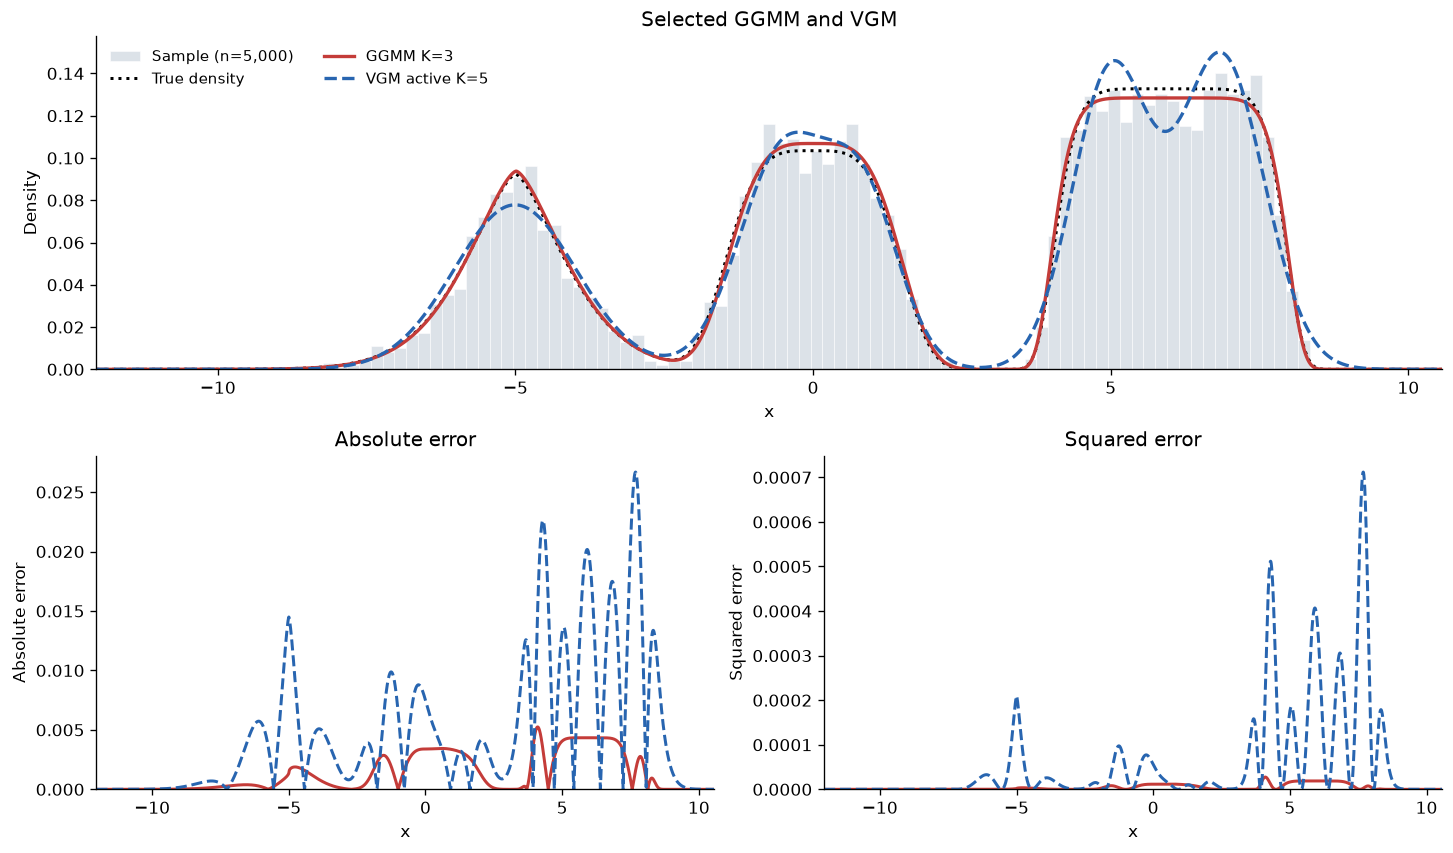

In [3]:
# 실험 1: 선택된 GGMM은 참 분포를 얼마나 잘 표현하는가?
# 이 셀은 선택 K·추정식·파라미터와 GGMM/VGM의 밀도·오차를 함께 보여주는 실험입니다.
# GGMM은 기존 적합값을 사용하고, VGM은 같은 X 전체에 원래 설정으로 한 번 적합합니다.
with threadpool_limits(limits=1):
    vgm_full, vgm_active, vgm_info = fit_vgm(x, max_components=10)

print("g(x; mu,a,b) = b / [2a Gamma(1/b)] * exp(-|(x-mu)/a|^b)")
print("참 분포:", truth.formula())
print(f"선택 K={selected.k}의 추정 GGMM:", selected.formula())
show_table(parameter_table(selected)[["component", "weight", "mu", "a", "b"]])
overview = pd.DataFrame([
    mixture_row("GGMM + BIC", selected, fit.diagnostics_["seconds"],
                fit.diagnostics_["selected_converged"]),
    mixture_row("VGM active", vgm_active, vgm_info["seconds"], vgm_info["converged"]),
])
show_table(overview)
print("LL은 클수록, IAE·ISE는 작을수록 좋습니다. 참 밀도는 적합 후 평가에만 사용합니다.")
print("VGM: 최대 10성분, weight>0.005인 성분만 재정규화. 실제 유효 K:", vgm_active.k)
print("Fit_s: GGMM은 기존 K 탐색 전체 시간, VGM은 이번 적합 시간입니다.")
grid = plot_grid([truth, selected, vgm_active])
show_density_errors(grid, [
    (f"GGMM K={selected.k}", selected.pdf(grid), "#c43c39", "-"),
    (f"VGM active K={vgm_active.k}", vgm_active.pdf(grid), "#2865b0", "--"),
], "Selected GGMM and VGM")


Initial_b는 K=3에서 적합을 시작할 때 사용한 형상 값입니다.


,K,Chosen_start,Quantile_LL,Quantile_status,Lloyd_LL,Lloyd_status
0,1,quantile,-13777.280490,converged,NaN,duplicate / omitted
1,2,lloyd,-12735.934721,converged,-12735.934720,converged
2,3,lloyd,-12666.145715,converged,-12177.312812,converged
3,4,quantile,-12175.128761,converged,-12175.128766,converged
4,5,quantile,-12172.481564,converged,-12174.540095,converged
5,6,quantile,-12171.948443,converged,-12173.137388,converged
6,7,lloyd,-12169.637321,converged,-12168.156474,converged
7,8,quantile,-12165.350955,not converged,-12167.511177,not converged
8,9,quantile,-12163.877190,not converged,-12166.051568,not converged
9,10,lloyd,-12176.808635,not converged,-12172.894512,not converged


,Start,Initial_b,Chosen
0,quantile,"[2.0, 2.0, 10.28284]",False
1,lloyd,"[1.64404, 4.22725, 13.33143]",True


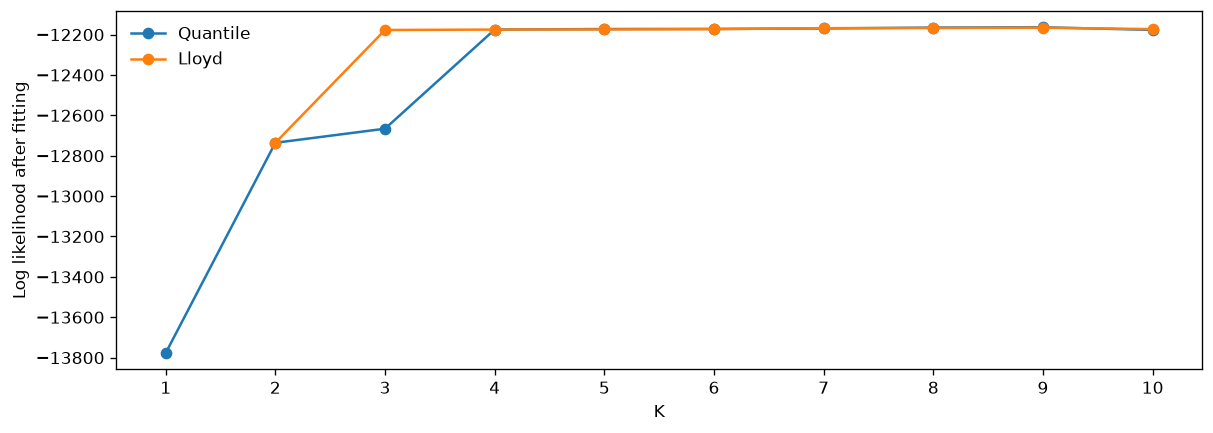

In [4]:
# 실험 2: Quantile과 Lloyd 중 어느 초기화가 채택되었는가?
# 이 셀은 각 K에서 두 시작점의 적합 후 로그우도·종료 상태·초기 b를 비교하는 실험입니다.
# 같은 K 안에서는 더 큰 우도의 시작점을 채택하고, K 사이에서는 BIC로 선택합니다.
initial_rows = []
for k, rec in sorted(records.items()):
    starts = {row["start"]: row for row in fit.starts_ if row["K"] == k}
    row: dict[str, Any] = {"K": k, "Chosen_start": rec.get("start", "none")}
    for method, label in [("quantile", "Quantile"), ("lloyd", "Lloyd")]:
        start = starts.get(method, {})
        row[label + "_LL"] = start.get("log_likelihood", np.nan)
        row[label + "_status"] = ("converged" if start.get("converged") else
                                   "not converged" if start else "duplicate / omitted")
    initial_rows.append(row)
initial_table = pd.DataFrame(initial_rows)
show_table(initial_table)
show_table(pd.DataFrame([
    {"Start": row["start"], "Initial_b": np.round(row.get("initial_shapes", []), 5).tolist(),
     "Chosen": row["start"] == records[selected.k].get("start")}
    for row in fit.starts_ if row["K"] == selected.k
]))
print(f"Initial_b는 K={selected.k}에서 적합을 시작할 때 사용한 형상 값입니다.")
fig, ax = plt.subplots(figsize=(10, 3.5), layout="constrained")
for method in ["Quantile", "Lloyd"]:
    ax.plot(initial_table["K"], initial_table[method + "_LL"], "o-", label=method)
ax.set(xlabel="K", ylabel="Log likelihood after fitting", xticks=initial_table["K"])
ax.legend(frameon=False)
plt.show()


현재 계산된 후보의 선택: {'LL 최대': 9, 'AIC 최소': 3, 'BIC 최소': 3}
LL_gain<0이면 이전 K보다 낮은 우도를 얻은 것입니다. 수치 최적화 상태를 함께 봐야 합니다.
max_b는 최대 형상 값, a_floor_hits는 척도 하한에 닿은 성분 수입니다.


,K,log_likelihood,LL_gain,AIC,BIC,converged,selected
0,1,-13777.280490,NaN,27560.560979,27580.112559,True,False
1,2,-12735.934720,1041.345770,25485.869439,25531.489792,True,False
2,3,-12177.312812,558.621908,24376.625623,24448.314748,True,True
3,4,-12175.128761,2.184051,24380.257522,24478.015420,True,False
4,5,-12172.481564,2.647197,24382.963127,24506.789798,True,False
5,6,-12171.948443,0.533121,24389.896886,24539.792329,True,False
6,7,-12168.156474,3.791969,24390.312947,24566.277164,True,False
7,8,-12165.350955,2.805519,24392.701910,24594.734899,False,False
8,9,-12163.877190,1.473765,24397.754379,24625.856141,False,False
9,10,-12172.894512,-9.017323,24423.789025,24677.959559,False,False


,K,max_b,a_floor_hits
0,1,13.876912,0
1,2,8.841810,0
2,3,8.842612,0
3,4,5.282206,0
4,5,4176693.654474,0
5,6,14.364729,0
6,7,6.020295,0
7,8,1579973.234613,0
8,9,4255.268615,0
9,10,332.199926,0


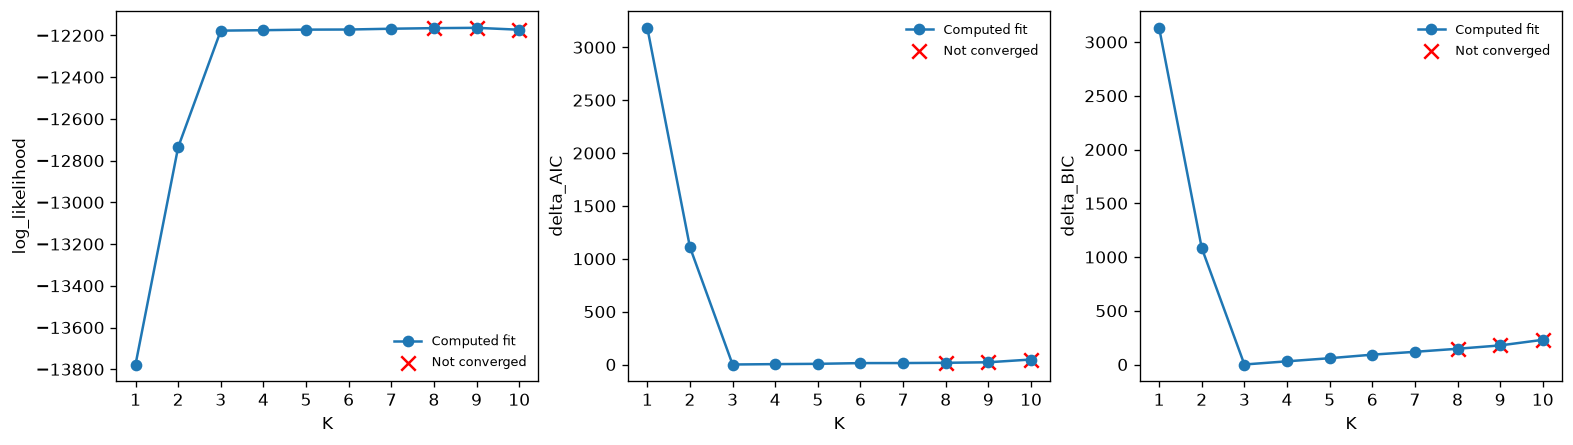

In [5]:
# 실험 3: 로그우도·AIC·BIC는 각각 어떤 K를 고르는가?
# 이 셀은 모든 K의 점수와 우도 증가량을 한 표·그림에서 비교하는 실험입니다.
# 미수렴 결과도 표시합니다. 점수 최소가 전역 최적해나 참 K를 보장하지는 않습니다.
scores = pd.DataFrame(fit.selection_).sort_values("K").copy()
scores["AIC"] = -2*scores["log_likelihood"] + 2*(4*scores["K"]-1)
scores["LL_gain"] = scores["log_likelihood"].diff()
scores["delta_AIC"] = scores["AIC"] - scores["AIC"].min()
scores["delta_BIC"] = scores["BIC"] - scores["BIC"].min()
show_table(scores[["K", "log_likelihood", "LL_gain", "AIC", "BIC", "converged", "selected"]])
show_table(scores[["K", "max_b", "a_floor_hits"]])
chosen_by = {"LL 최대": int(scores.iloc[int(np.argmax(scores["log_likelihood"].to_numpy()))]["K"]),
             "AIC 최소": int(scores.iloc[int(np.argmin(scores["AIC"].to_numpy()))]["K"]),
             "BIC 최소": int(fit.n_components_)}
print("현재 계산된 후보의 선택:", chosen_by)
print("LL_gain<0이면 이전 K보다 낮은 우도를 얻은 것입니다. 수치 최적화 상태를 함께 봐야 합니다.")
print("max_b는 최대 형상 값, a_floor_hits는 척도 하한에 닿은 성분 수입니다.")
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), layout="constrained")
for ax, metric in zip(axes, ["log_likelihood", "delta_AIC", "delta_BIC"]):
    ax.plot(scores["K"], scores[metric], "o-", label="Computed fit")
    bad = scores.loc[~scores["converged"]]
    ax.scatter(bad["K"], bad[metric], marker="x", s=75, color="red", label="Not converged")
    ax.set(xlabel="K", ylabel=metric, xticks=scores["K"])
    ax.legend(fontsize=8, frameon=False)
plt.show()


추출 시드: 20260914 | 인덱스: [4522, 3243, 1038]
추출 관측값: [5.818552, 6.024767, -0.722823]
IAE·ISE: [-24.0350, 23.7501]의 4,000점 사다리꼴 근사.
우도는 세 모형 모두 전체 X에서 평가했습니다. 3개 KDE의 우도는 그 3개만의 훈련 우도가 아닙니다.
Fit_s와 LL_s는 각각 적합·우도 평가 시간입니다. GGMM 시간은 기존 전체 K 탐색 시간입니다.


,Method,Fit_n,Terms,LL_on_all_X,IAE,ISE
0,GGMM K=3,5000,3,-12177.312812,0.029223,0.000092
1,"Gaussian KDE n=5,000",5000,5000,-12660.866914,0.264091,0.005210
2,Gaussian KDE n=3,3,3,-14662.564453,0.759495,0.036073


,Method,Factor,h,Fit_s,LL_s
0,GGMM K=3,NaN,NaN,115.669012,NaN
1,"Gaussian KDE n=5,000",0.182056,0.815305,0.000271,0.656217
2,Gaussian KDE n=3,0.802742,3.080584,0.000203,0.000532


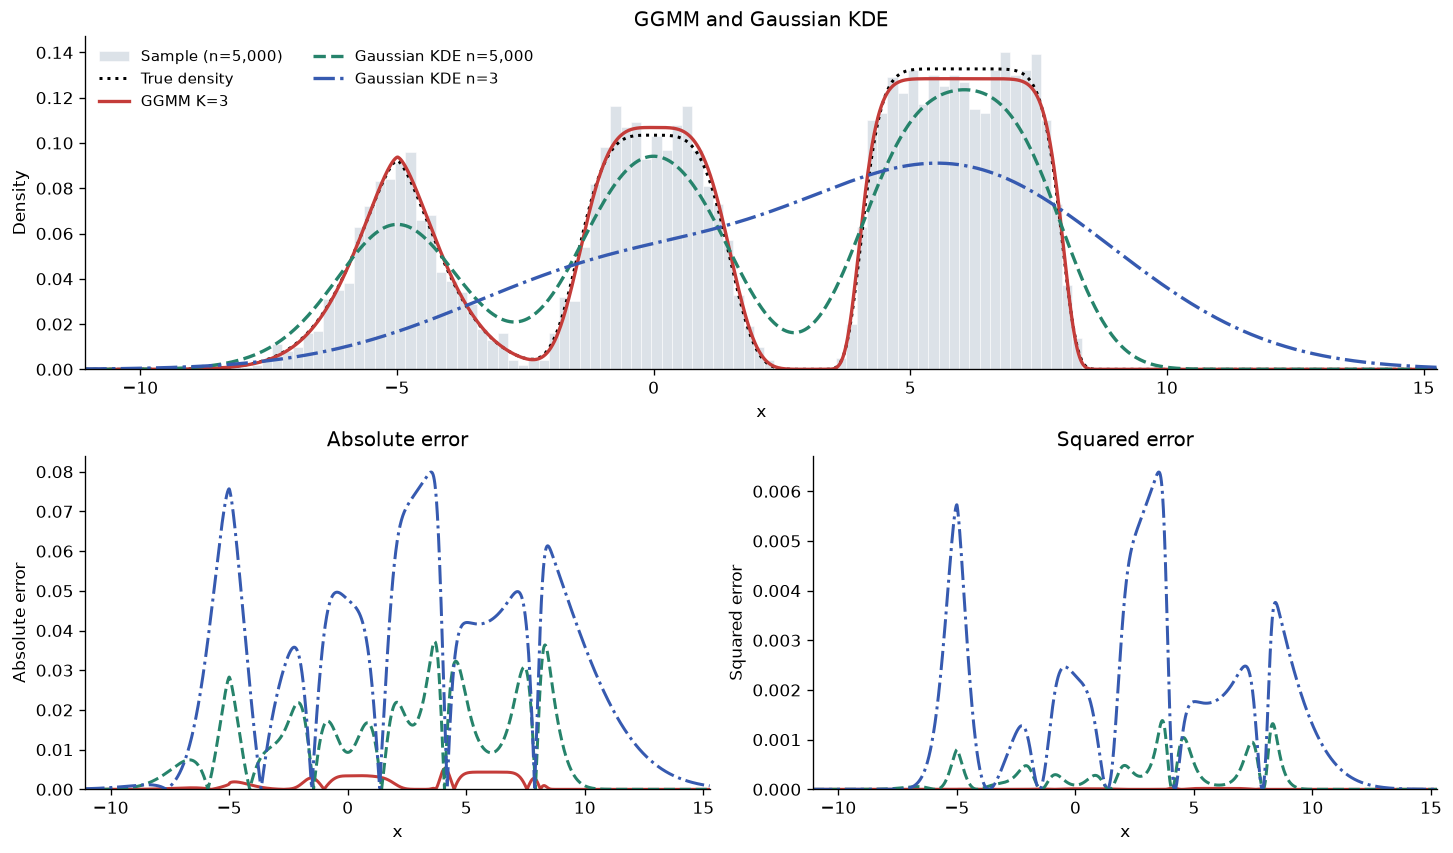

In [6]:
# 실험 4: GGMM, 전체 표본 KDE, 3개 관측값 KDE 비교
# 이 셀은 Gaussian 커널 5,000개와 3개를 썼을 때 밀도·오차·우도·시간이 어떻게 다른지 봅니다.
# 3-kernel KDE는 3개 값만 이용합니다. 전체 X로 세 성분을 최적화한 모형과 구분해야 합니다.
with threadpool_limits(limits=1):
    start = perf_counter()
    kde_full = gaussian_kde(x, bw_method="scott")
    kde_full_seconds = perf_counter()-start
    start = perf_counter()
    kde_full_ll = float(kde_full.logpdf(x).sum())
    kde_full_score_seconds = perf_counter()-start
    indices3 = np.random.default_rng(20260914).choice(len(x), size=3, replace=False)
    start = perf_counter()
    kde_three = gaussian_kde(x[indices3], bw_method="scott")
    kde_three_seconds = perf_counter()-start
    start = perf_counter()
    kde_three_ll = float(kde_three.logpdf(x).sum())
    kde_three_score_seconds = perf_counter()-start
    h_full = float(np.sqrt(kde_full.covariance[0, 0]))
    h_three = float(np.sqrt(kde_three.covariance[0, 0]))
    # 이전 3-kernel 비교와 같은 4,000개 격자점과 적분 범위입니다.
    margin = 5*max(h_full, h_three)
    kde_grid = np.linspace(x.min()-margin, x.max()+margin, 4000)
    kde_curves = [
        (f"GGMM K={selected.k}", selected.pdf(kde_grid), "#c43c39", "-"),
        (f"Gaussian KDE n={len(x):,}", kde_full(kde_grid), "#26836b", "--"),
        ("Gaussian KDE n=3", kde_three(kde_grid), "#365ab0", "-.")]
kde_specs = [
    (len(x), selected.k, np.nan, np.nan, fit.diagnostics_["seconds"], np.nan,
     float(selected.logpdf(x).sum())),
    (len(x), kde_full.n, float(cast(float, kde_full.factor)), h_full, kde_full_seconds, kde_full_score_seconds, kde_full_ll),
    (3, 3, float(cast(float, kde_three.factor)), h_three, kde_three_seconds, kde_three_score_seconds, kde_three_ll)]
kde_rows = []
for (name, pdf, _, _), (n, terms, factor, h, fit_s, score_s, ll) in zip(kde_curves, kde_specs):
    delta = pdf-truth.pdf(kde_grid)
    kde_rows.append(dict(Method=name, Fit_n=n, Terms=terms, Factor=factor, h=h,
        LL_on_all_X=ll, IAE=float(cast(float, trapezoid(np.abs(delta), kde_grid))),
        ISE=float(cast(float, trapezoid(delta**2, kde_grid))), Fit_s=fit_s, LL_s=score_s))
kde_table = pd.DataFrame(kde_rows)
show_table(kde_table[["Method", "Fit_n", "Terms", "LL_on_all_X", "IAE", "ISE"]])
show_table(kde_table[["Method", "Factor", "h", "Fit_s", "LL_s"]])
print("추출 시드: 20260914 | 인덱스:", indices3.tolist())
print("추출 관측값:", np.round(x[indices3], 6).tolist())
print(f"IAE·ISE: [{kde_grid[0]:.4f}, {kde_grid[-1]:.4f}]의 4,000점 사다리꼴 근사.")
print("우도는 세 모형 모두 전체 X에서 평가했습니다. 3개 KDE의 우도는 그 3개만의 훈련 우도가 아닙니다.")
print("Fit_s와 LL_s는 각각 적합·우도 평가 시간입니다. GGMM 시간은 기존 전체 K 탐색 시간입니다.")
# 그림은 중심 구간을 확대하고, 위 적분에는 넓은 구간 전체를 사용합니다.
visible = (kde_grid >= min(x.min()-3*h_full, x[indices3].min()-3*h_three)) & (
           kde_grid <= max(x.max()+3*h_full, x[indices3].max()+3*h_three))
show_density_errors(kde_grid[visible], [(name, pdf[visible], color, style)
                    for name, pdf, color, style in kde_curves], "GGMM and Gaussian KDE")


VGM은 weight>0.005인 성분을 재정규화했습니다. Parameters는 표시된 밀도의 자유 파라미터 수입니다.
GGMM 시간은 해당 K의 기존 적합 시간, VGM 시간은 이번 적합 시간입니다.


,Method,K,LL,IAE,ISE,Fit_s,Converged,Integral_OK,Parameters
0,GGMM,3,-12177.312812,0.029223,0.000092,0.603199,True,True,11
1,VGM active,3,-12460.511535,0.213372,0.005165,0.009039,True,True,8
2,GGMM,5,-12172.481564,0.041329,0.000247,6.287417,True,True,19
3,VGM active,5,-12270.380570,0.108209,0.001250,0.673889,True,True,14


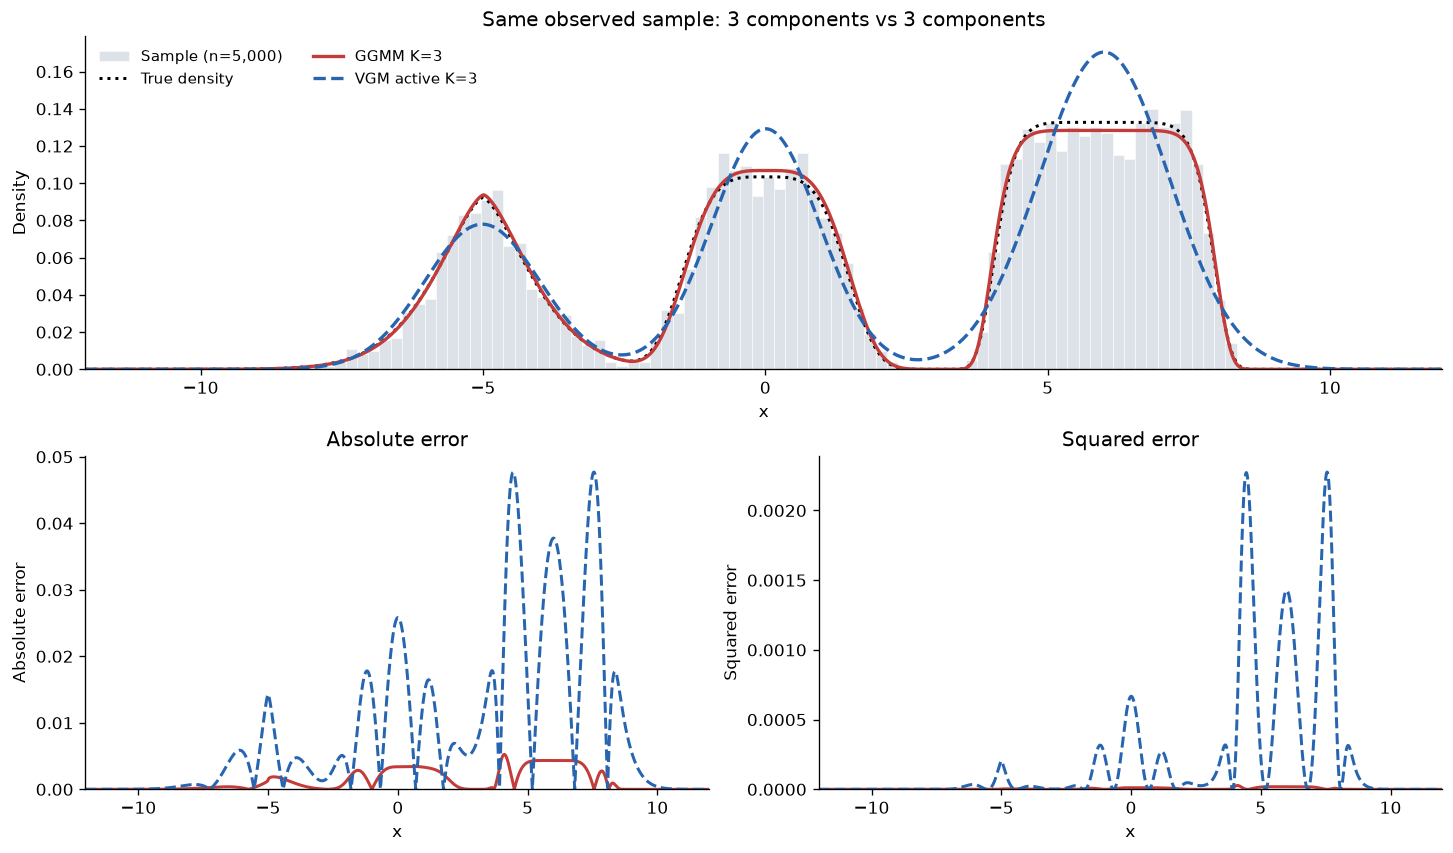

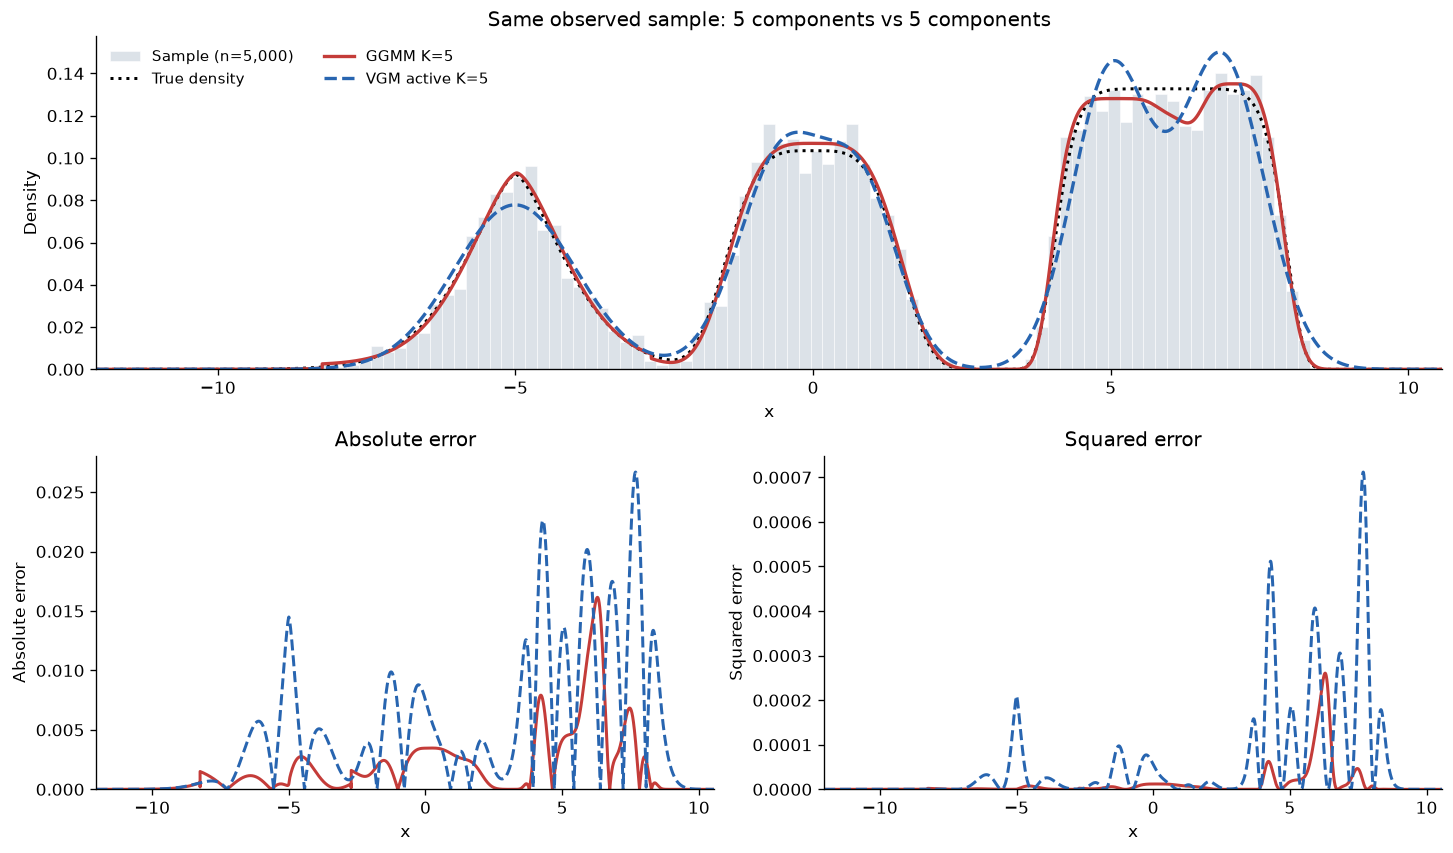

In [7]:
# 실험 5: 실제 성분 수가 같아도 GGMM과 VGM의 차이가 남는가?
# 이 셀은 같은 X에서 3 대 3, 5 대 5의 표와 밀도·오차 그림을 함께 보여주는 실험입니다.
# VGM 상한은 기존 실험의 3/10입니다. 유효 성분 수가 실제로 3/5인지 확인합니다.
same_models = {}
same_rows = []
with threadpool_limits(limits=1):
    for k, cap in [(3, 3), (5, 10)]:
        if k not in fit.models_:
            raise ValueError(f"기존 적합 결과에 GGMM K={k}가 없습니다.")
        if cap == 10:
            active, info = vgm_active, vgm_info
        else:
            _, active, info = fit_vgm(x, max_components=cap)
        if active.k != k:
            raise ValueError(f"VGM 상한 {cap}의 실제 유효 K는 {active.k}입니다. {k} 대 {k}로 표시할 수 없습니다.")
        same_models[k] = (fit.models_[k], active)
        for name, model, sec, converged in [
            ("GGMM", fit.models_[k], records[k]["seconds"], records[k]["converged"]),
            ("VGM active", active, info["seconds"], info["converged"])]:
            row = mixture_row(name, model, sec, converged)
            row["Parameters"] = (4*k-1) if name == "GGMM" else (3*k-1)
            same_rows.append(row)
show_table(pd.DataFrame(same_rows))
print("VGM은 weight>0.005인 성분을 재정규화했습니다. Parameters는 표시된 밀도의 자유 파라미터 수입니다.")
print("GGMM 시간은 해당 K의 기존 적합 시간, VGM 시간은 이번 적합 시간입니다.")
for k, (gg, vg) in same_models.items():
    grid = plot_grid([truth, gg, vg])
    show_density_errors(grid, [
        (f"GGMM K={k}", gg.pdf(grid), "#c43c39", "-"),
        (f"VGM active K={k}", vg.pdf(grid), "#2865b0", "--"),
    ], f"Same observed sample: {k} components vs {k} components")


Integral_OK는 적응형 적분의 허용오차 통과 여부입니다. 실험 4의 격자 근사와 끝자리가 다를 수 있습니다.
IAE·ISE는 넓은 유한 구간에서 수치 적분한 값이며, 전 실수 구간의 정확한 적분값은 아닙니다.


,Method,LL,IAE,ISE,Converged,Integral_OK
0,GGMM K=1,-13777.280490,0.636626,0.033414,True,True
1,GGMM K=2,-12735.934720,0.276481,0.009898,True,True
2,GGMM K=3,-12177.312812,0.029223,0.000092,True,True
3,GGMM K=4,-12175.128761,0.039206,0.000246,True,True
4,GGMM K=5,-12172.481564,0.041329,0.000247,True,True
5,GGMM K=6,-12171.948443,0.042227,0.000303,True,True
6,GGMM K=7,-12168.156474,0.050849,0.000438,True,True
7,GGMM K=8,-12165.350955,0.052107,0.000503,False,True
8,GGMM K=9,-12163.877190,0.060950,0.000612,False,True
9,GGMM K=10,-12172.894512,0.074887,0.001242,False,True


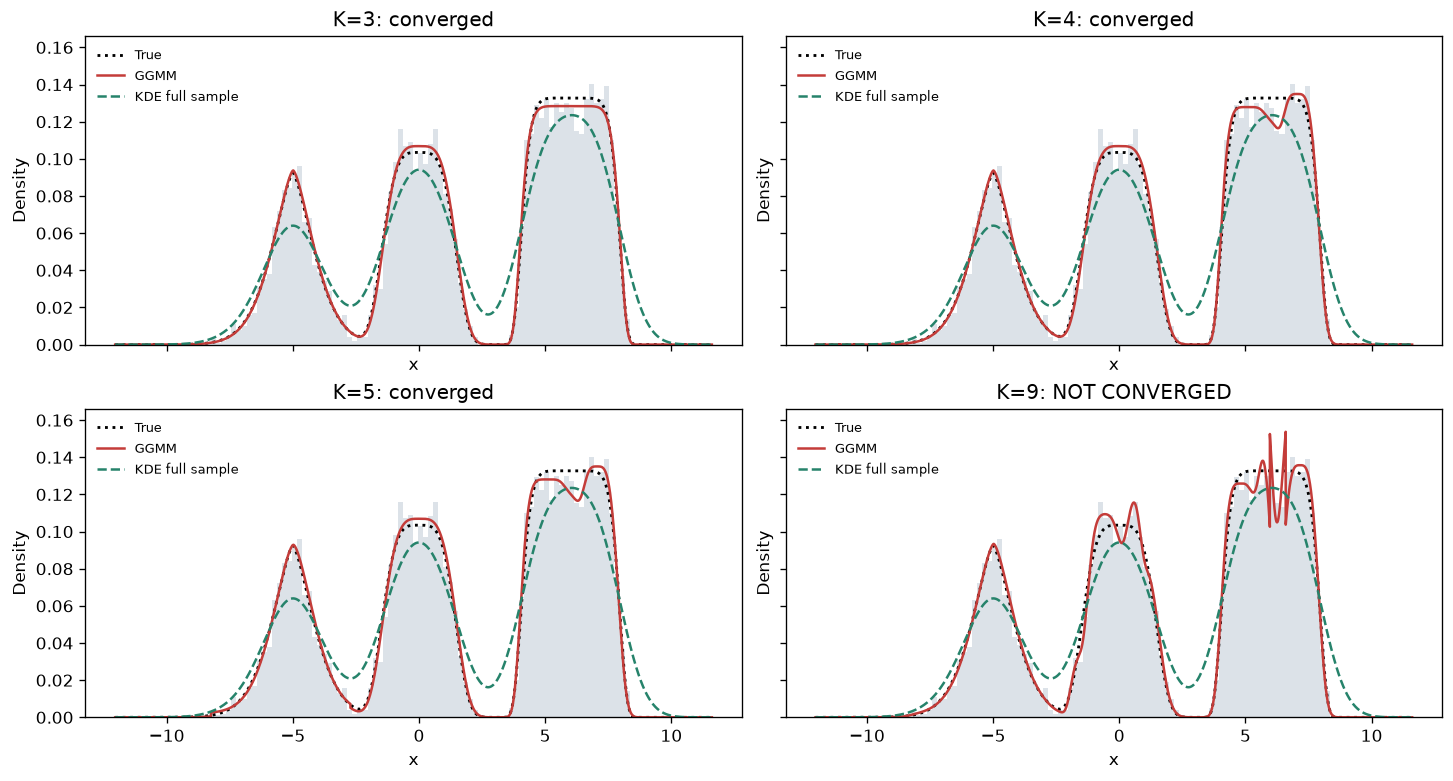

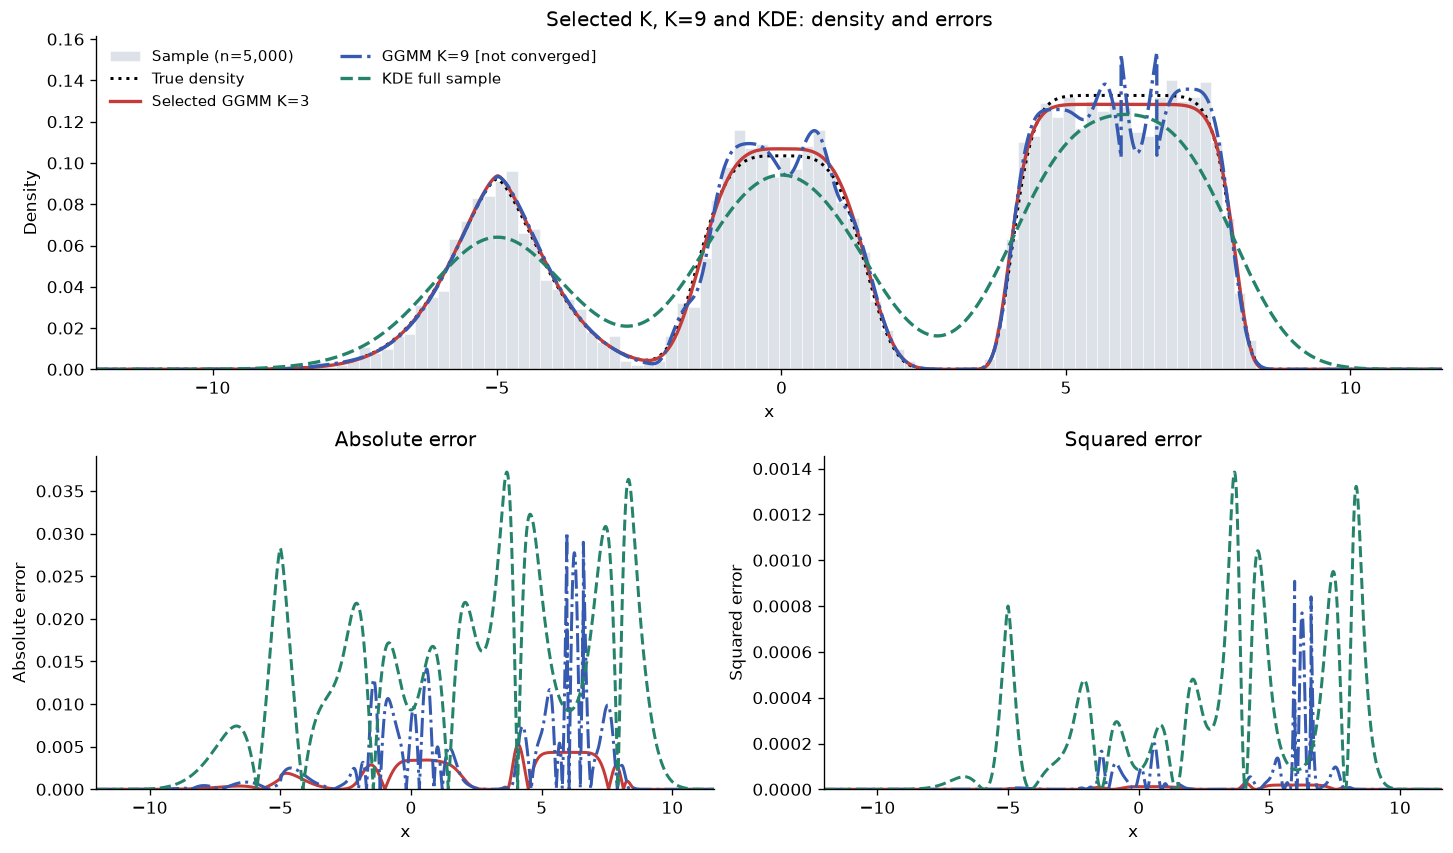

In [8]:
# 실험 6: K=9와 선택된 K의 참 밀도 오차는 어떻게 다른가?
# 이 셀은 모든 GGMM 후보와 전체 표본 KDE의 참 밀도 오차를 비교하는 실험입니다.
# 큰 b의 경계를 놓치지 않도록 여기서는 기존 적응형 적분을 사용합니다.
# 참 밀도로 K를 다시 고르지 않고, 기존 적합을 사후 평가합니다.
all_errors = pd.DataFrame([
    mixture_row(f"GGMM K={k}", model, records[k]["seconds"], records[k]["converged"])
    for k, model in sorted(fit.models_.items())
])
kde_adaptive = adaptive_kde_error(kde_full)
all_errors = pd.concat([all_errors, pd.DataFrame([dict(
    Method="KDE full sample", K=np.nan, LL=kde_full_ll, Fit_s=kde_full_seconds,
    Converged="Scott rule", **kde_adaptive)])], ignore_index=True)
show_table(all_errors[["Method", "LL", "IAE", "ISE", "Converged", "Integral_OK"]])
print("Integral_OK는 적응형 적분의 허용오차 통과 여부입니다. 실험 4의 격자 근사와 끝자리가 다를 수 있습니다.")
print("IAE·ISE는 넓은 유한 구간에서 수치 적분한 값이며, 전 실수 구간의 정확한 적분값은 아닙니다.")
ks = [k for k in (3, 4, 5, 9) if k in fit.models_]
grid = plot_grid([truth, *[fit.models_[k] for k in ks]], padding=4*h_full)
with threadpool_limits(limits=1):
    kde_pdf = kde_full(grid)
fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharex=True, sharey=True, layout="constrained")
for ax, k in zip(axes.flat, ks):
    ax.hist(x, bins=85, density=True, color="#dce2e8")
    ax.plot(grid, truth.pdf(grid), "k:", lw=1.7, label="True")
    ax.plot(grid, fit.models_[k].pdf(grid), color="#c43c39", label="GGMM")
    ax.plot(grid, kde_pdf, color="#26836b", ls="--", label="KDE full sample")
    status = "converged" if records[k]["converged"] else "NOT CONVERGED"
    ax.set(title=f"K={k}: {status}", xlabel="x", ylabel="Density")
    ax.legend(fontsize=8, frameon=False)
for ax in list(axes.flat)[len(ks):]:
    ax.set_visible(False)
# 모든 패널에 동일한 축을 쓰면서 K=9의 높은 봉우리도 잘리지 않도록 합니다.
peak = max(np.histogram(x, bins=85, density=True)[0].max(), truth.pdf(grid).max(),
           kde_pdf.max(), max(fit.models_[k].pdf(grid).max() for k in ks))
axes.flat[0].set_ylim(0, 1.08*peak)
plt.show()
curves = [(f"Selected GGMM K={selected.k}", selected.pdf(grid), "#c43c39", "-")]
if 9 in fit.models_ and selected.k != 9:
    label = "GGMM K=9" + (" [not converged]" if not records[9]["converged"] else "")
    curves.append((label, fit.models_[9].pdf(grid), "#365ab0", "-."))
curves.append(("KDE full sample", kde_pdf, "#26836b", "--"))
show_density_errors(grid, curves, "Selected K, K=9 and KDE: density and errors")


,scale_floor_relative,selected_K,IAE,ISE,selected_converged
0,0.000100,3,0.029223,0.000092,True
1,0.001000,3,0.029223,0.000092,True
2,0.010000,3,0.029223,0.000092,True


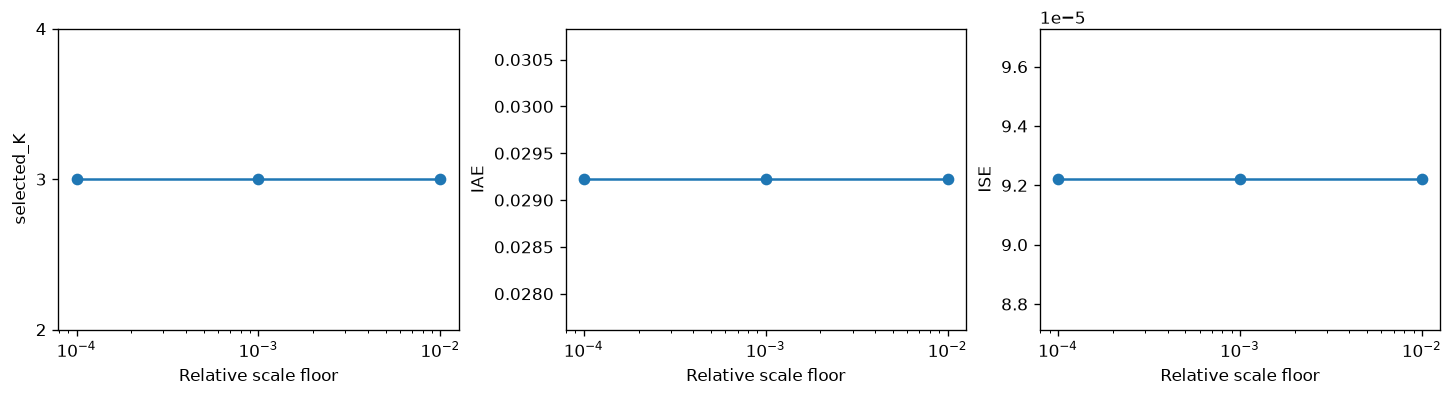

In [9]:
# 실험 7: 척도 하한을 바꾸었을 때 기존 결과가 달라졌는가?
# 이 셀은 이미 계산된 하한 민감도 결과만 확인하는 실험입니다. 추가 적합을 하지 않습니다.
# 양의 하한 세 개의 비교이며, 하한을 완전히 제거한 실험은 아닙니다.
sensitivity = result["sensitivity"]
if sensitivity.empty:
    print("기존 결과에 척도 하한 비교가 없습니다.")
else:
    show_table(sensitivity[["scale_floor_relative", "selected_K", "IAE", "ISE", "selected_converged"]])
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), layout="constrained")
    for ax, metric in zip(axes, ["selected_K", "IAE", "ISE"]):
        ax.semilogx(sensitivity["scale_floor_relative"], sensitivity[metric], "o-")
        ax.set(xlabel="Relative scale floor", ylabel=metric)
    min_k, max_k = int(sensitivity["selected_K"].min()), int(sensitivity["selected_K"].max())
    axes[0].set(ylim=(min_k-1, max_k+1), yticks=np.arange(min_k-1, max_k+2))
    plt.show()
